# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown. 

In this case, we are facing a Discontinuous function

In [12]:
pip install POT


   ---------------------------------------- 0.0/294.3 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.3 kB 660.6 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/294.3 kB 495.5 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/294.3 kB 655.4 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/294.3 kB 731.4 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/294.3 kB 602.4 kB/s eta 0:00:01
   ------------------ ------------------- 143.4/294.3 kB 502.3 kB/s eta 0:00:01
   ---------------------- --------------- 174.1/294.3 kB 583.1 kB/s eta 0:00:01
   ------------------------- ------------ 194.6/294.3 kB 513.4 kB/s eta 0:00:01
   ------------------------- ------------ 194.6/294.3 kB 513.4 kB/s eta 0:00:01
   -------------------------- ----------- 204.8/294.3 kB 445.2 kB/s eta 0:00:01
   ----------------------------------- -- 276.5/294.3 kB 550.1 kB/s eta 0:00:01
   -------------------------------------- 294.3/

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


Ray module not found. Multiprocessing features are not available


True

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

# Creation of the model

In [3]:
#Benchmark1
lowfid = lambda x,delta: (0.5*(6.*x/5.-2.)**2*np.sin(12.*x/5.-4)+10.*(x/5-0.5)-5.)*(x<2.5) + (3+0.5*(6.*x/5.-2)**2*np.sin(12.*x/5.-4)+10*(x/5.-0.5)-5.+delta)*(x>2.5)
highfid = lambda x,delta: (2*lowfid(x,delta)- 20*x/5.+20)*(x/5.<0.5) + (4+2*lowfid(x,delta)- 20*x/5.+20+delta)*(x/5.>0.5)

In [4]:
#Benchmark1

Nhf = 16
Nlf = 40
N = Nhf + Nlf

xhf = np.linspace(0,5,Nhf)
deltahf=np.linspace(0.,15.,5)
datahf= np.array(np.meshgrid(xhf,deltahf)).T.reshape(-1, 2)
ord_index = np.lexsort((datahf[:, 0], datahf[:, 1]))
datahf = datahf[ord_index]

xlf = np.linspace(0,5,Nlf)
deltalf=np.linspace(0.,15.,5)
datalf= np.array(np.meshgrid(xlf,deltalf)).T.reshape(-1, 2)
ord_index = np.lexsort((datalf[:, 0], datalf[:, 1]))
datalf = datalf[ord_index]

x_test = np.linspace(0,5,1000)
delta_test=np.linspace(0.,15.,5)
datatest= np.array(np.meshgrid(x_test,delta_test)).T.reshape(-1, 2)
ord_index = np.lexsort((datatest[:, 0], datatest[:, 1]))
datatest = datatest[ord_index]

Yhf = highfid(datahf[:,0],datahf[:,1])
Ylf = lowfid(datalf[:,0],datalf[:,1])

NepoLF = 2000
NepoHF = 5200

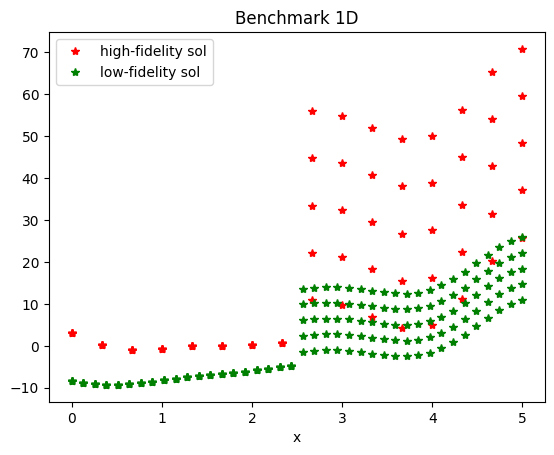

In [5]:
#%% Plot functions
plt.figure()
plt.plot(datahf[:,0],highfid(datahf[:,0],datahf[:,1]),'r*', label = 'high-fidelity sol')
plt.plot(datalf[:,0],lowfid(datalf[:,0],datalf[:,1]),'g*', label = 'low-fidelity sol')
#plt.plot(xhf,highfid(d,xhf),'ro', label = 'high-fidelity data', markersize = 4)
#plt.plot(xlf,lowfid(d,xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model




The function training took 12.136786222457886 seconds.


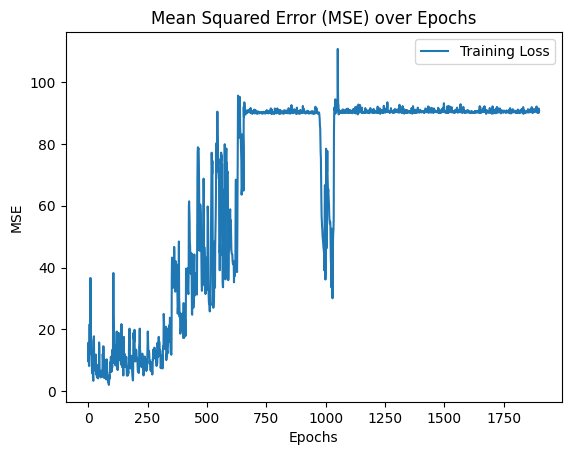

(5000, 2)
(5000,)
(5000, 1)
Test MSE: 697.8794704146352
R^2: -8235.515025871882


In [6]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=datalf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(datatest)
(mse_LF,R_LF)=modelLF.performance(datatest,highfid(datatest[:,0],datatest[:,1]))

## High fidelity model

The function training took 29.596251249313354 seconds.


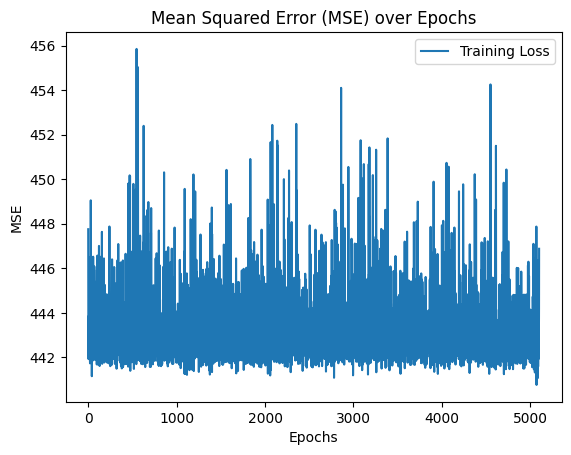

(5000, 2)
(5000,)
(5000, 1)
Test MSE: 423.6516458583564
R^2: -4999.022632524955


In [7]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=datahf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(datatest)
(mse_HF,R_HF)=modelHF.performance(datatest,highfid(datatest[:,0],datatest[:,1]))

## 2 Step model

The function training took 13.834927558898926 seconds.


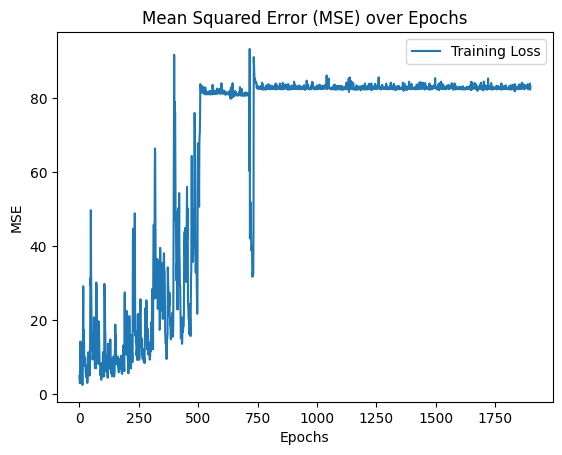

The function training took 22.32789444923401 seconds.


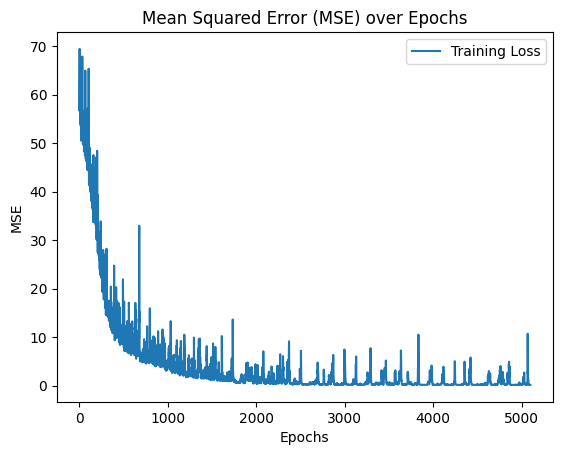

(5000, 3)
(5000,)
(5000, 1)
Test MSE: 841.1712345194046
R^2: -9926.673482548375


In [8]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[datalf,datahf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(datatest)

input_HF = np.concatenate(
                    (datatest,  final_model.model_list[0].prediction(datatest).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(datatest[:,0],datatest[:,1]))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

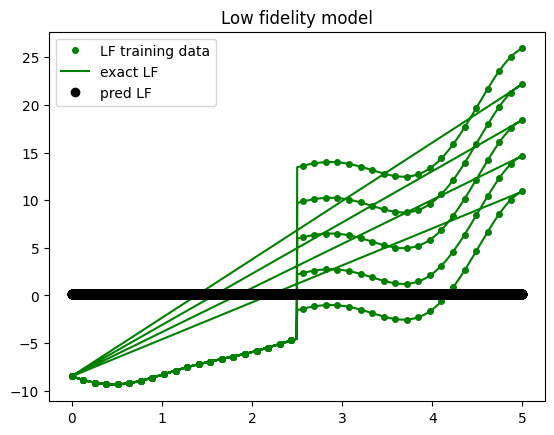

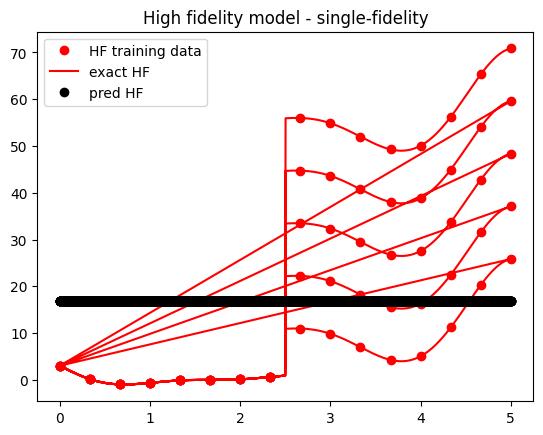

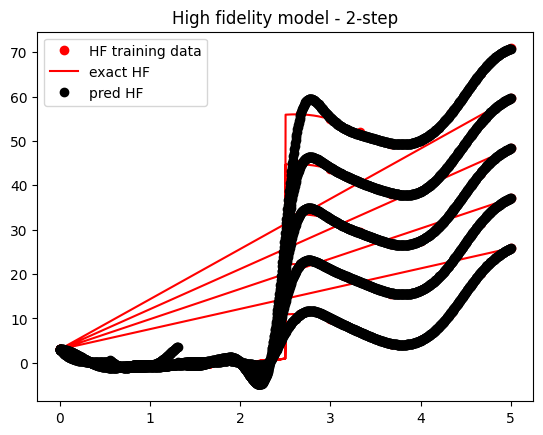

In [9]:
#LF
plt.figure()
plt.plot(datalf[:,0],Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(datatest[:,0],lowfid(datatest[:,0],datatest[:,1]),'g-', label = 'exact LF') 
plt.plot(datatest[:,0],yLF,'ko', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(datahf[:,0],Yhf,'ro', label = 'HF training data')
plt.plot(datatest[:,0],highfid(datatest[:,0],datatest[:,1]),'r-', label = 'exact HF')
plt.plot(datatest[:,0],yHF,'ko', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(datahf[:,0],Yhf,'ro', label = 'HF training data')
plt.plot(datatest[:,0],highfid(datatest[:,0],datatest[:,1]),'r-', label = 'exact HF')
plt.plot(datatest[:,0],y_test,'ko', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

In [10]:
print(deltahf)

[ 0.    3.75  7.5  11.25 15.  ]


# Inverse problem

noise 0.1
nb.data 30
rwmh.scaling 0.5
(30,)
real values are [15.]
Sampling chain 1/2
4.732682811326431
[[4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]
 [4.73268281]]
before
[ 3.03106833  0.66670072  6.36917305  4.09878969  0.92464256 -2.63024664
 -4.80997705 -5.82841206 -5.05459404 -2.94974184 -1.24095857  0.28232419
  0.24935472 -0.10949469 10.88198853 25.40617561 28.47975159 25.774086
 23.1814785  21.60373306 20.57857704 19.75026703 19.06857109 18.88662338
 19.93575287 22.77776718 27.06848907 31.59293747 35.20833206 37.57852173]
(30,)
after
[ 3.03106833  0.66670072  6.36917305  4.09878969  0.92464256 -2.63024664
 -4.80997705 -5.8284

Running chain, α = 1.00:   0%|          | 0/20 [00:00<?, ?it/s]

[[4.4580283]]
[[4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]
 [4.4580283]]


Running chain, α = 0.50:  10%|█         | 2/20 [00:00<00:01, 10.74it/s]

before
[ 2.9990201   0.66365659  0.16167581  4.19489479  0.70603466 -2.48774815
 -4.21089172 -4.96279001 -4.012815   -2.11129761 -0.73413575  0.64462686
  0.36884606 -0.26365244  9.97862911 23.67691803 26.69153214 24.29824066
 22.02017212 20.63341713 19.64354324 18.70443726 17.89296532 17.78019714
 19.13210869 22.31080627 26.8282795  31.46339989 35.11502457 37.47941208]
(30,)
after
[ 2.9990201   0.66365659  0.16167581  4.19489479  0.70603466 -2.48774815
 -4.21089172 -4.96279001 -4.012815   -2.11129761 -0.73413575  0.64462686
  0.36884606 -0.26365244  9.97862911 23.67691803 26.69153214 24.29824066
 22.02017212 20.63341713 19.64354324 18.70443726 17.89296532 17.78019714
 19.13210869 22.31080627 26.8282795  31.46339989 35.11502457 37.47941208]
(30,)
[[5.13620877]]
[[5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.13620877]
 [5.

...

[[6.13005668]]
[[6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]
 [6.13005668]]


Running chain, α = 0.30: 100%|██████████| 20/20 [00:01<00:00, 10.05it/s]

before
[ 4.85452414  3.86338139  0.76659381 -0.49720609 -0.78150451 -1.30552971
 -1.81967008 -2.35063219 -2.93019962 -3.19406509 -2.75914097 -2.30592489
 -2.59729052 -2.67389202 10.65067768 29.15521812 34.17699432 31.94159508
 28.59871292 26.02692795 24.72262955 24.35885239 24.58843422 25.3955574
 27.02102661 29.66115189 32.97129059 36.07030869 38.34754944 39.85103226]
(30,)
after
[ 4.85452414  3.86338139  0.76659381 -0.49720609 -0.78150451 -1.30552971
 -1.81967008 -2.35063219 -2.93019962 -3.19406509 -2.75914097 -2.30592489
 -2.59729052 -2.67389202 10.65067768 29.15521812 34.17699432 31.94159508
 28.59871292 26.02692795 24.72262955 24.35885239 24.58843422 25.3955574
 27.02102661 29.66115189 32.97129059 36.07030869 38.34754944 39.85103226]
(30,)
[[5.89465305]]
[[5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89465305]
 [5.89


C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [6.972]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  6.972  1.401   5.456    8.589      0.612     0.46       5.0      10.0   

    r_hat  
x0   2.63  
Autocorrelation...
[[6.972]]
[[6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]
 [6.972]]
before
[ 3.69411945e+00  2.18954849e+00 -4.53397036e-02 -1.10016572e+00
 -8.88036609e-01 -7.75164485e-01 -8.99276614e-01 -7.94428945e-01
 -1.05213201e+00 -8.27577949e-01 -2.24081635e-01 -7.91773915e-01
 -2.90871048e+00 -4.15314388e+00  9.24795914e+00  2.90756111e+01
  3.47412453e+01  3.32813454e+01  3.09004250e+01  2.87348137e+01
  2.68353710e+01  2.56526127e+01  2.55771046e+01  2.66027985e+01
  2.88047714e+01  3.22815552e+01  3.66563683e+01  4.08742180e+01
  4.38717155e+01  4.53878975e+

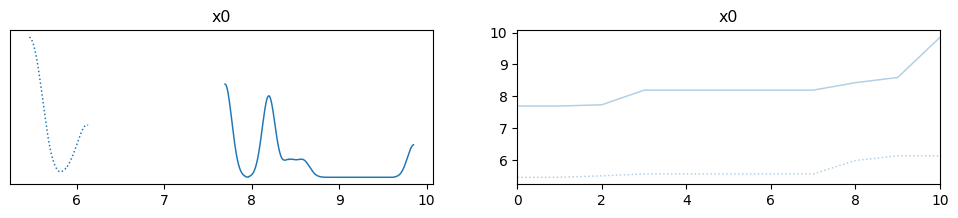

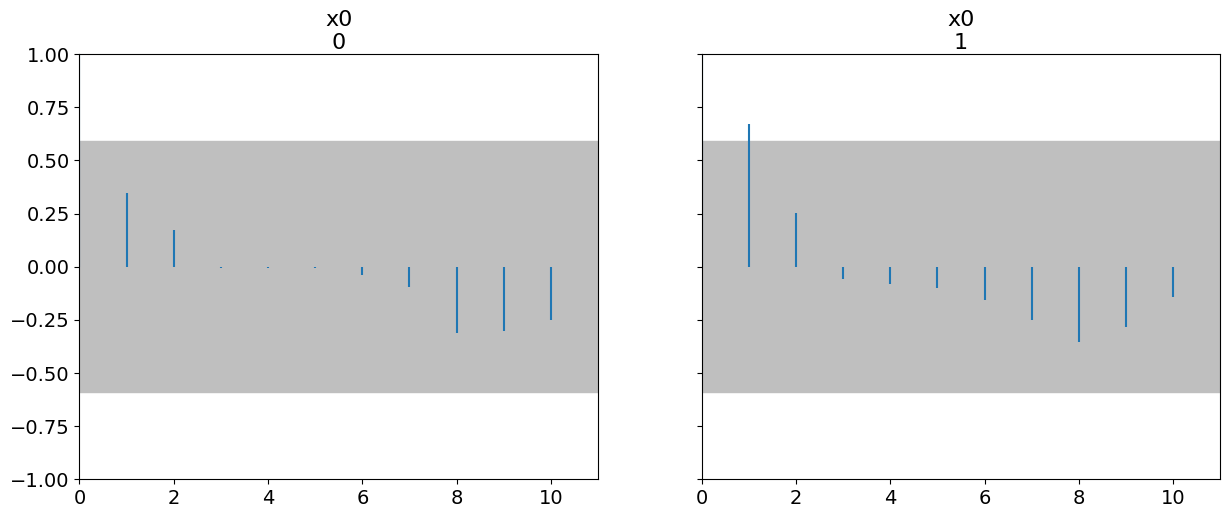

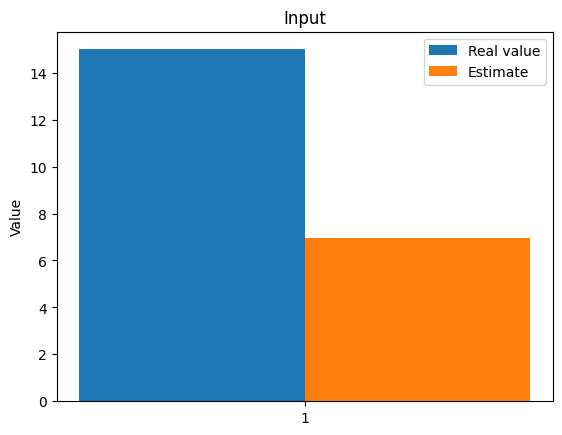

The function param_inverse took 4.709388732910156 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.5
(30,)
real values are [15.]
Sampling chain 1/2
5.377753085965342
[[5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]
 [5.37775309]]
before
[ 3.36623335  0.71765554  3.95987129  1.82657385 -0.07635009 -2.06648779
 -3.67970181 -4.95603275 -5.53778458 -4.2801609  -2.55969    -1.0689708
 -0.80053532 -0.82580173 11.47276115 28.04959869 31.92928505 28.97025108
 25.84669304 24.05997849 23.11934471 22.511446   22.10683823 22.1126442
 22.96519661 25.10923958 28.54523468 32.44616699 35.74420166 38.01198196]
(30,)
after
[ 3.36623335  0.71765554  3.959871

Running chain, α = 1.00:   0%|          | 0/20 [00:00<?, ?it/s]

[[5.53919388]]
[[5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]
 [5.53919388]]
before
[ 3.55544424  6.30308437  3.12424183  1.16350615 -0.33089912 -1.86610162
 -3.22376919 -4.32575893 -5.16664457 -4.33994293 -2.79456949 -1.44031703
 -1.18687427 -1.15483272 11.40332699 28.42962837 32.58261108 29.69062233
 26.41106606 24.5025444  23.59011841 23.1098423  22.86090088 22.99669647
 23.92132568 26.01963806 29.2532196  32.90618134 36.0308075  38.2157402 ]
(30,)
after
[ 3.55544424  6.30308437  3.12424183  1.16350615 -0.33089912 -1.86610162
 -3.22376919 -4.32575893 -5.16664457 -4.33994293 -2.79456949 -1.44031703
 -1.18687427 -1.15483272 11.40332

Running chain, α = 1.00:  10%|█         | 2/20 [00:00<00:01, 10.27it/s]

[[5.57223648]]
[[5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]
 [5.57223648]]
before
[ 3.60177183  6.18893623  2.95589733  1.03630316 -0.37561595 -1.82672632
 -3.13274288 -4.19412088 -5.06823063 -4.33360958 -2.83273458 -1.51257503
 -1.2695812  -1.22838962 11.38127804 28.49637794 32.70464325 29.83514214
 26.5268116  24.58659172 23.67329597 23.21704292 23.00355148 23.17324829
 24.12082672 26.21979332 29.41920662 33.01950836 36.10254288 38.26566315]
(30,)
after
[ 3.60177183  6.18893623  2.95589733  1.03630316 -0.37561595 -1.82672632
 -3.13274288 -4.19412088 -5.06823063 -4.33360958 -2.83273458 -1.51257503
 -1.2695812  -1.22838962 11.38127

...

[[5.34506662]]
[[5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]
 [5.34506662]]
before
[ 3.33474779e+00  7.12472320e-01  4.12760687e+00  1.96660376e+00
 -1.83113813e-02 -2.10771322e+00 -3.77292538e+00 -5.07577324e+00
 -5.58895588e+00 -4.25108957e+00 -2.50357676e+00 -9.91759181e-01
 -7.26971984e-01 -7.65521407e-01  1.14786730e+01  2.79609489e+01
  3.17858181e+01  2.88219204e+01  2.57308826e+01  2.39618225e+01
  2.30103455e+01  2.23769875e+01  2.19464417e+01  2.19331055e+01
  2.27780838e+01  2.49402599e+01  2.84221287e+01  3.23698692e+01
  3.56971550e+01  3.79775658e+01]
(30,)
after
[ 3.33474779e+00  7.12472320e-01  4.12760687e+00  1.9666

Running chain, α = 0.50: 100%|██████████| 20/20 [00:02<00:00,  9.24it/s]

estimated values are [5.582]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.582  0.433   5.037    6.191      0.192    0.144       5.0      10.0   

    r_hat  
x0   2.82  
Autocorrelation...
[[5.582]]
[[5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]
 [5.582]]



C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


before
[ 3.61599874  6.14966869  2.9065671   0.99939597 -0.38832462 -1.81524503
 -3.10604477 -4.15533876 -5.03784561 -4.33045197 -2.84329414 -1.53358877
 -1.29418409 -1.25052106 11.37427235 28.51543045 32.73993301 29.87761116
 26.56111526 24.61113739 23.69709206 23.24767685 23.04474449 23.22488785
 24.17982101 26.27969742 29.46962929 33.05436707 36.1247139  38.28104019]
(30,)
after
[ 3.61599874  6.14966869  2.9065671   0.99939597 -0.38832462 -1.81524503
 -3.10604477 -4.15533876 -5.03784561 -4.33045197 -2.84329414 -1.53358877
 -1.29418409 -1.25052106 11.37427235 28.51543045 32.73993301 29.87761116
 26.56111526 24.61113739 23.69709206 23.24767685 23.04474449 23.22488785
 24.17982101 26.27969742 29.46962929 33.05436707 36.1247139  38.28104019]
(30,)
[[15.]]
[[15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]
 [15.]]
before
[ 2.95824051e+00 

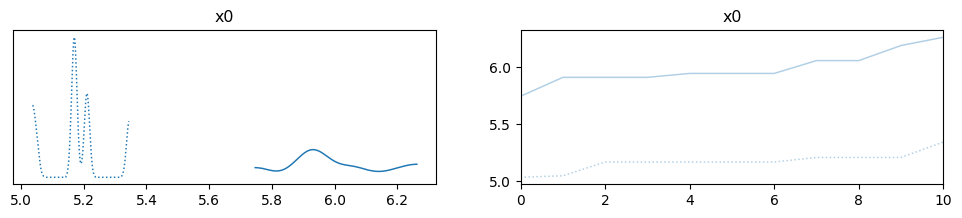

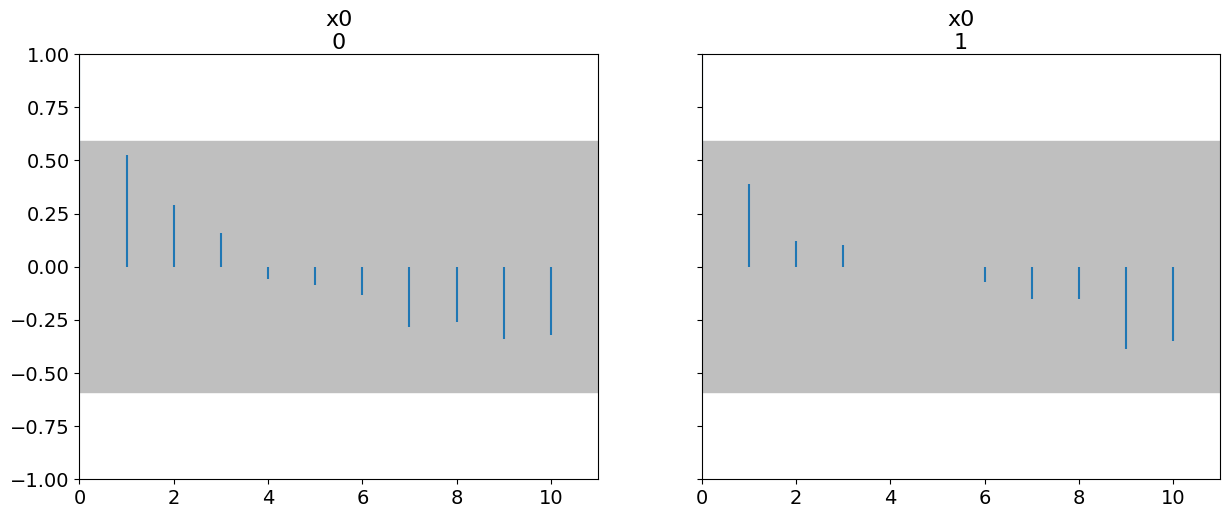

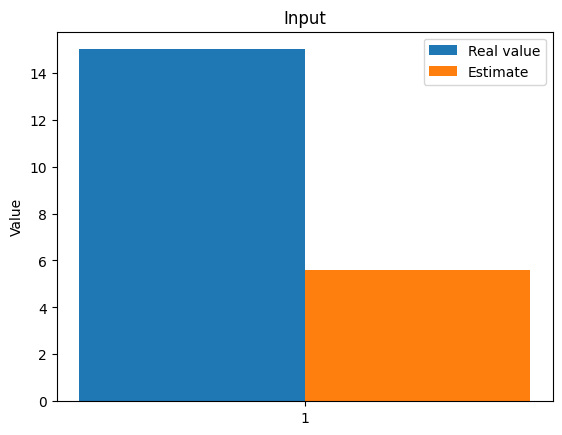

The function param_inverse took 5.006417751312256 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1
(30,)
real values are [15.]
Sampling chain 1/2
4.8674264073484945
[[4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]
 [4.86742641]]
before
[ 3.06336832  0.67093408  6.1170454   3.80284882  0.82438183 -2.58826876
 -4.80491018 -5.97076511 -5.40000963 -3.32793331 -1.51959741  0.04988337
  0.10706711 -0.16071463 11.15755367 26.12623596 29.30366516 26.50119019
 23.79914093 22.15497208 21.10040092 20.28896141 19.66222    19.49657631
 20.4395752  23.10238075 27.24619484 31.6894474  35.27259064 37.63872528]
(30,)
after
[ 3.06336832  0.67093408  6.117

Running chain, α = 0.50:   0%|          | 0/20 [00:00<?, ?it/s]

[[4.7223035]]
[[4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]
 [4.7223035]]
before
[ 3.02911329  0.66646516  6.38482857  4.11529922  0.92725563 -2.63080549
 -4.80237722 -5.80955029 -5.02319241 -2.91938639 -1.22020972  0.29881823
  0.25831425 -0.10852313 10.85642529 25.3469162  28.4142437  25.71721268
 23.13417435 21.5628109  20.54027939 19.70991707 19.0234127  18.84125137
 19.89998817 22.75567818 27.0567131  31.58657837 35.20399094 37.57427597]
(30,)
after
[ 3.02911329  0.66646516  6.38482857  4.11529922  0.92725563 -2.63080549
 -4.80237722 -5.80955029 -5.02319241 -2.91938639 -1.22020972  0.29881823
  0.25831425 -0.10852313 10.85642529 25.3469162  28.4142437  25.

Running chain, α = 0.50:  10%|█         | 2/20 [00:00<00:01, 10.13it/s]

[[5.12960762]]
[[5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]
 [5.12960762]]
before
[ 3.17439318  0.68711507  5.16124153  2.88478804  0.39342308 -2.36624765
 -4.35719824 -5.71685648 -5.71595287 -3.93714333 -2.08251238 -0.49026763
 -0.29180288 -0.4245435  11.4387722  27.26523209 30.75269508 27.81916809
 24.9251442  23.22344971 22.19109154 21.42864037 20.88247108 20.78349495
 21.62397385 23.96687508 27.76266289 31.97821808 35.45554733 37.79320908]
(30,)
after
[ 3.17439318  0.68711507  5.16124153  2.88478804  0.39342308 -2.36624765
 -4.35719824 -5.71685648 -5.71595287 -3.93714333 -2.08251238 -0.49026763
 -0.29180288 -0.4245435  11.43877

...

[[10.95672484]]
[[10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]
 [10.95672484]]
before
[ 2.91655731e+00  1.86190593e+00  4.35169935e-02 -7.81213164e-01
 -9.50355887e-01 -9.75920796e-01 -8.84491801e-01 -3.90859604e-01
  2.00259924e-01  1.88237309e-01  7.02437043e-01  1.37723684e+00
 -2.04301596e+00 -4.16942310e+00  1.18091145e+01  3.81939011e+01
  4.58157539e+01  4.42356873e+01  4.18983917e+01  3.98538017e+01
  3.79085236e+01  3.62782364e+01  3.56594734e+01  3.67436752e+01
  3.94560509e+01  4.34626312e+01  4.82712173e+01  5.30655479e+01
  5.68494415e+01  5.91667747e+01]
(30,)
after
[ 2.91655731e+00  1.86190

Running chain, α = 0.70:  95%|█████████▌| 19/20 [00:01<00:00,  9.55it/s]

[[11.50729294]]
[[11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]
 [11.50729294]]
before
[ 2.91141319e+00  1.84530532e+00  3.04726362e-02 -7.82535911e-01
 -9.49607253e-01 -9.88192439e-01 -9.83122706e-01 -7.55754828e-01
 -1.06317282e-01  1.35335684e-01  1.72461867e-01  9.08268929e-01
 -1.37089717e+00 -4.59688854e+00  1.11102657e+01  3.84481888e+01
  4.67446976e+01  4.54637909e+01  4.34920998e+01  4.20854836e+01
  4.10213051e+01  4.03513451e+01  3.99137878e+01  4.00142632e+01
  4.17177620e+01  4.52837296e+01  4.98987808e+01  5.43745956e+01
  5.78513680e+01  6.00036163e+01]
(30,)
after
[ 2.91141319e+00  1.84530

Running chain, α = 0.70: 100%|██████████| 20/20 [00:02<00:00,  9.47it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


before
[ 2.90978718e+00  1.83984935e+00  2.63231993e-02 -7.82721877e-01
 -9.48979735e-01 -9.90362048e-01 -1.00375998e+00 -8.52691054e-01
 -2.54028678e-01  1.04223132e-01  7.66098499e-02  6.13648891e-01
 -1.21268022e+00 -4.55476189e+00  1.09163151e+01  3.85414696e+01
  4.70818024e+01  4.59044456e+01  4.40291977e+01  4.27680283e+01
  4.18785439e+01  4.14538536e+01  4.13218689e+01  4.14249420e+01
  4.27045059e+01  4.59229507e+01  5.04112740e+01  5.48104820e+01
  5.81806831e+01  6.02708855e+01]
(30,)
after
[ 2.90978718e+00  1.83984935e+00  2.63231993e-02 -7.82721877e-01
 -9.48979735e-01 -9.90362048e-01 -1.00375998e+00 -8.52691054e-01
 -2.54028678e-01  1.04223132e-01  7.66098499e-02  6.13648891e-01
 -1.21268022e+00 -4.55476189e+00  1.09163151e+01  3.85414696e+01
  4.70818024e+01  4.59044456e+01  4.40291977e+01  4.27680283e+01
  4.18785439e+01  4.14538536e+01  4.13218689e+01  4.14249420e+01
  4.27045059e+01  4.59229507e+01  5.04112740e+01  5.48104820e+01
  5.81806831e+01  6.02708855e+01]
(30

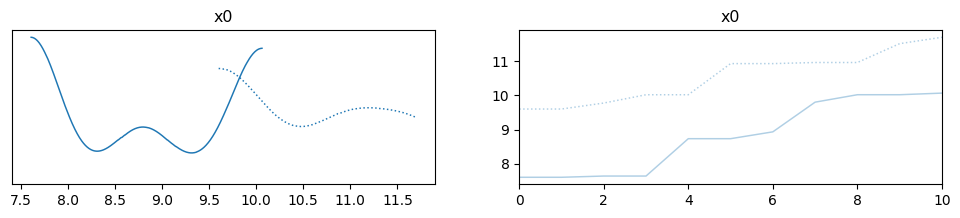

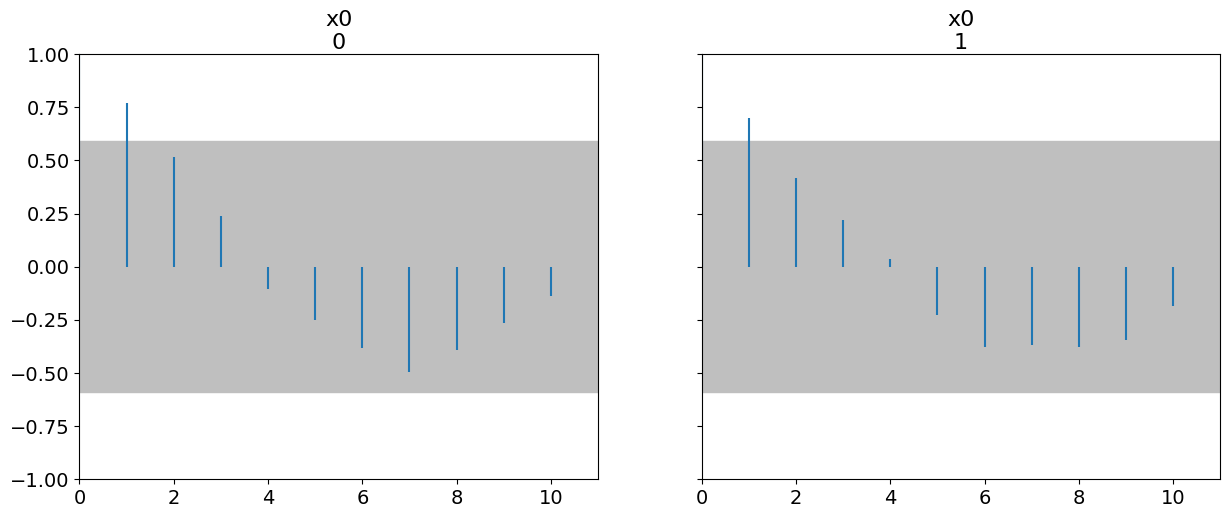

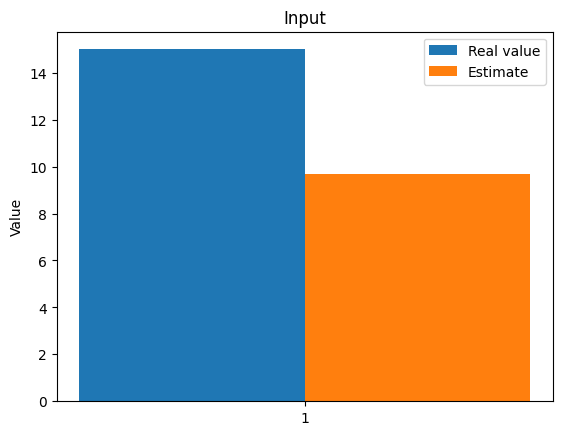

The function param_inverse took 4.9133219718933105 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1
(30,)
real values are [15.]
Sampling chain 1/2
3.3080320712231917
[[3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]
 [3.30803207]]
before
[ 3.07826757  0.71568716  0.24725568  0.26353014 -0.95126641  0.25406647
  0.72041917  1.21955216  1.9285351   1.51687658  0.64329422  0.23025835
 -1.94238341 -3.41852474  5.30289221 17.77743149 21.83950043 20.73148918
 18.84155273 17.07193756 15.57679844 14.64356613 14.54886532 15.53794384
 17.87681961 21.68128967 26.46731377 31.06335258 34.31947327 35.67660904]
(30,)
after
[ 3.07826757  0.71568716  0.24

Running chain, α = 1.00:   0%|          | 0/20 [00:00<?, ?it/s]

[[3.36967716]]
[[3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]
 [3.36967716]]
before
[ 3.06907988  0.70809114  0.232674    0.23244798 -1.01412117  0.15552616
  0.62656534  1.07267594  1.74561787  1.36433434  0.54123867  0.21876585
 -1.87599218 -3.35784912  5.41337824 17.95363235 22.00227547 20.89124298
 19.04034996 17.30265427 15.78762627 14.79700756 14.64155483 15.58672237
 17.9015255  21.69831085 26.49365234 31.12705421 34.47943878 36.04534149]
(30,)
after
[ 3.06907988  0.70809114  0.232674    0.23244798 -1.01412117  0.15552616
  0.62656534  1.07267594  1.74561787  1.36433434  0.54123867  0.21876585
 -1.87599218 -3.35784912  5.41337

Running chain, α = 1.00:  10%|█         | 2/20 [00:00<00:01,  9.85it/s]

[[3.37555731]]
[[3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]
 [3.37555731]]
before
[ 3.06823206  0.70742357  0.23140943  0.22970712 -1.01965916  0.14507771
  0.61591756  1.05672574  1.72649479  1.34933591  0.53236294  0.21903801
 -1.8681401  -3.35079288  5.42479563 17.97094727 22.01787758 20.90616608
 19.05888748 17.32461548 15.80814075 14.81216908 14.6508112  15.59160995
 17.9039669  21.69986534 26.49585342 31.13230515 34.49267578 36.07649612]
(30,)
after
[ 3.06823206  0.70742357  0.23140943  0.22970712 -1.01965916  0.14507771
  0.61591756  1.05672574  1.72649479  1.34933591  0.53236294  0.21903801
 -1.8681401  -3.35079288  5.42479

...

Running chain, α = 0.50:  20%|██        | 4/20 [00:00<00:01, 10.80it/s]

[[6.16762865]]
[[6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]
 [6.16762865]]
before
[ 4.97067213  3.72733498  0.6761235  -0.55976522 -0.79155242 -1.2787534
 -1.75087011 -2.25836325 -2.79651737 -3.06168604 -2.69390297 -2.31944466
 -2.66811752 -2.77308226 10.58139706 29.17113876 34.23955536 32.05078125
 28.73973846 26.139431   24.78896904 24.40800285 24.6485405  25.48669434
 27.15773964 29.85326195 33.21645737 36.33520508 38.58047104 40.02903366]
(30,)
after
[ 4.97067213  3.72733498  0.6761235  -0.55976522 -0.79155242 -1.2787534
 -1.75087011 -2.25836325 -2.79651737 -3.06168604 -2.69390297 -2.31944466
 -2.66811752 -2.77308226 10.5813970

Running chain, α = 0.60:  20%|██        | 4/20 [00:00<00:01,  9.54it/s]

[[6.30741059]]
[[6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]
 [6.30741059]]


KeyboardInterrupt: 

In [11]:
# true parameters
sigma_noise=[0.1,0.05]
n_data=[30,50]
parameters=np.array([15.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.1])
rwmh_adaptive = True
iterations =20
burnin = 10
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")

In [ ]:
# true parameters
sigma_noise=[0.1,0.05]
n_data=[30,50]
parameters=np.array([15.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")


noise 0.1
nb.data 30
rwmh.scaling 0.5
(30,)
real values are [15.]
Sampling chain 1/2
3.3414201189802766
[[3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]
 [3.34142012]]
before
[[ 3.07321787]
 [ 0.71143472]
 [ 0.23906171]
 [ 0.24615228]
 [-0.98627198]
 [ 0.20324993]
 [ 0.67362058]
 [ 1.14458287]
 [ 1.83342636]
 [ 1.43529689]
 [ 0.58595753]
 [ 0.22073054]
 [-1.9100672 ]
 [-3.38868332]
 [ 5.36064672]
 [17.87168121]
 [21.92752075]
 [20.81877899]
 [18.95023155]
 [17.19696999]
 [15.69001293]
 [14.7254324 ]
 [14.5980978 ]
 [15.56381321]
 [17.89002228]
 [21.69069099]
 [26.48233795]
 [31.09991646]
 [34.41112137]
 [35.8861084 ]]
(30, 1)
after
[ 3

Running chain, α = 1.00:   0%|          | 0/2000 [00:00<?, ?it/s]

[[3.48558069]]
[[3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]
 [3.48558069]]


Running chain, α = 0.67:   0%|          | 2/2000 [00:00<02:54, 11.46it/s]

before
[[ 3.05332708]
 [ 0.69649637]
 [ 0.21106946]
 [ 0.18501604]
 [-1.10150158]
 [-0.08035469]
 [ 0.36296129]
 [ 0.69580317]
 [ 1.31485426]
 [ 1.05343795]
 [ 0.39038897]
 [ 0.26349199]
 [-1.67534912]
 [-3.1771307 ]
 [ 5.6689682 ]
 [18.31370544]
 [22.31459999]
 [21.17712402]
 [19.39136505]
 [17.73125267]
 [16.20335579]
 [15.1129694 ]
 [14.8382225 ]
 [15.69165039]
 [17.95307541]
 [21.72803307]
 [26.53005028]
 [31.21013641]
 [34.68906021]
 [36.54911423]]
(30, 1)
after
[ 3.05332708  0.69649637  0.21106946  0.18501604 -1.10150158 -0.08035469
  0.36296129  0.69580317  1.31485426  1.05343795  0.39038897  0.26349199
 -1.67534912 -3.1771307   5.6689682  18.31370544 22.31459999 21.17712402
 19.39136505 17.73125267 16.20335579 15.1129694  14.8382225  15.69165039
 17.95307541 21.72803307 26.53005028 31.21013641 34.68906021 36.54911423]
(30,)
[[2.87859741]]
[[2.87859741]
 [2.87859741]
 [2.87859741]
 [2.87859741]
 [2.87859741]
 [2.87859741]
 [2.87859741]
 [2.87859741]
 [2.87859741]
 [2.87859741]
 

...

Running chain, α = 0.24:  28%|██▊       | 562/2000 [00:48<02:18, 10.42it/s]

before
[[ 2.90999126e+00]
 [ 1.80303848e+00]
 [ 1.90696716e-02]
 [-7.28192449e-01]
 [-8.64899993e-01]
 [-8.98706079e-01]
 [-9.61039424e-01]
 [-1.07487810e+00]
 [-1.14755762e+00]
 [-8.82627368e-01]
 [-6.82229996e-02]
 [-1.89470768e-01]
 [-3.17227364e+00]
 [-4.38992691e+00]
 [ 1.33789272e+01]
 [ 4.34257965e+01]
 [ 5.34797516e+01]
 [ 5.27685699e+01]
 [ 5.09248619e+01]
 [ 4.98330536e+01]
 [ 4.89926491e+01]
 [ 4.82644157e+01]
 [ 4.82199173e+01]
 [ 4.92387619e+01]
 [ 5.14816475e+01]
 [ 5.50326996e+01]
 [ 5.94499626e+01]
 [ 6.34556999e+01]
 [ 6.56320190e+01]
 [ 6.57698441e+01]]
(30, 1)
after
[ 2.90999126e+00  1.80303848e+00  1.90696716e-02 -7.28192449e-01
 -8.64899993e-01 -8.98706079e-01 -9.61039424e-01 -1.07487810e+00
 -1.14755762e+00 -8.82627368e-01 -6.82229996e-02 -1.89470768e-01
 -3.17227364e+00 -4.38992691e+00  1.33789272e+01  4.34257965e+01
  5.34797516e+01  5.27685699e+01  5.09248619e+01  4.98330536e+01
  4.89926491e+01  4.82644157e+01  4.82199173e+01  4.92387619e+01
  5.14816475e+01  

Running chain, α = 0.24:  28%|██▊       | 564/2000 [00:49<02:04, 11.51it/s]


before
[[ 2.90286160e+00]
 [ 1.80855930e+00]
 [ 7.27832317e-03]
 [-7.71737456e-01]
 [-9.28336501e-01]
 [-9.76436496e-01]
 [-1.04623330e+00]
 [-1.15424144e+00]
 [-1.13137281e+00]
 [-5.60161471e-01]
 [-4.69983816e-02]
 [-6.04412436e-01]
 [-2.57921982e+00]
 [-3.36642694e+00]
 [ 1.17063761e+01]
 [ 3.99930534e+01]
 [ 5.00928001e+01]
 [ 4.95852051e+01]
 [ 4.80600548e+01]
 [ 4.72223625e+01]
 [ 4.66074905e+01]
 [ 4.62967949e+01]
 [ 4.67090569e+01]
 [ 4.79335213e+01]
 [ 4.99728470e+01]
 [ 5.27253036e+01]
 [ 5.57402267e+01]
 [ 5.85882912e+01]
 [ 6.09102402e+01]
 [ 6.22524490e+01]]
(30, 1)
after
[ 2.90286160e+00  1.80855930e+00  7.27832317e-03 -7.71737456e-01
 -9.28336501e-01 -9.76436496e-01 -1.04623330e+00 -1.15424144e+00
 -1.13137281e+00 -5.60161471e-01 -4.69983816e-02 -6.04412436e-01
 -2.57921982e+00 -3.36642694e+00  1.17063761e+01  3.99930534e+01
  5.00928001e+01  4.95852051e+01  4.80600548e+01  4.72223625e+01
  4.66074905e+01  4.62967949e+01  4.67090569e+01  4.79335213e+01
  4.99728470e+01  

KeyboardInterrupt: 

noise 0.1
nb.data 30
rwmh.scaling 0.5


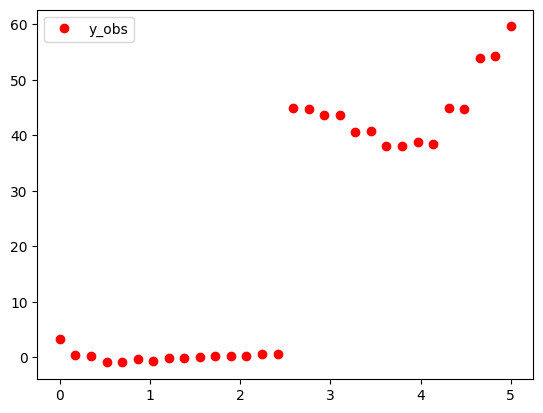

real values are [11.25]
Sampling chain 1/2


Running chain, α = 0.28: 100%|██████████| 2000/2000 [03:04<00:00, 10.84it/s]


Sampling chain 2/2


Running chain, α = 0.27: 100%|██████████| 2000/2000 [03:03<00:00, 10.87it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [11.144]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  11.144  0.121  10.922   11.367      0.006    0.005     342.0     350.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.106]



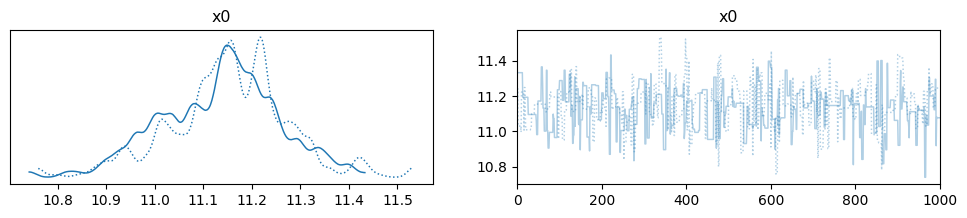

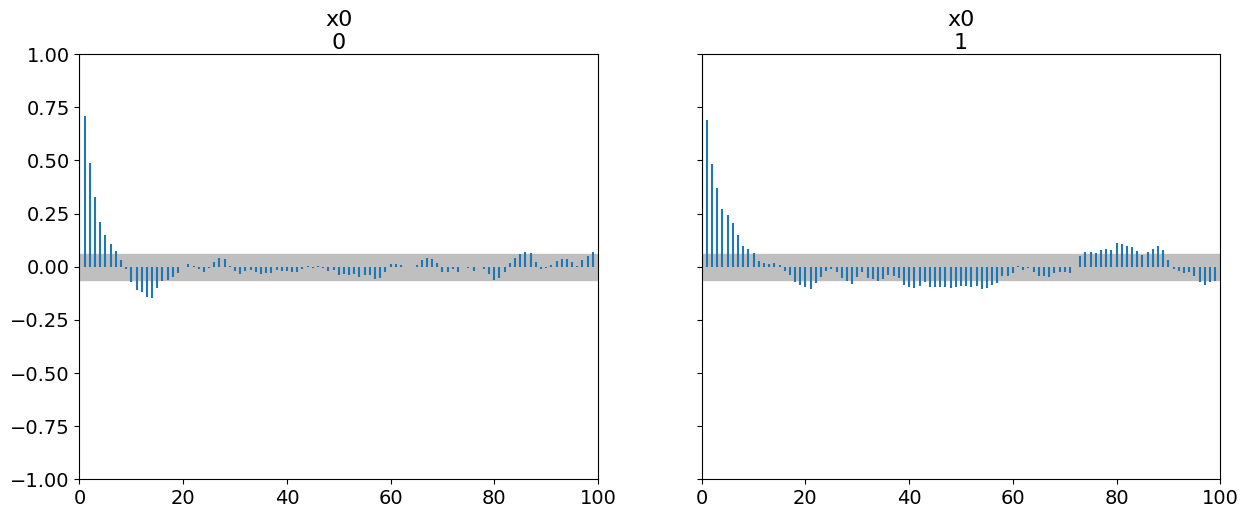

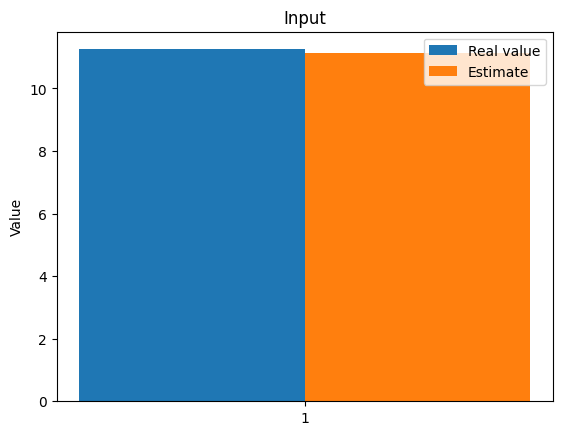

The function param_inverse took 369.1776361465454 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.5


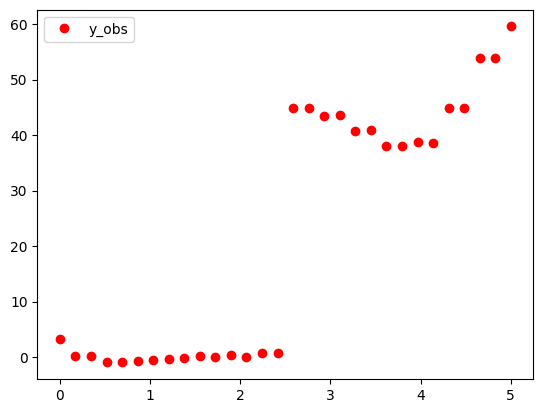

real values are [11.25]
Sampling chain 1/2


Running chain, α = 0.19: 100%|██████████| 2000/2000 [03:03<00:00, 10.93it/s]


Sampling chain 2/2


Running chain, α = 0.22:  80%|███████▉  | 1590/2000 [02:27<00:38, 10.78it/s]


KeyboardInterrupt: 

In [ ]:
# true parameters
sigma_noise=[0.1,0.05]
n_data=[30,50]
parameters=np.array([11.25])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")


noise 0.1
nb.data 30
rwmh.scaling 0.5


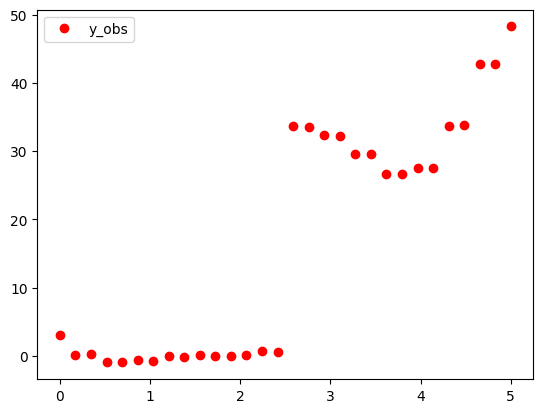

real values are [7.5]
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 2000/2000 [03:03<00:00, 10.88it/s]


Sampling chain 2/2


Running chain, α = 0.22: 100%|██████████| 2000/2000 [03:05<00:00, 10.78it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [7.326]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.326  0.179   6.953    7.639      0.011    0.008     282.0     275.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.174]



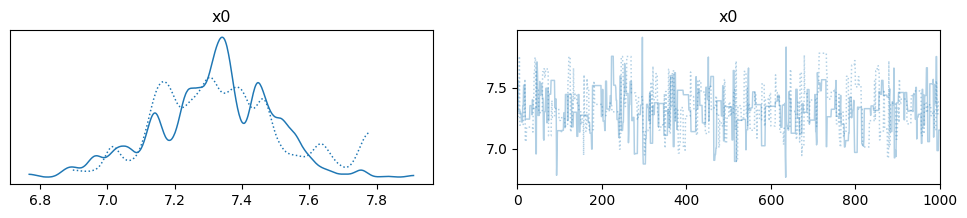

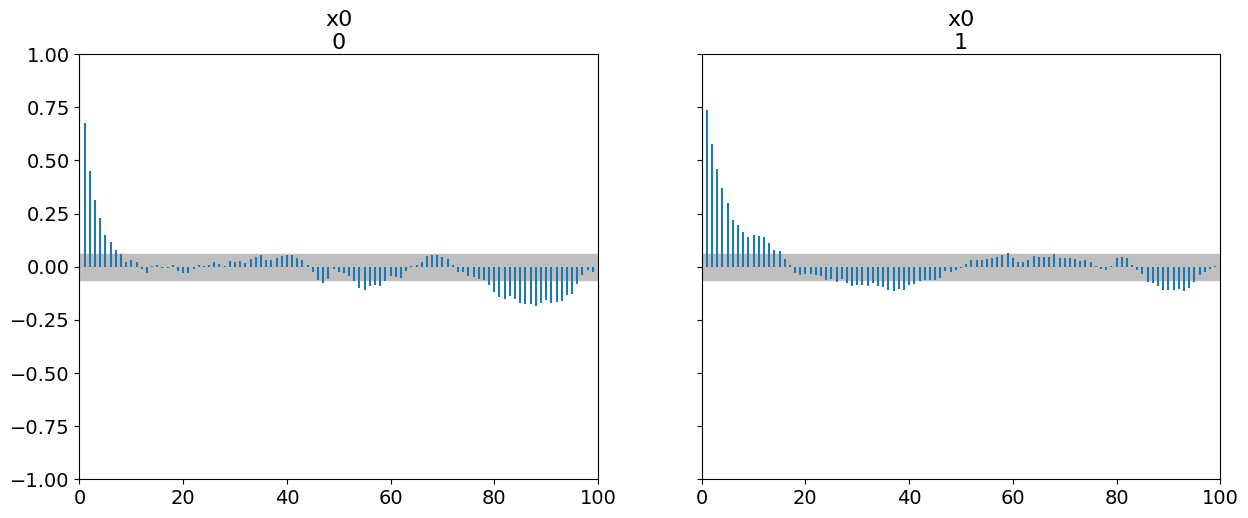

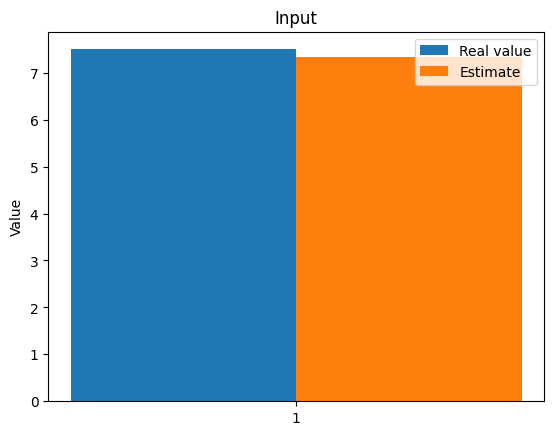

The function param_inverse took 370.19619035720825 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.5


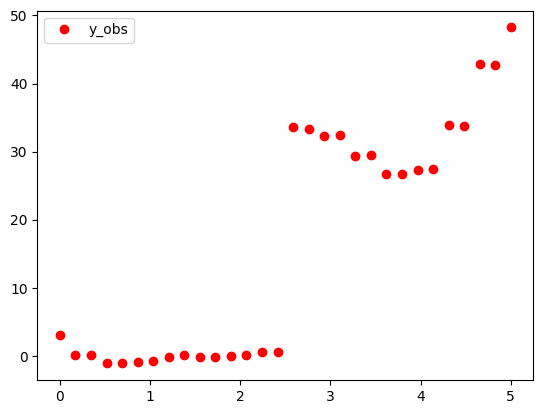

real values are [7.5]
Sampling chain 1/2


Running chain, α = 0.66:  14%|█▍        | 285/2000 [00:27<02:45, 10.35it/s]


KeyboardInterrupt: 

In [ ]:
# true parameters
sigma_noise=[0.1,0.05]
n_data=[30,50]
parameters=np.array([7.5])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")


noise 0.1
nb.data 30
rwmh.scaling 0.5


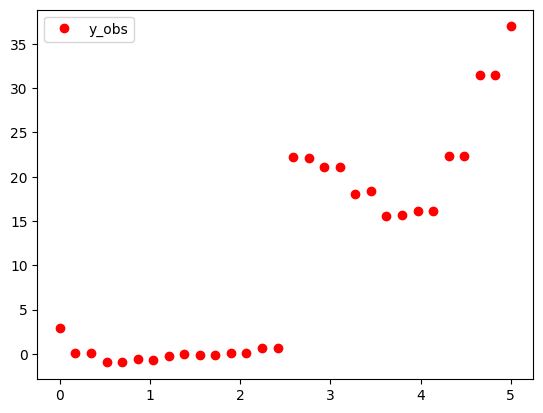

real values are [3.75]
Sampling chain 1/2


Running chain, α = 0.21: 100%|██████████| 2000/2000 [03:05<00:00, 10.80it/s]


Sampling chain 2/2


Running chain, α = 0.32: 100%|██████████| 2000/2000 [03:05<00:00, 10.80it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [3.717]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.717  0.109   3.494    3.891      0.006    0.004     395.0     450.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.033]



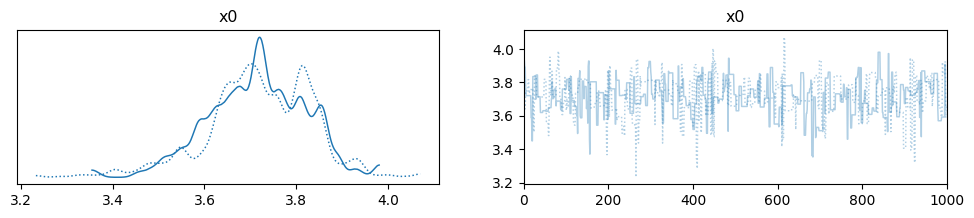

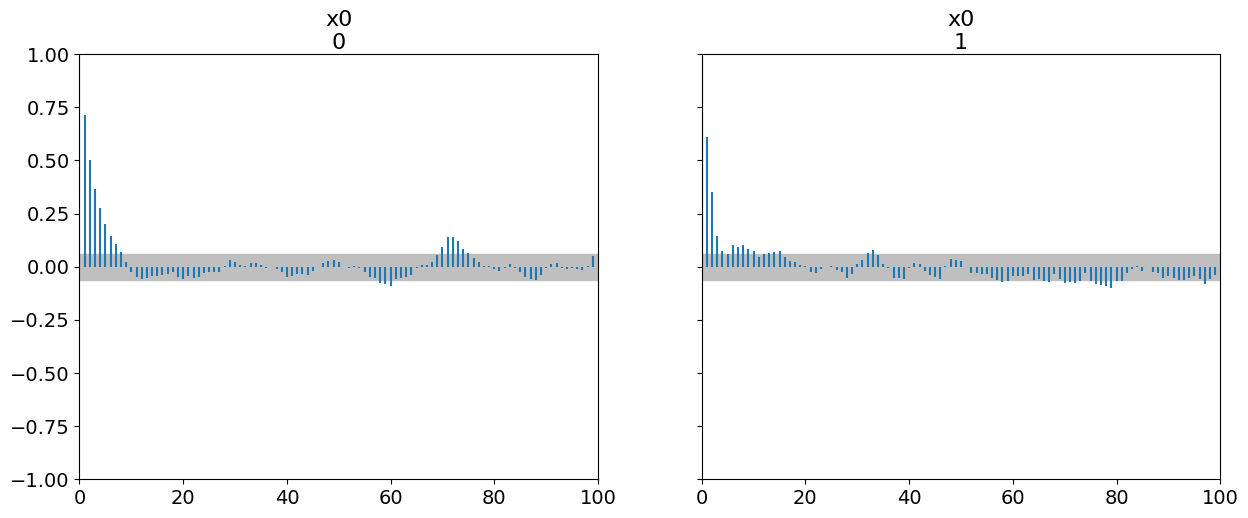

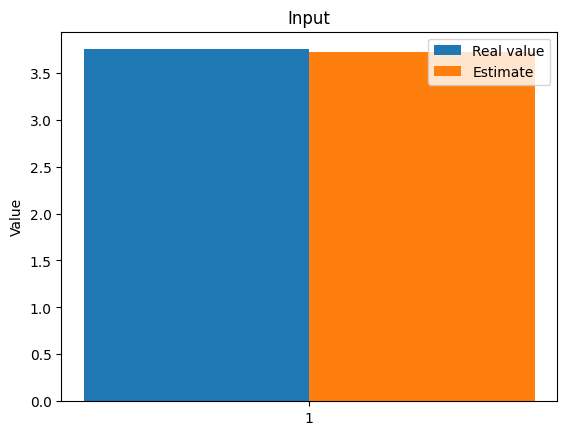

The function param_inverse took 371.4686508178711 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.5


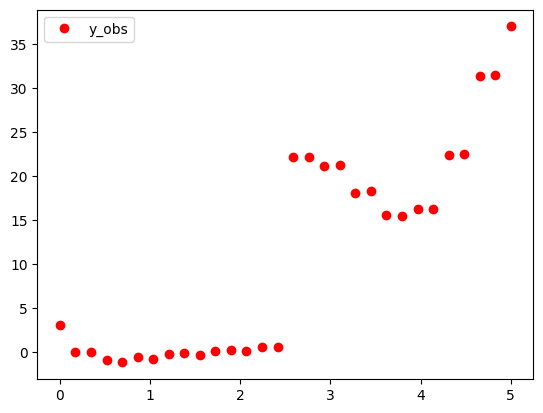

real values are [3.75]
Sampling chain 1/2


Running chain, α = 0.72:   4%|▎         | 71/2000 [00:06<03:10, 10.15it/s]


KeyboardInterrupt: 

In [ ]:
# true parameters
sigma_noise=[0.1,0.05]
n_data=[30,50]
parameters=np.array([3.75])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")


noise 0.1
nb.data 30
rwmh.scaling 0.5


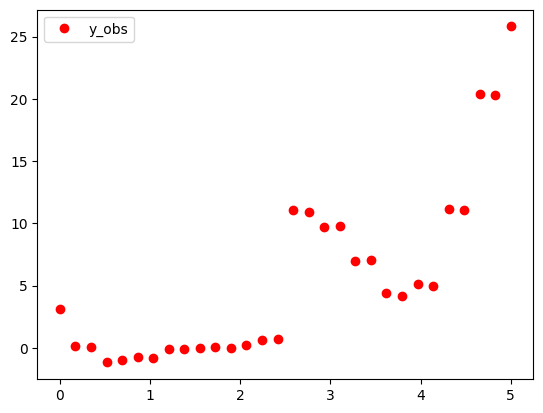

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [05:27<00:00,  6.11it/s]


Sampling chain 2/2


Running chain, α = 0.18: 100%|██████████| 2000/2000 [05:33<00:00,  6.00it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.023]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.023  0.072  -0.108    0.148      0.004    0.003     254.0     231.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.023]



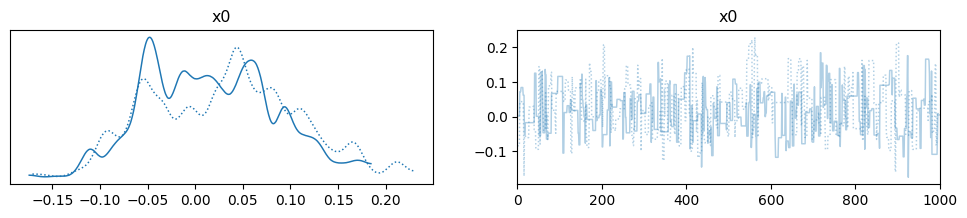

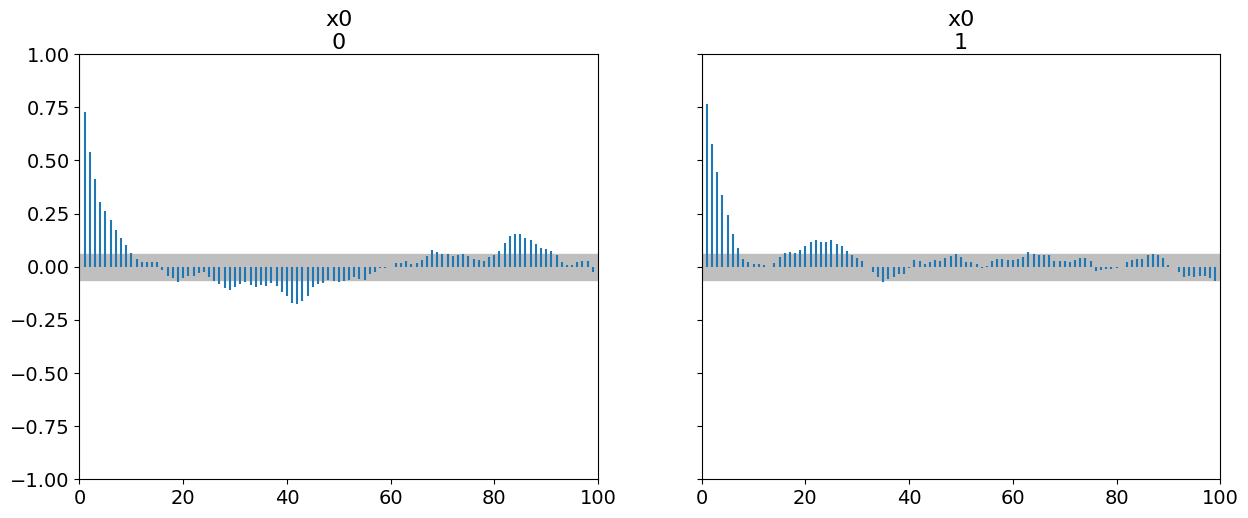

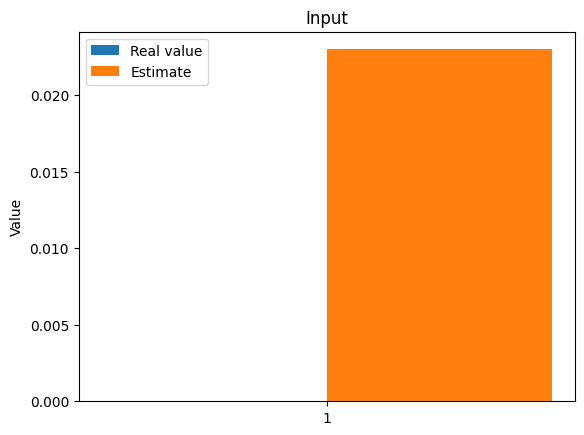

The function param_inverse took 662.1848568916321 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.5


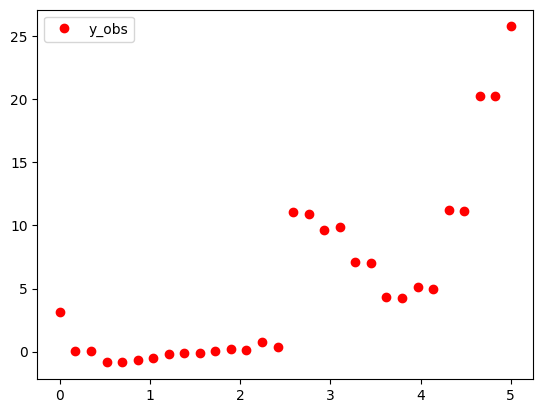

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.22: 100%|██████████| 2000/2000 [05:27<00:00,  6.12it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 2000/2000 [05:38<00:00,  5.91it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.021]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.021  0.076  -0.119    0.155      0.004    0.003     383.0     396.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.021]



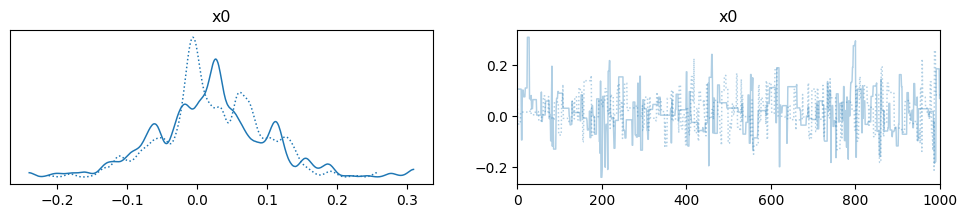

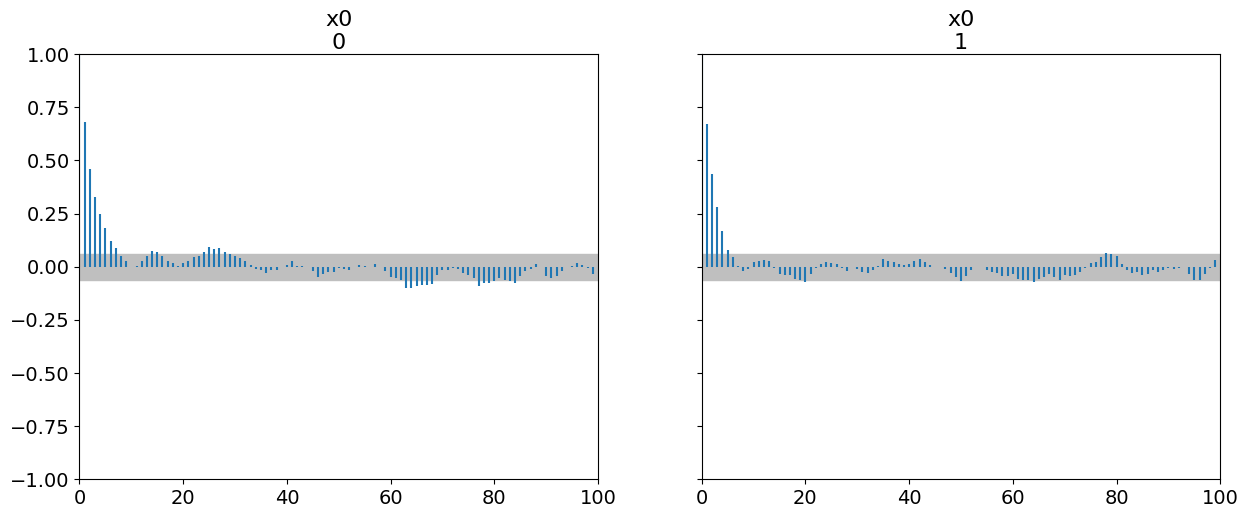

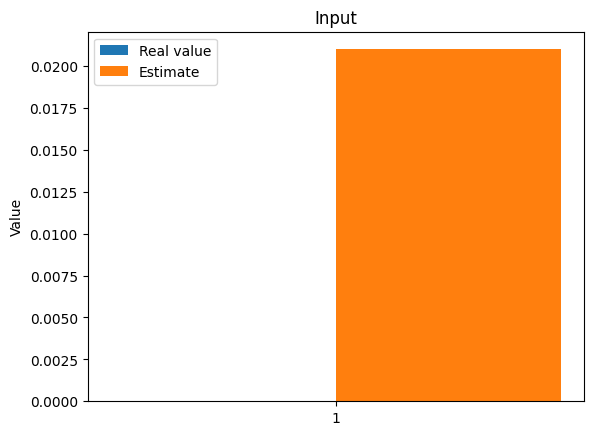

The function param_inverse took 667.0472249984741 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1


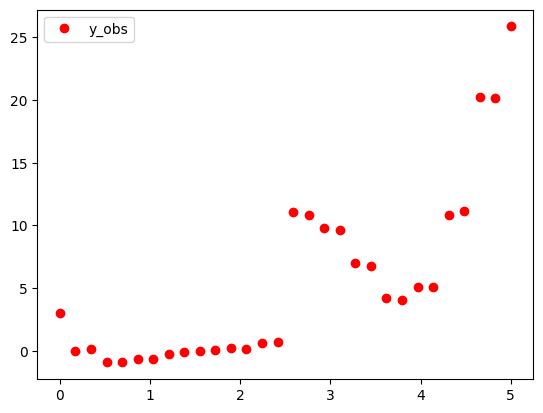

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.30: 100%|██████████| 2000/2000 [05:31<00:00,  6.03it/s]


Sampling chain 2/2


Running chain, α = 0.34: 100%|██████████| 2000/2000 [05:35<00:00,  5.96it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.185]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.185  0.245  -0.216    0.604      0.018    0.013     158.0     211.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.185]



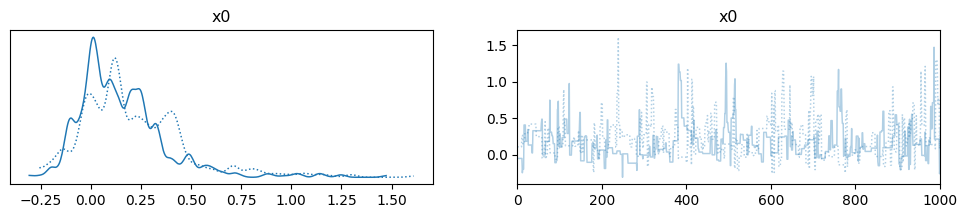

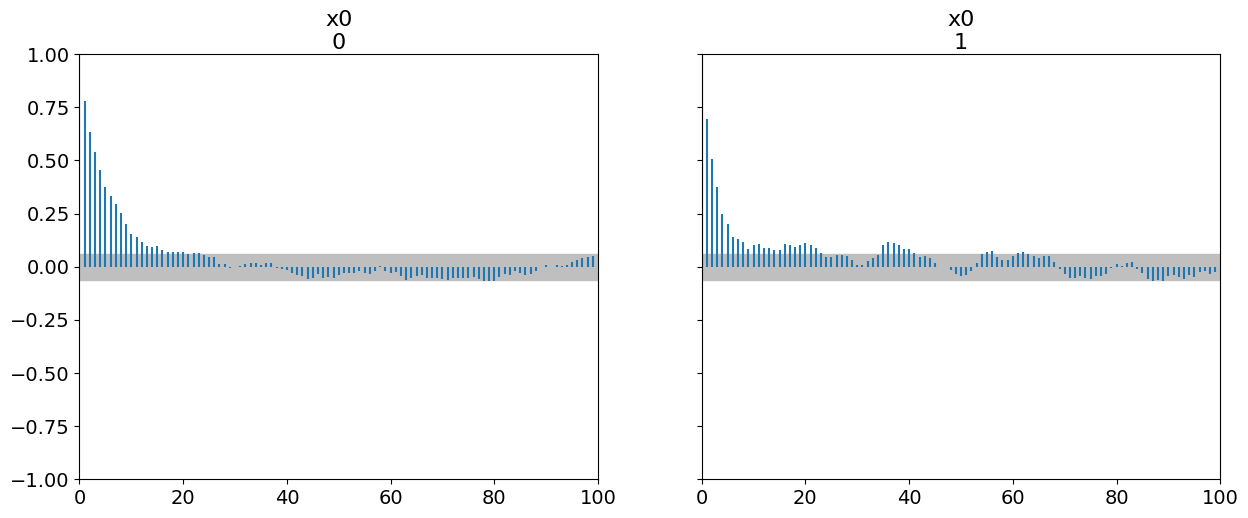

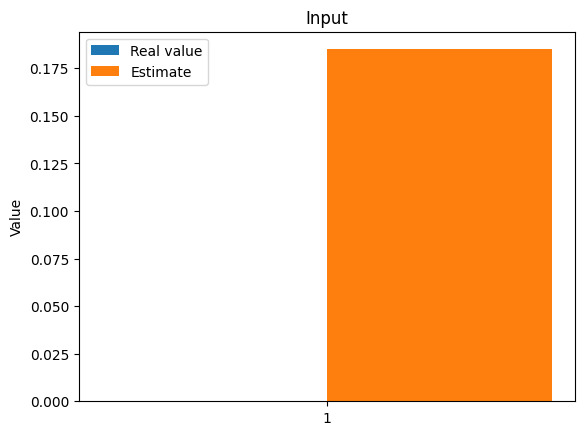

The function param_inverse took 668.7149550914764 seconds.
noise 0.1
nb.data 30
rwmh.scaling 0.1


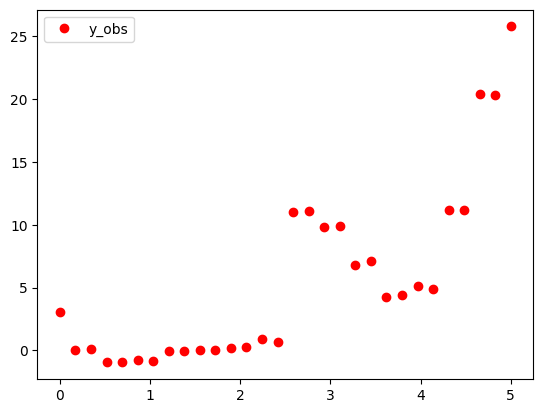

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 2000/2000 [05:32<00:00,  6.01it/s]


Sampling chain 2/2


Running chain, α = 0.10: 100%|██████████| 2000/2000 [05:55<00:00,  5.62it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.203]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.203  0.273  -0.254    0.723      0.018    0.013     271.0     267.0   

    r_hat  
x0   1.01  
Autocorrelation...
the difference between estimated values [0.203]



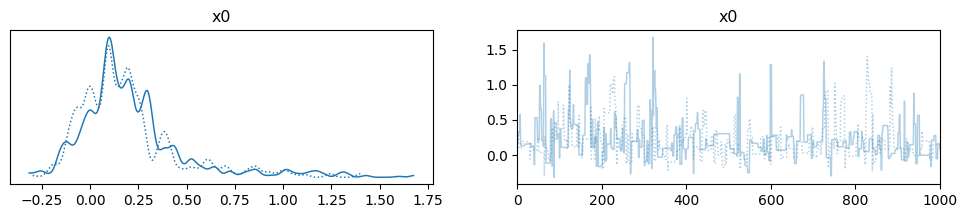

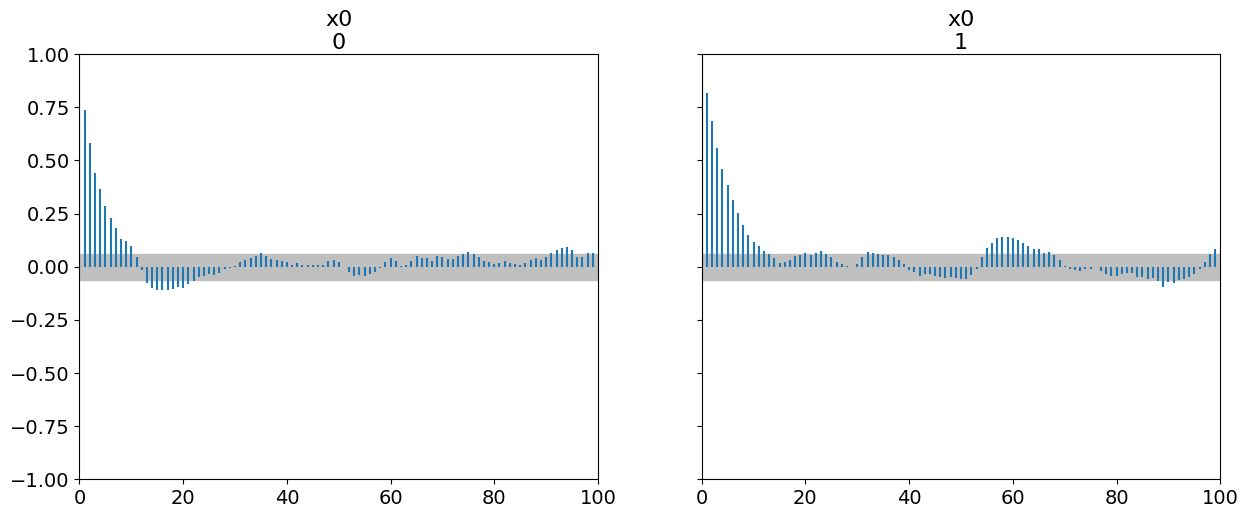

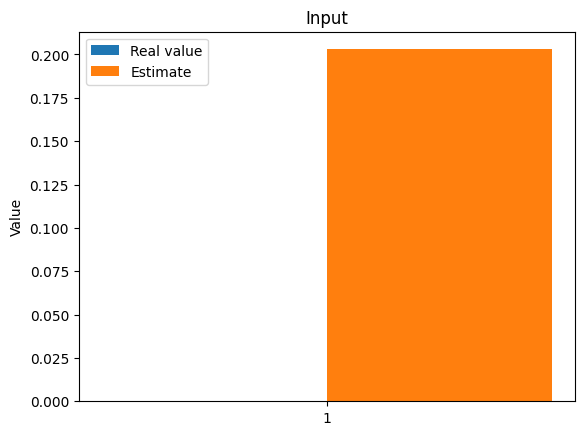

The function param_inverse took 689.9223246574402 seconds.
noise 0.1
nb.data 50
rwmh.scaling 0.5


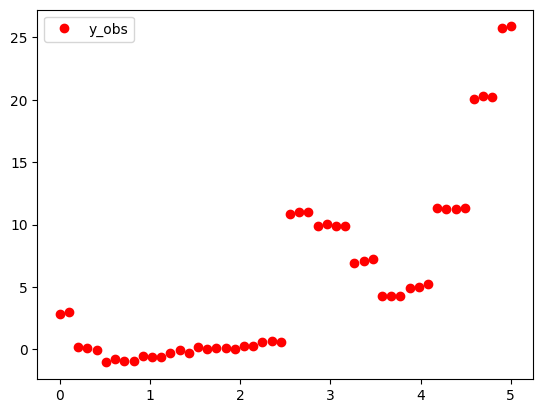

real values are [0.]
Sampling chain 1/2


Running chain, α = 0.27: 100%|██████████| 2000/2000 [06:12<00:00,  5.36it/s]


Sampling chain 2/2


Running chain, α = 0.26:  79%|███████▊  | 1574/2000 [04:14<01:08,  6.18it/s]


KeyboardInterrupt: 

In [ ]:
# true parameters
sigma_noise=[0.1,0.05]
n_data=[30,50]
parameters=np.array([0.])
indices = np.where(datahf[:,1] == parameters)[0]
mean_prior=np.array([5.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=np.array([2.,4.])

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.1])
rwmh_adaptive = True
iterations =2000
burnin = 1000
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        for s in range(len(sigma)):
            for r in range(len(rmwh_scaling)):
                print(f"noise {sigma_noise[noise]}")
                print(f"nb.data {n_data[n]}")
                print(f"rwmh.scaling {rmwh_scaling[s]}")


                t_eval=np.linspace(0.,5.,n_data[n])
        # prior : in questo caso possibile testare la funzione beta


                closest_indices= indices[0]+np.argmin( np.abs(datahf[indices,0,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
                nearest_x=datahf[closest_indices,0]
                y_obs=Yhf[closest_indices] # chekc se giusto

               

                t_eval=t_eval.reshape(-1,1)
                estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, rmwh_scaling=rmwh_scaling[r],cov_noise=sigma_noise[noise], cov_likelihood=sigma[s]**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")


# MCMC using tinyDA

In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.9
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=4

In [ ]:
# true parameters
sigma_noise=[0.5]
n_data=[30]
parameters=np.array([10.])
indices = np.where(datahf[:,0] == parameters)[0]
mean_prior=np.array([2.])
cov_prior=np.diag([ 1.])
# cov_linkelihood
sigma=3.

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = 1.
rwmh_adaptive = True
iterations =1500
burnin = 800
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        print(f"noise {sigma_noise[noise]}")
        print(f"nb.data {n_data[n]}")


        t_eval=np.linspace(0.,5.,n_data[n])
# prior : in questo caso possibile testare la funzione beta


        closest_indices= np.argmin( np.abs(datahf[indices,1,None] - t_eval), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
        nearest_x=datahf[closest_indices,1]
        y_obs=Yhf[closest_indices] # chekc se giusto
        t_eval=t_eval.reshape(-1,1)
        estimate_MF=final_model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, cov_noise=sigma_noise[noise], cov_likelihood=sigma**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MH")



real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.11: 100%|██████████| 2000/2000 [03:13<00:00, 10.34it/s]


Sampling chain 2/4


Running chain, α = 0.13: 100%|██████████| 2000/2000 [03:00<00:00, 11.07it/s]


Sampling chain 3/4


Running chain, α = 0.39: 100%|██████████| 2000/2000 [02:53<00:00, 11.50it/s]


Sampling chain 4/4


Running chain, α = 0.22: 100%|██████████| 2000/2000 [02:51<00:00, 11.68it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.684 1.924 2.76  3.445]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.684  0.445   0.954    2.437      0.090    0.065      24.0      76.0   
x1  1.924  0.372   1.273    2.429      0.073    0.052      36.0      92.0   
x2  2.760  0.179   2.509    3.054      0.045    0.033      14.0      46.0   
x3  3.445  0.287   3.211    4.042      0.047    0.034      55.0      24.0   

    r_hat  
x0   1.14  
x1   1.10  
x2   1.23  
x3   1.08  
Autocorrelation...
the difference between estimated values [0.684 0.076 0.24  0.555]
 the difference between outputs of two models are [0.50998247 0.10786045 1.04712868 0.54472923]


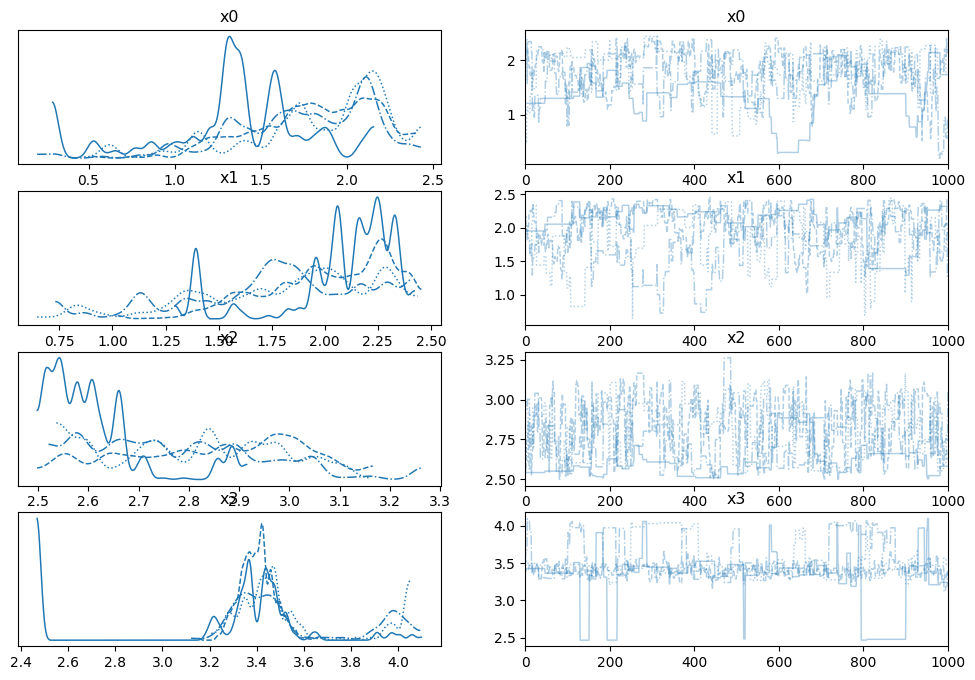

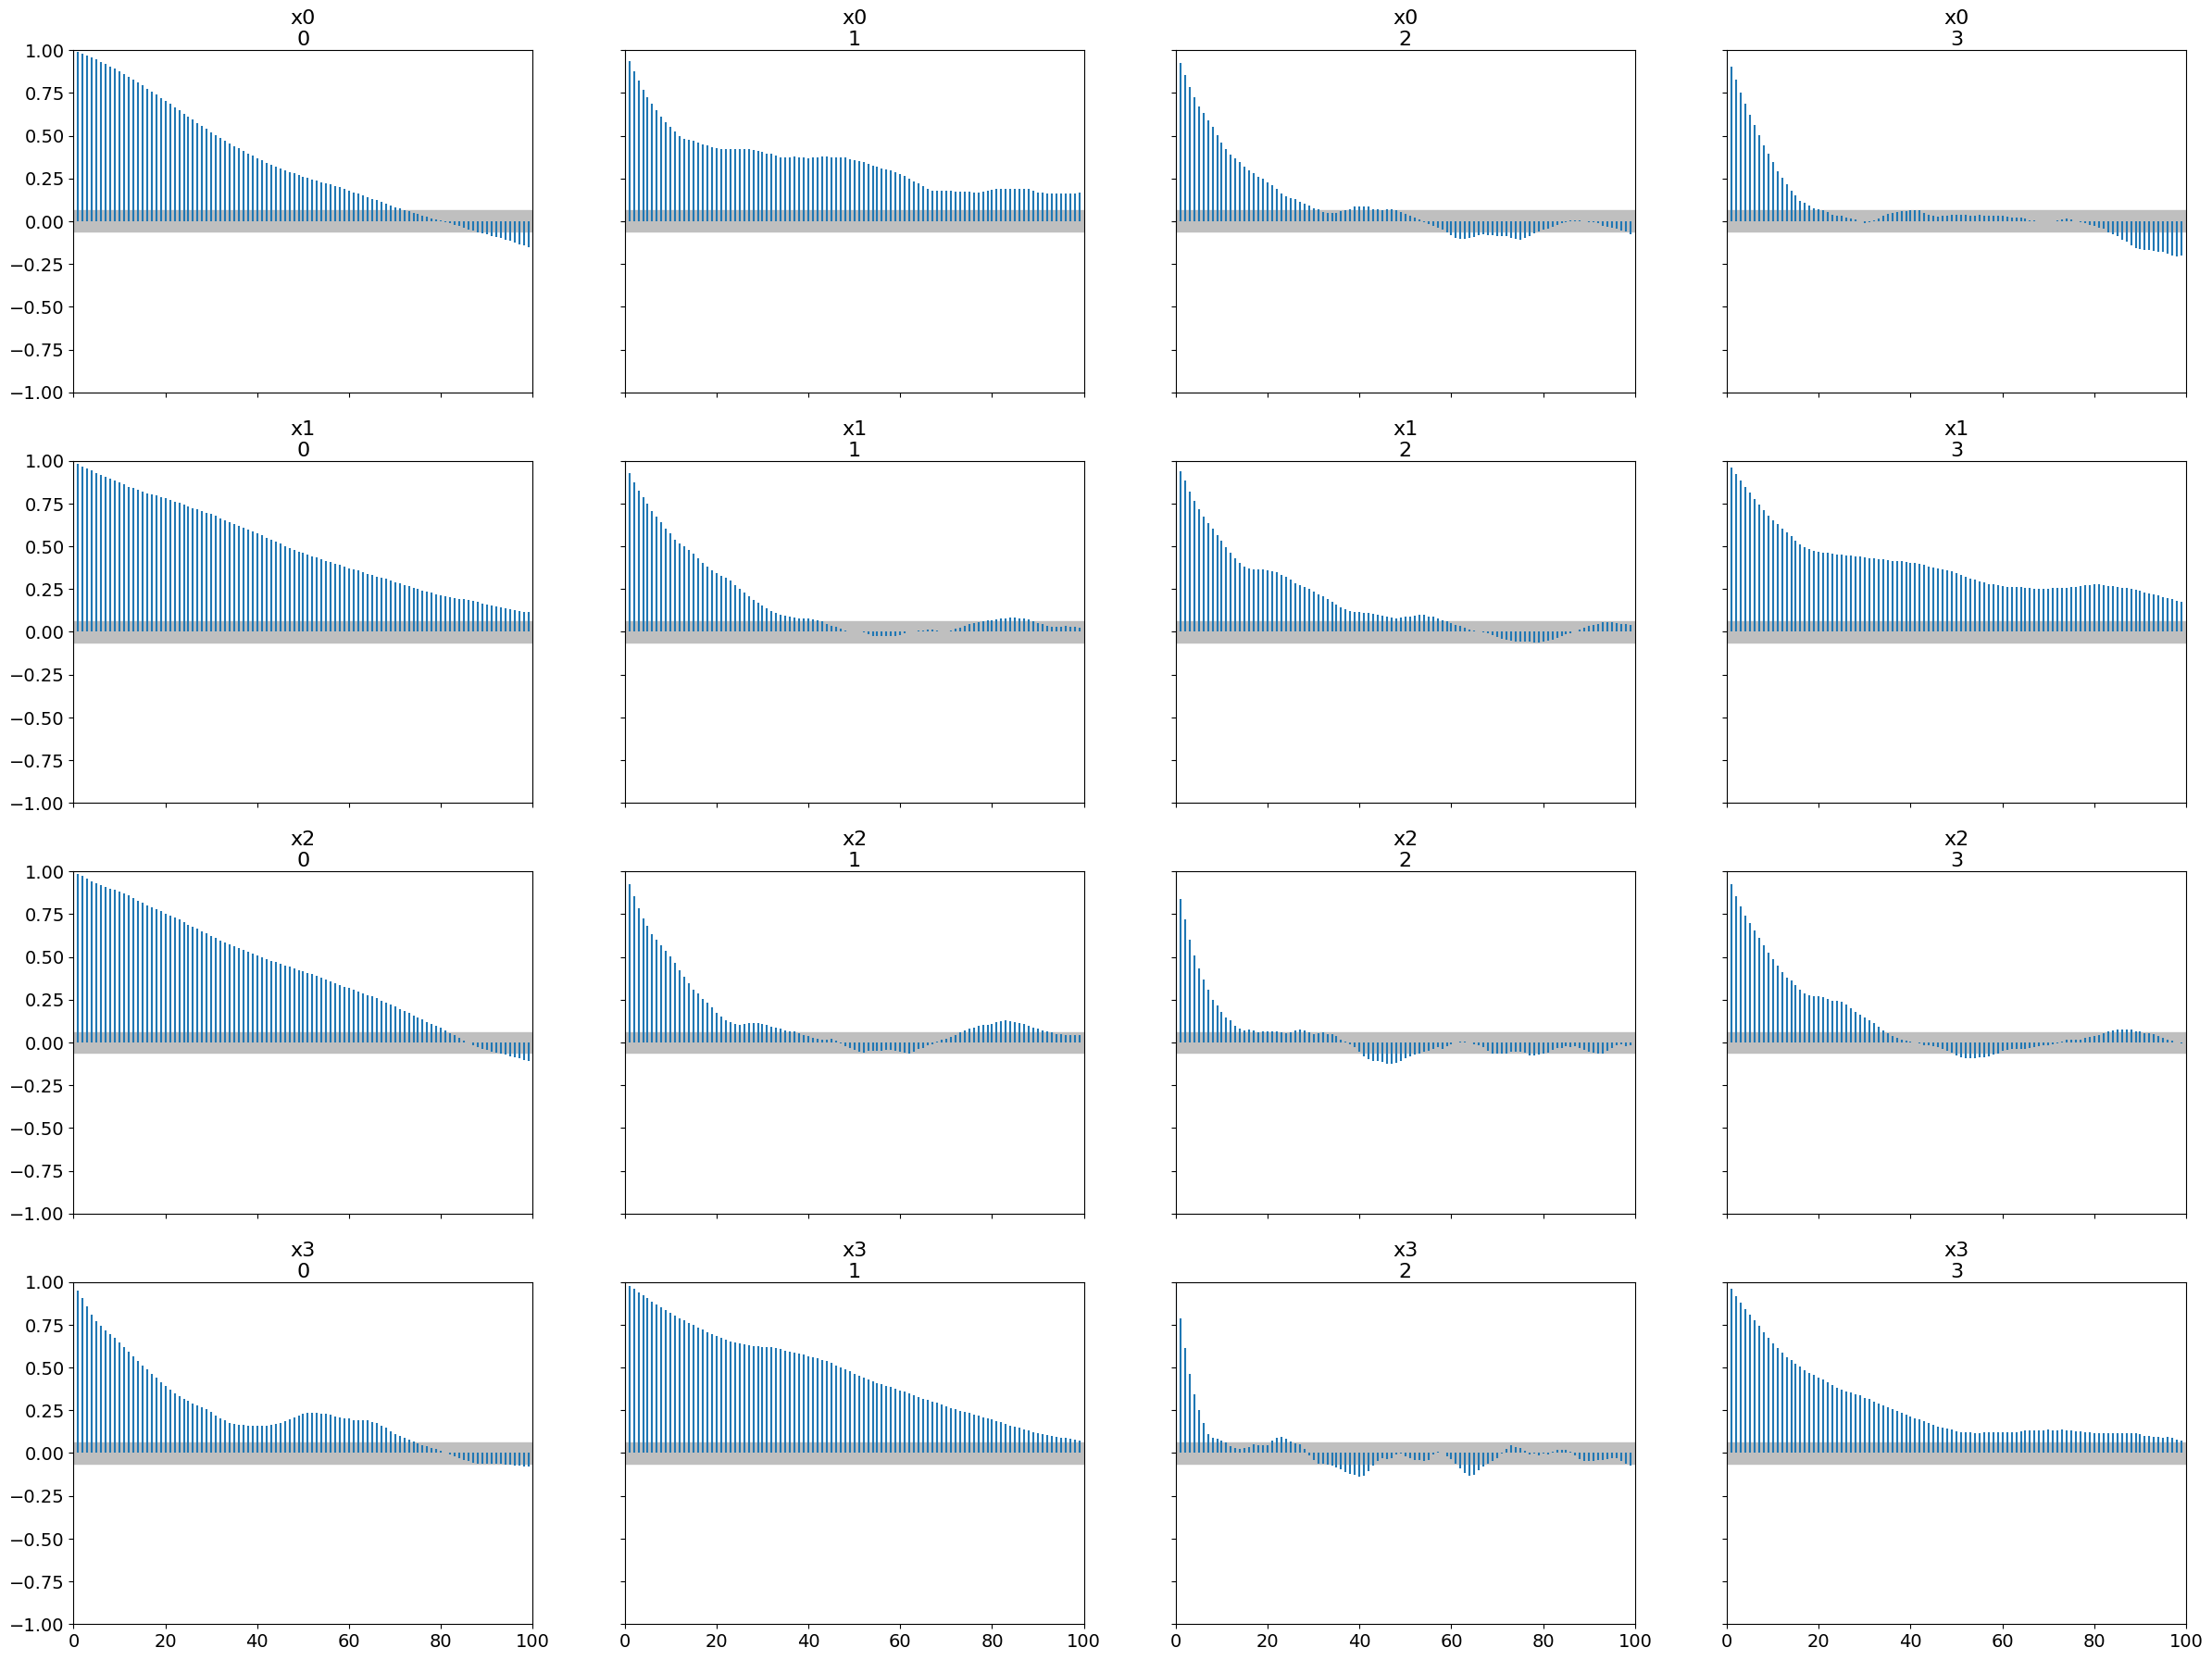

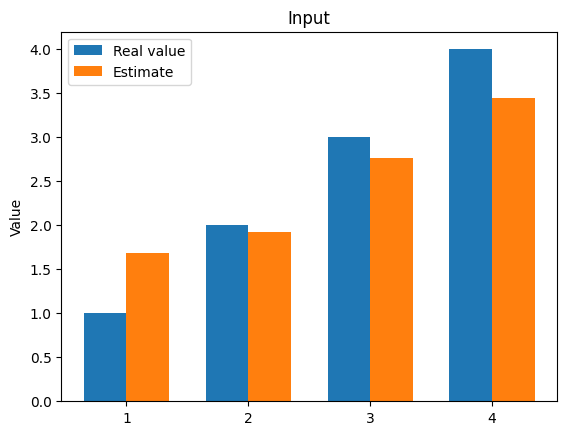

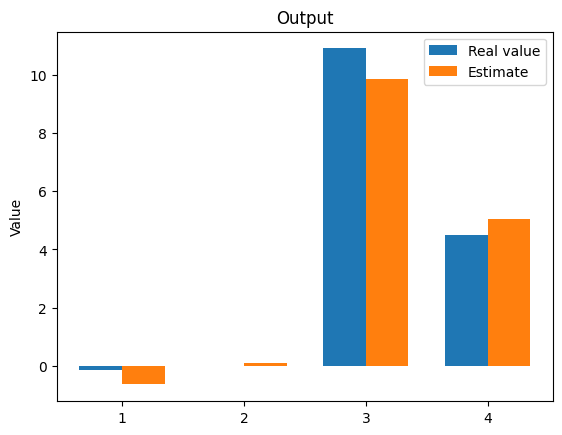

The function inverse took 766.9475445747375 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.03: 100%|██████████| 2000/2000 [01:28<00:00, 22.54it/s]


Sampling chain 2/4


Running chain, α = 0.01: 100%|██████████| 2000/2000 [01:28<00:00, 22.49it/s]


Sampling chain 3/4


Running chain, α = 0.17: 100%|██████████| 2000/2000 [01:28<00:00, 22.57it/s]


Sampling chain 4/4


Running chain, α = 0.09: 100%|██████████| 2000/2000 [01:28<00:00, 22.57it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.965 2.957 4.879 4.497]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.965  0.338   2.534    3.574      0.048    0.034      52.0      34.0   
x1  2.957  0.364   2.503    3.839      0.099    0.071      17.0      27.0   
x2  4.879  0.136   4.669    5.150      0.014    0.010     104.0     143.0   
x3  4.497  0.065   4.388    4.627      0.006    0.004     136.0     116.0   

    r_hat  
x0   1.07  
x1   1.17  
x2   1.08  
x3   1.03  
Autocorrelation...
the difference between estimated values [1.965 0.957 1.879 0.497]
 the difference between outputs of two models are [ 7.2782183  4.9093657 11.206668   6.274972 ]


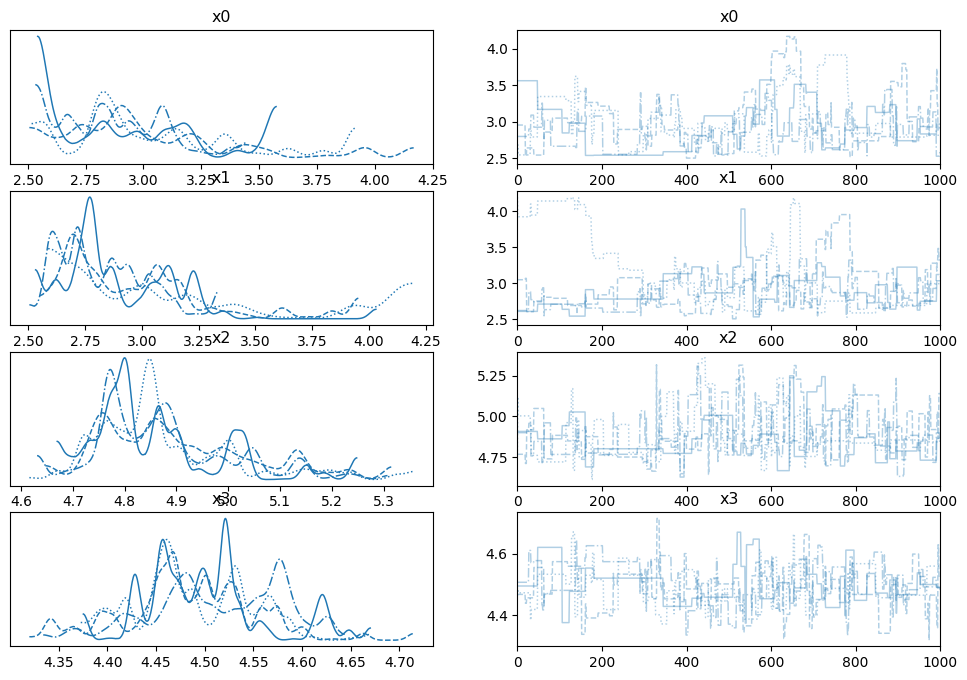

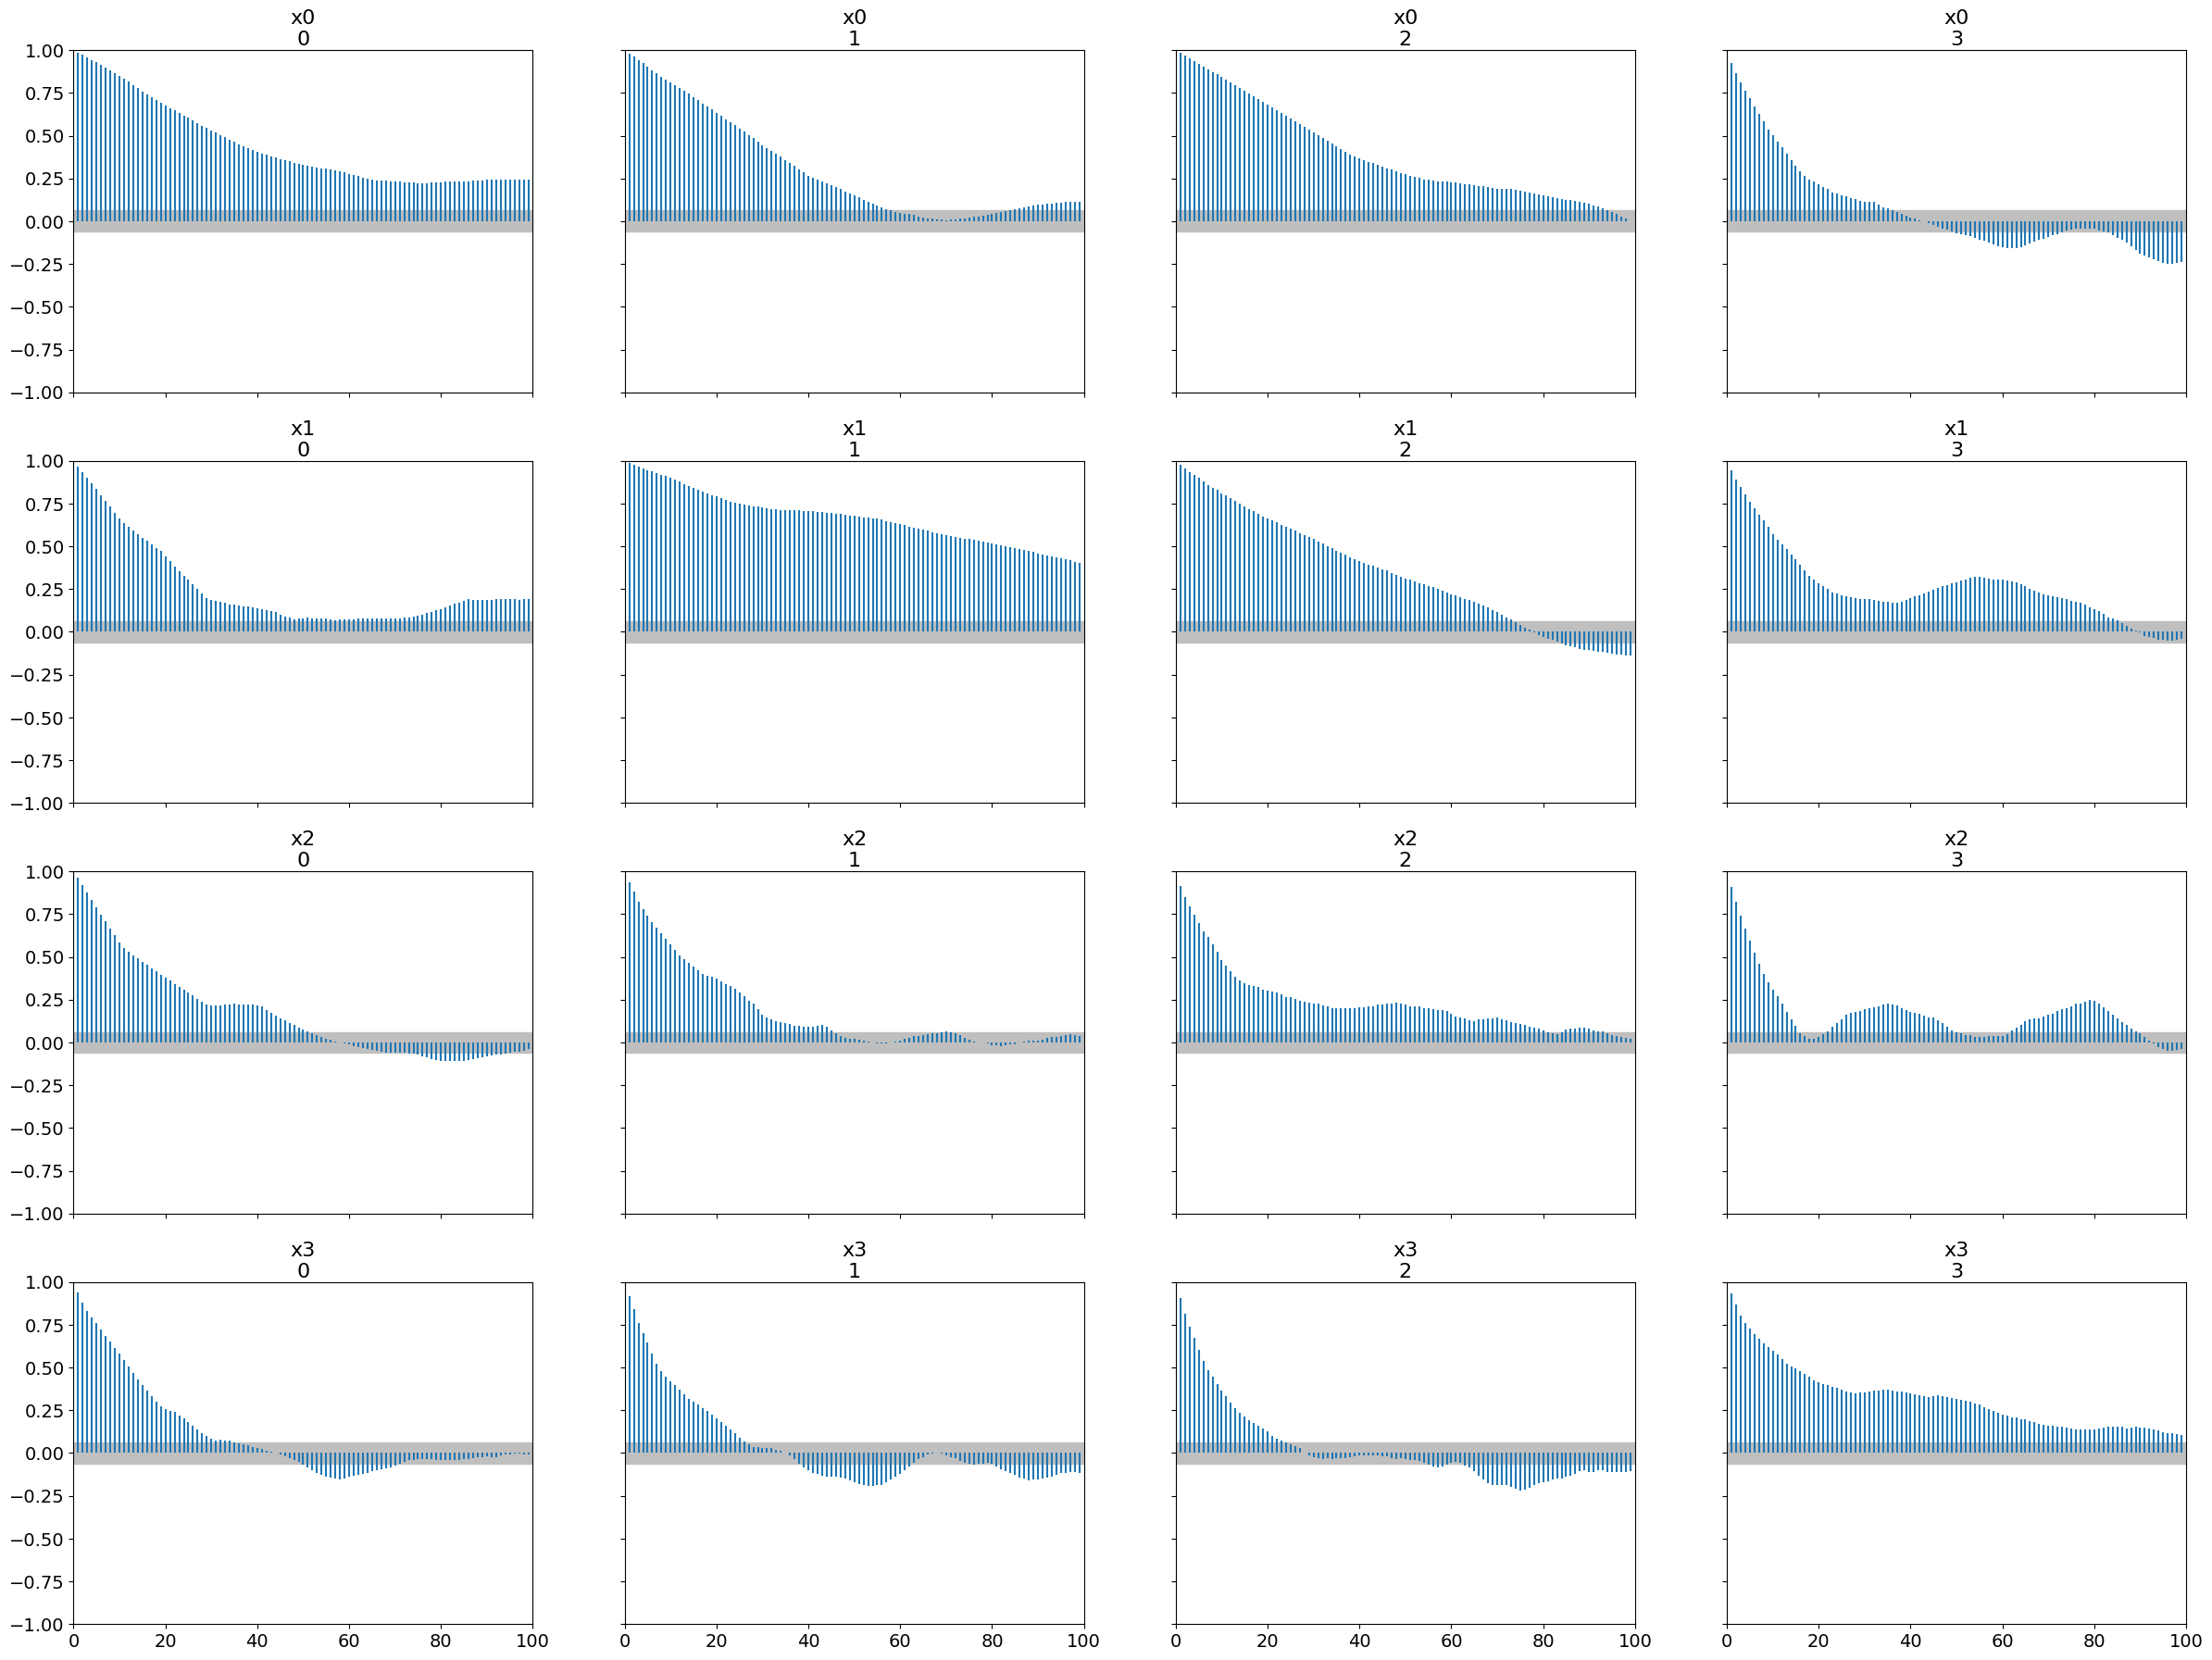

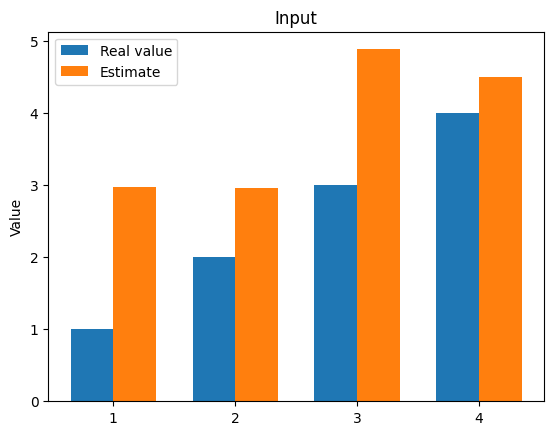

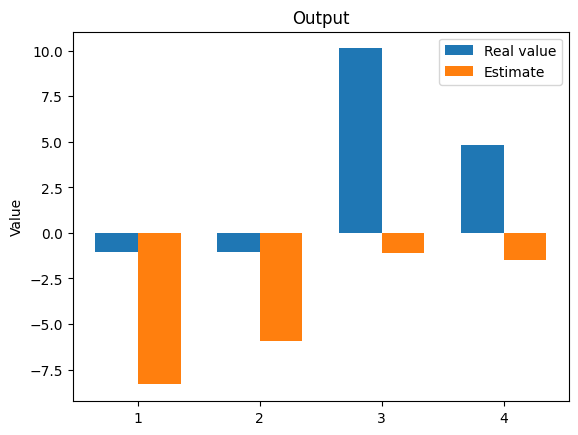

The function inverse took 374.2113416194916 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.39: 100%|██████████| 2000/2000 [01:29<00:00, 22.44it/s]


Sampling chain 2/4


Running chain, α = 0.36: 100%|██████████| 2000/2000 [01:28<00:00, 22.52it/s]


Sampling chain 3/4


Running chain, α = 0.11: 100%|██████████| 2000/2000 [01:29<00:00, 22.25it/s]


Sampling chain 4/4


Running chain, α = 0.18: 100%|██████████| 2000/2000 [01:33<00:00, 21.38it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.63  1.754 2.949 3.406]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.630  0.356   0.945    2.179      0.040    0.028      87.0     181.0   
x1  1.754  0.316   1.195    2.251      0.044    0.031      66.0     207.0   
x2  2.949  0.235   2.549    3.361      0.032    0.023      55.0     239.0   
x3  3.406  0.685   2.340    4.196      0.301    0.226       8.0     161.0   

    r_hat  
x0   1.05  
x1   1.07  
x2   1.07  
x3   1.51  
Autocorrelation...
the difference between estimated values [0.63  0.246 0.051 0.594]
 the difference between outputs of two models are [2.8338805e-01 3.6902022e-01 2.3784637e-03 4.3388615e+00]


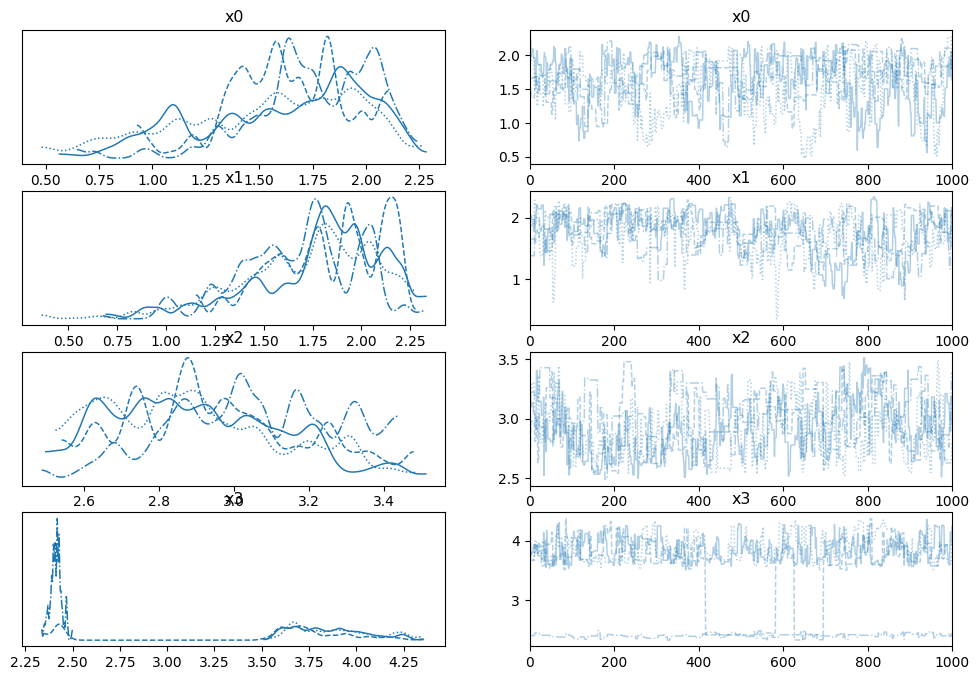

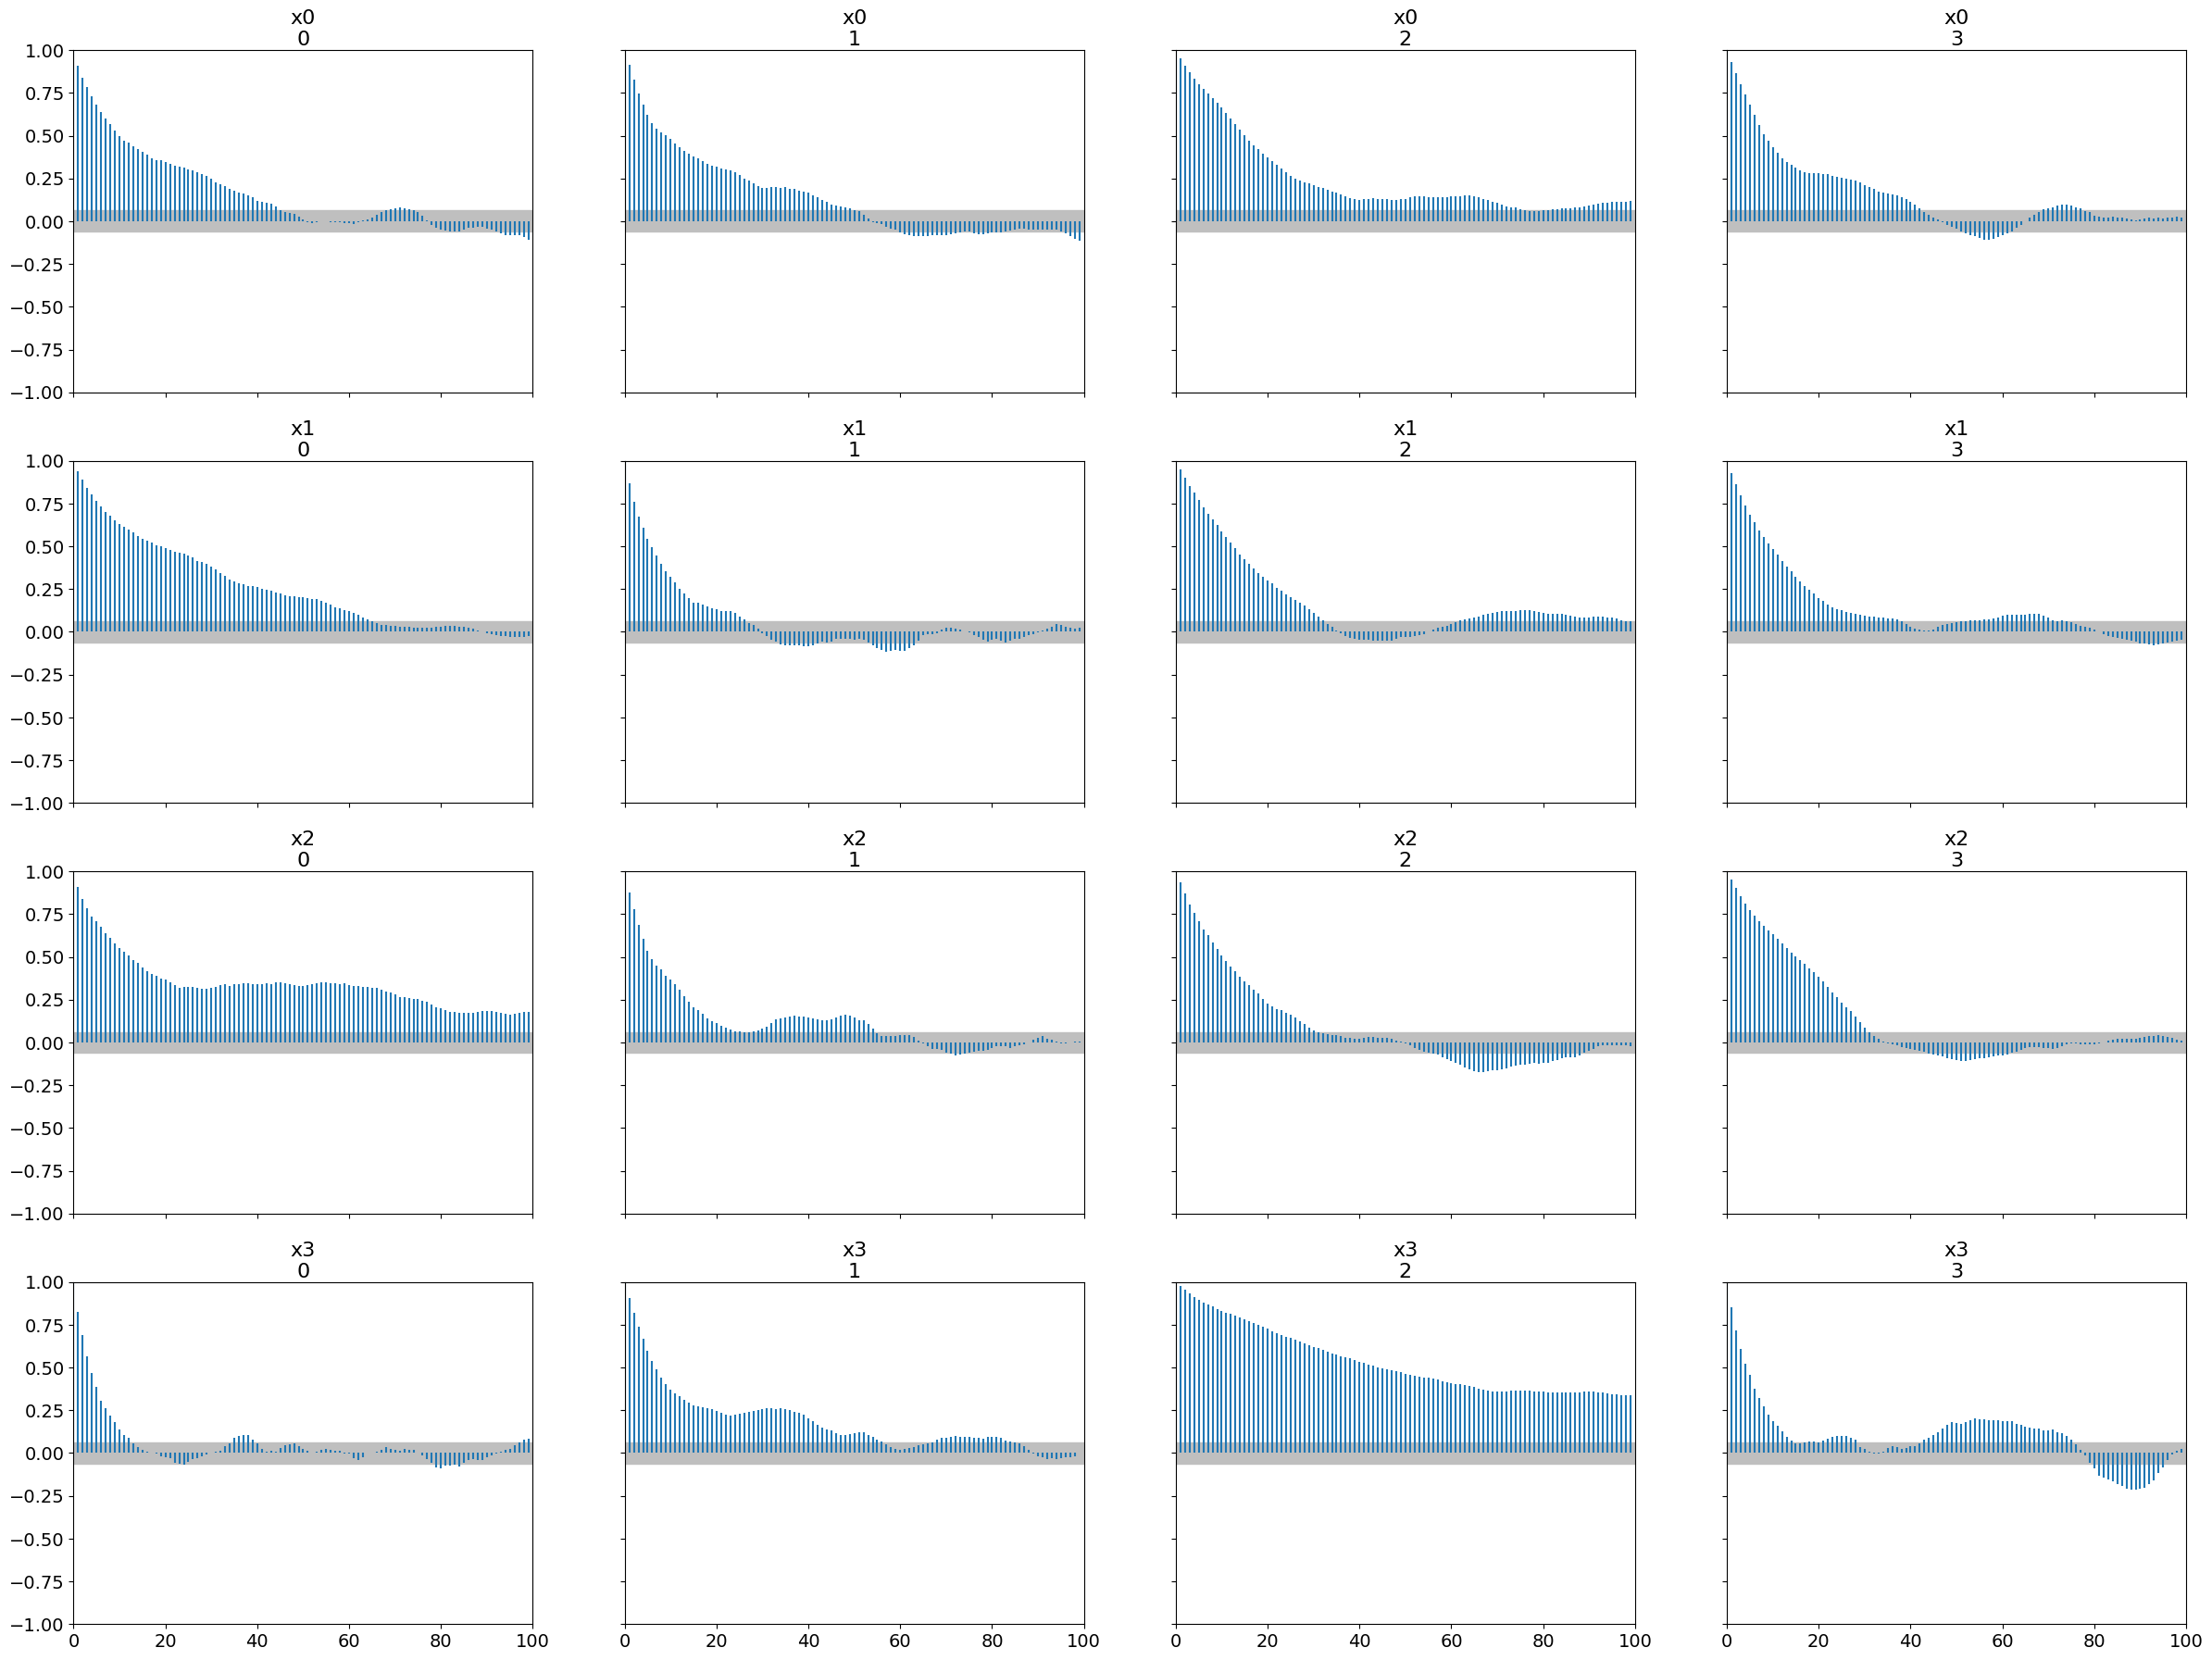

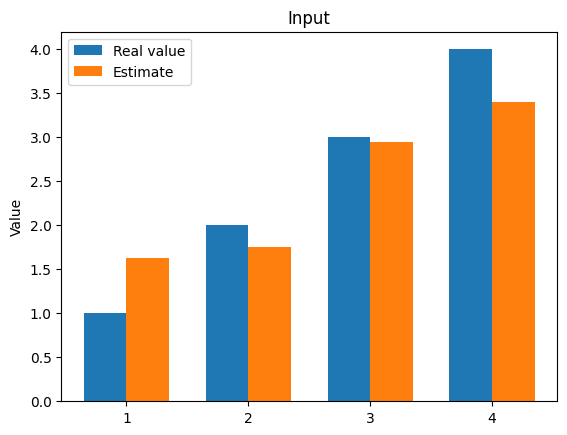

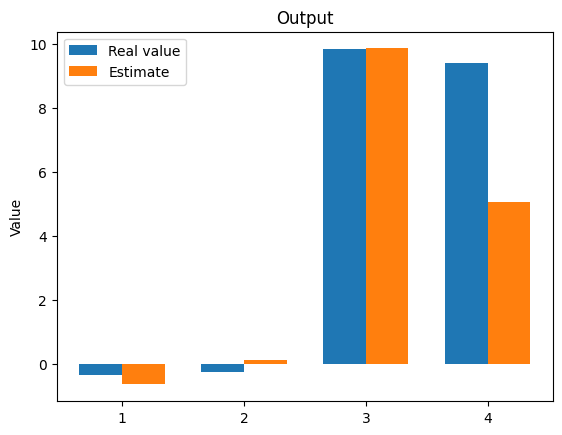

The function inverse took 375.6099154949188 seconds.


In [ ]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.04: 100%|██████████| 2000/2000 [02:53<00:00, 11.52it/s]


Sampling chain 2/4


Running chain, α = 0.10: 100%|██████████| 2000/2000 [03:12<00:00, 10.41it/s]


Sampling chain 3/4


Running chain, α = 0.10: 100%|██████████| 2000/2000 [03:02<00:00, 10.97it/s]


Sampling chain 4/4


Running chain, α = 0.00: 100%|██████████| 2000/2000 [03:00<00:00, 11.07it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.957 1.981 2.945 2.472]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.957  0.349   1.347    2.460      0.133    0.099       9.0      39.0   
x1  1.981  0.330   1.436    2.441      0.132    0.098       7.0      12.0   
x2  2.945  0.216   2.521    3.180      0.066    0.048      13.0      17.0   
x3  2.472  0.016   2.460    2.489      0.001    0.001     194.0     157.0   

    r_hat  
x0   1.42  
x1   1.57  
x2   1.23  
x3   1.05  
Autocorrelation...
the difference between estimated values [0.957 0.019 0.055 1.528]
 the difference between outputs of two models are [0.68929386 0.03002322 0.40847492 1.02358103]


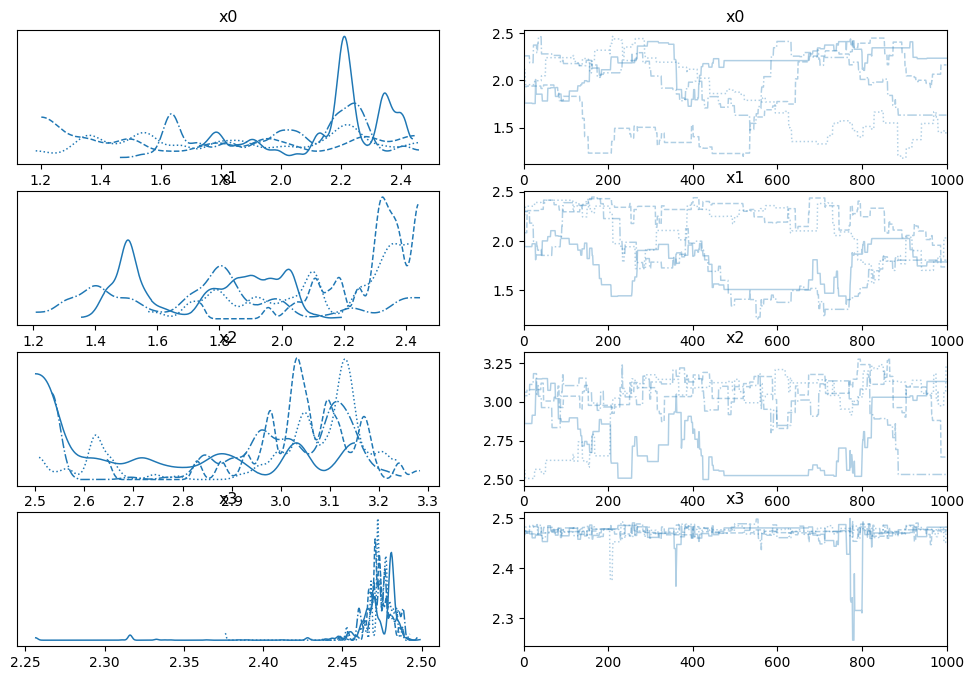

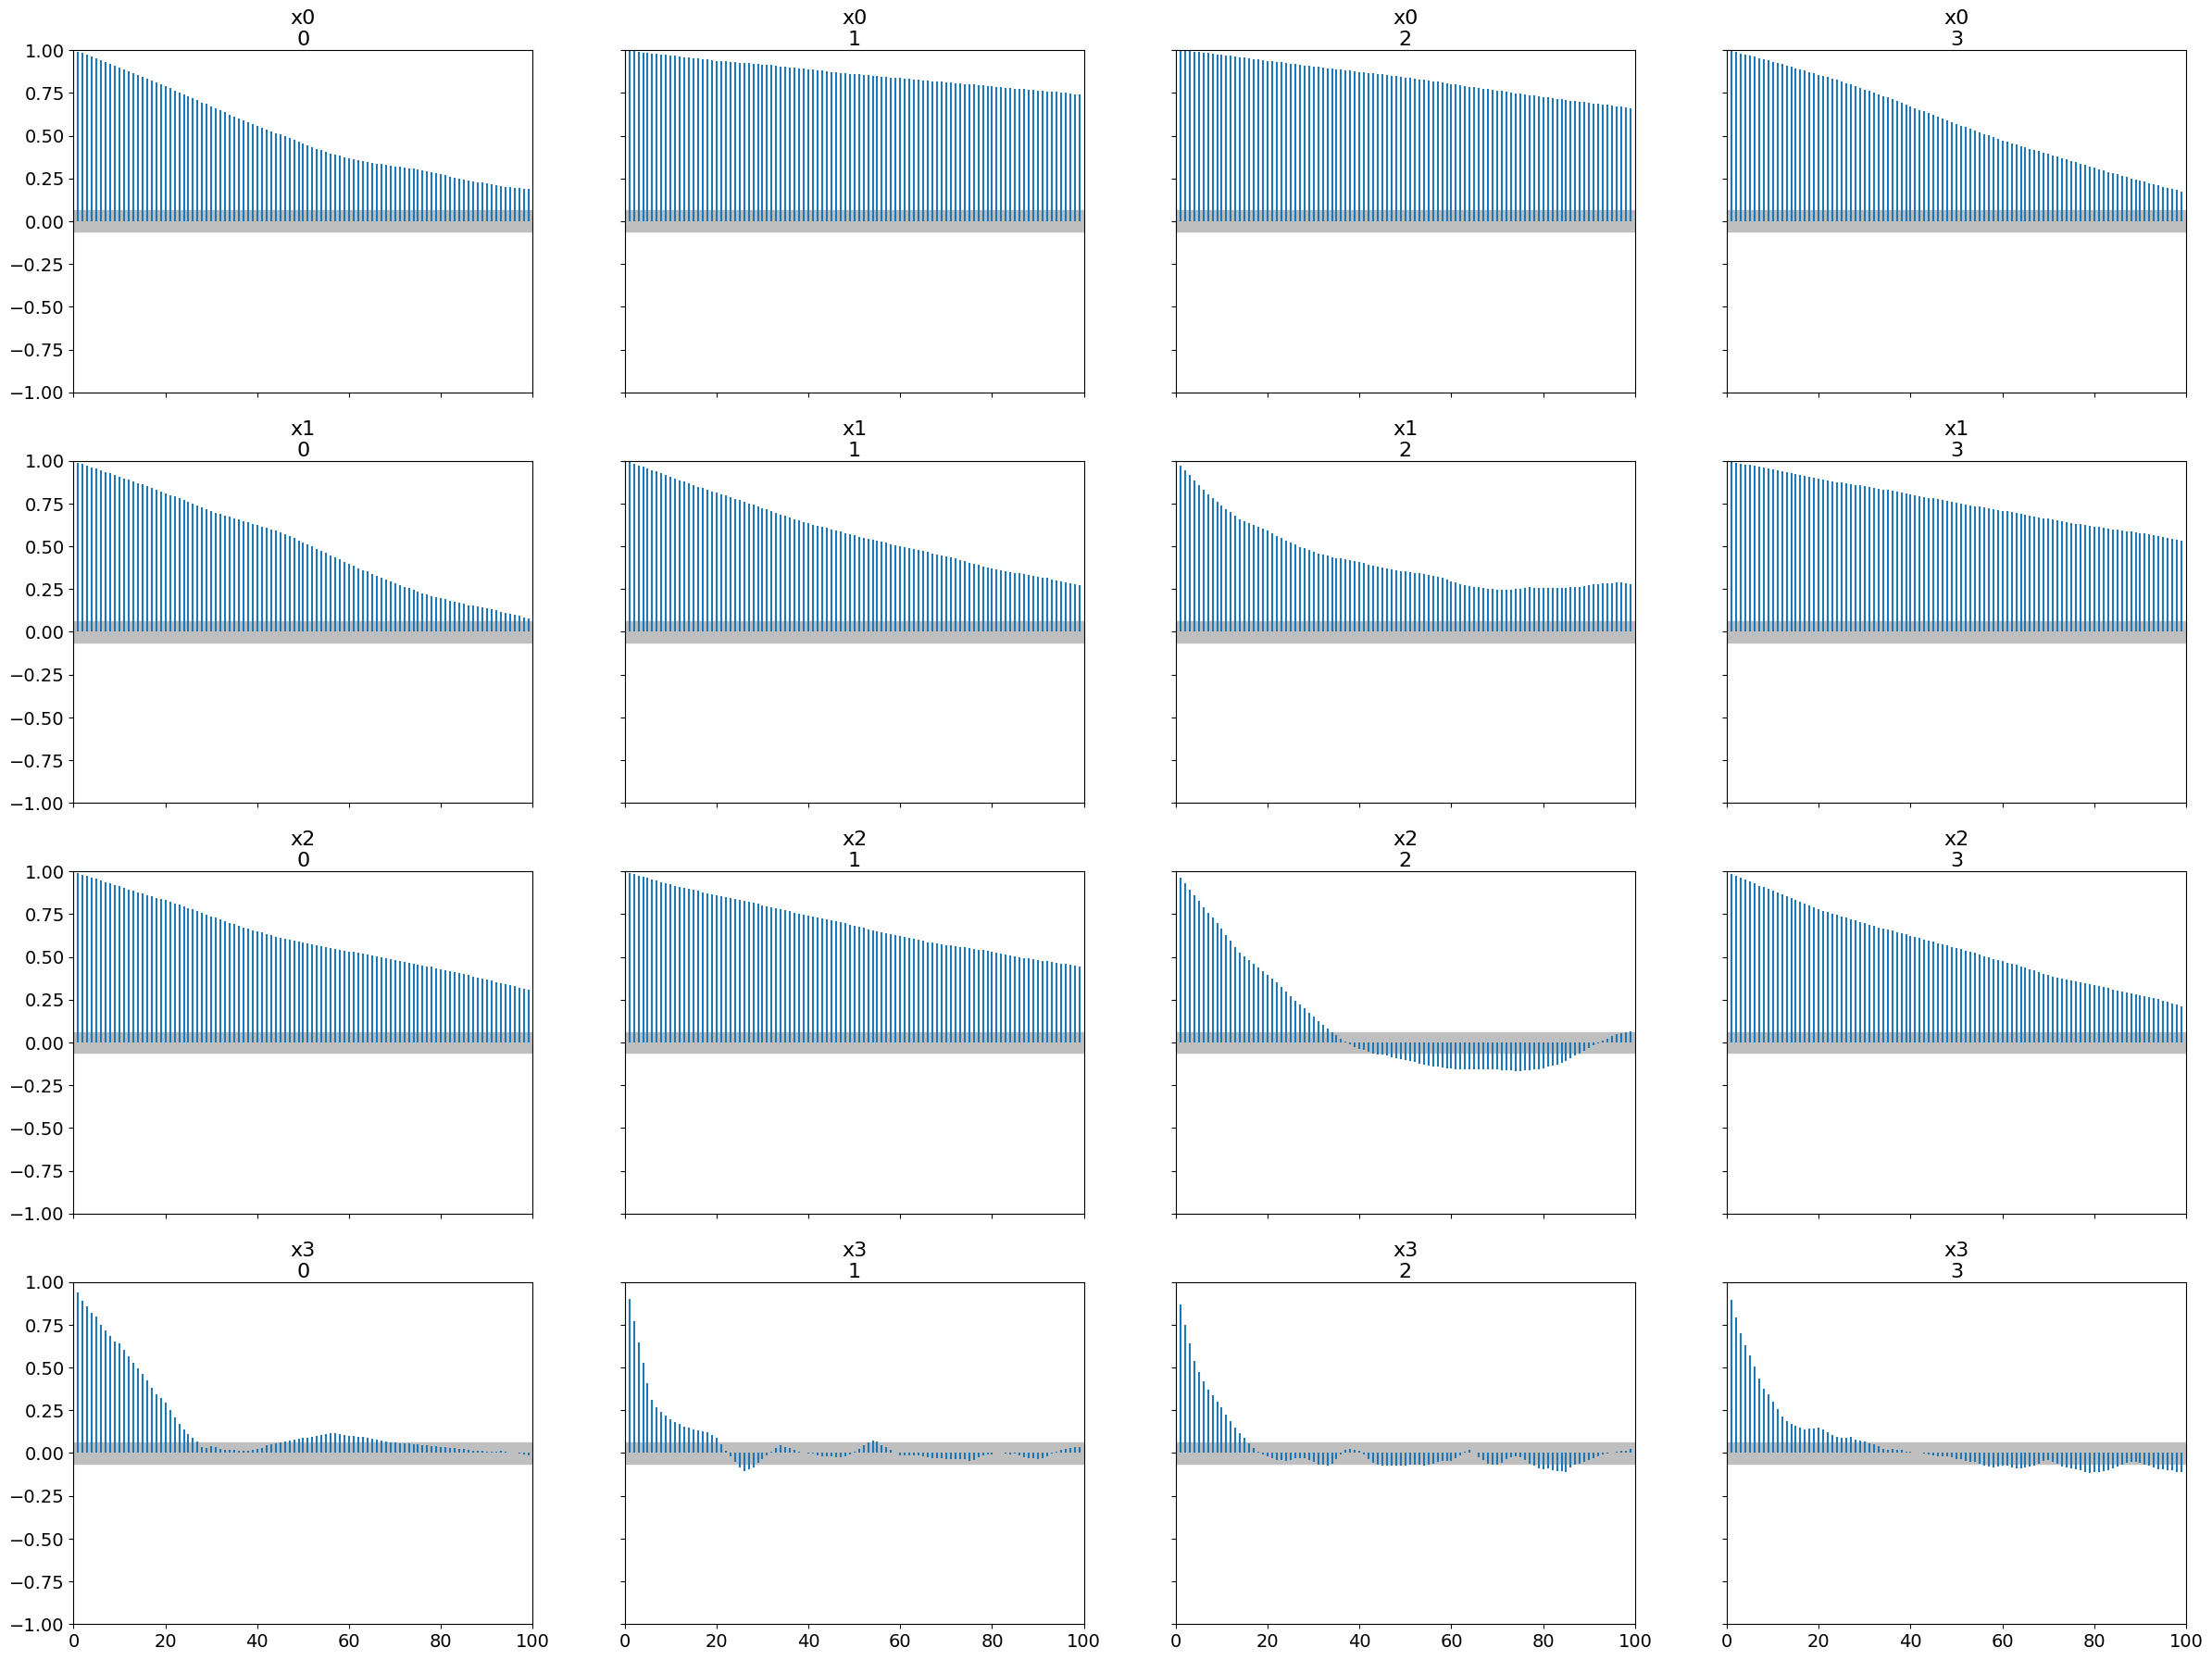

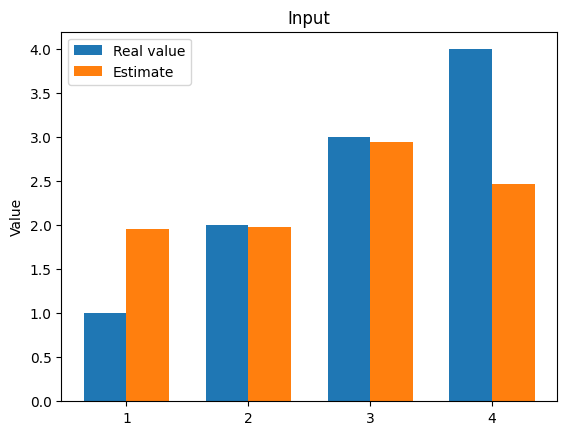

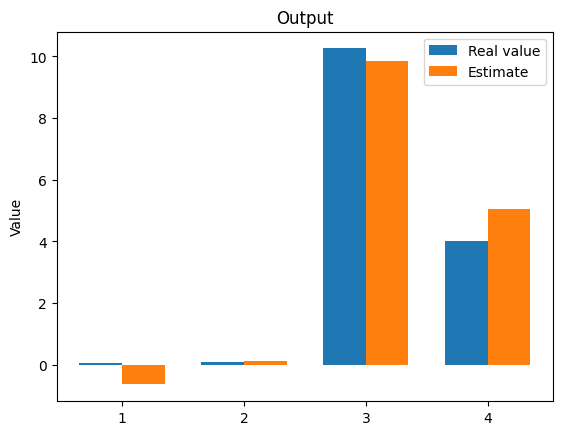

The function inverse took 732.5357847213745 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.49: 100%|██████████| 2000/2000 [01:33<00:00, 21.39it/s]


Sampling chain 2/4


Running chain, α = 0.39: 100%|██████████| 2000/2000 [01:29<00:00, 22.27it/s]


Sampling chain 3/4


Running chain, α = 0.59: 100%|██████████| 2000/2000 [01:28<00:00, 22.67it/s]


Sampling chain 4/4


Running chain, α = 0.50: 100%|██████████| 2000/2000 [01:27<00:00, 22.92it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.873 2.969 2.855 2.857]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.873  0.208   2.535    3.232      0.037    0.027      35.0     114.0   
x1  2.969  0.345   2.511    3.524      0.064    0.047      66.0      28.0   
x2  2.855  0.101   2.647    3.034      0.005    0.004     370.0     547.0   
x3  2.857  0.123   2.625    3.086      0.008    0.005     254.0     654.0   

    r_hat  
x0   1.09  
x1   1.06  
x2   1.02  
x3   1.01  
Autocorrelation...
the difference between estimated values [1.873 0.969 0.145 1.143]
 the difference between outputs of two models are [7.3249664  4.8988614  0.08246225 0.4749769 ]


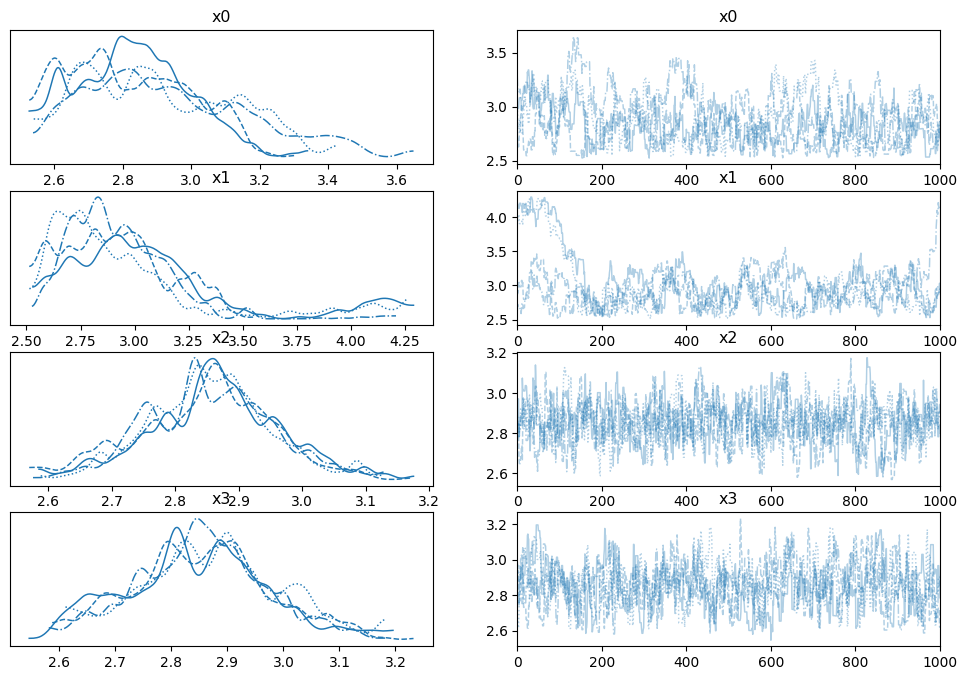

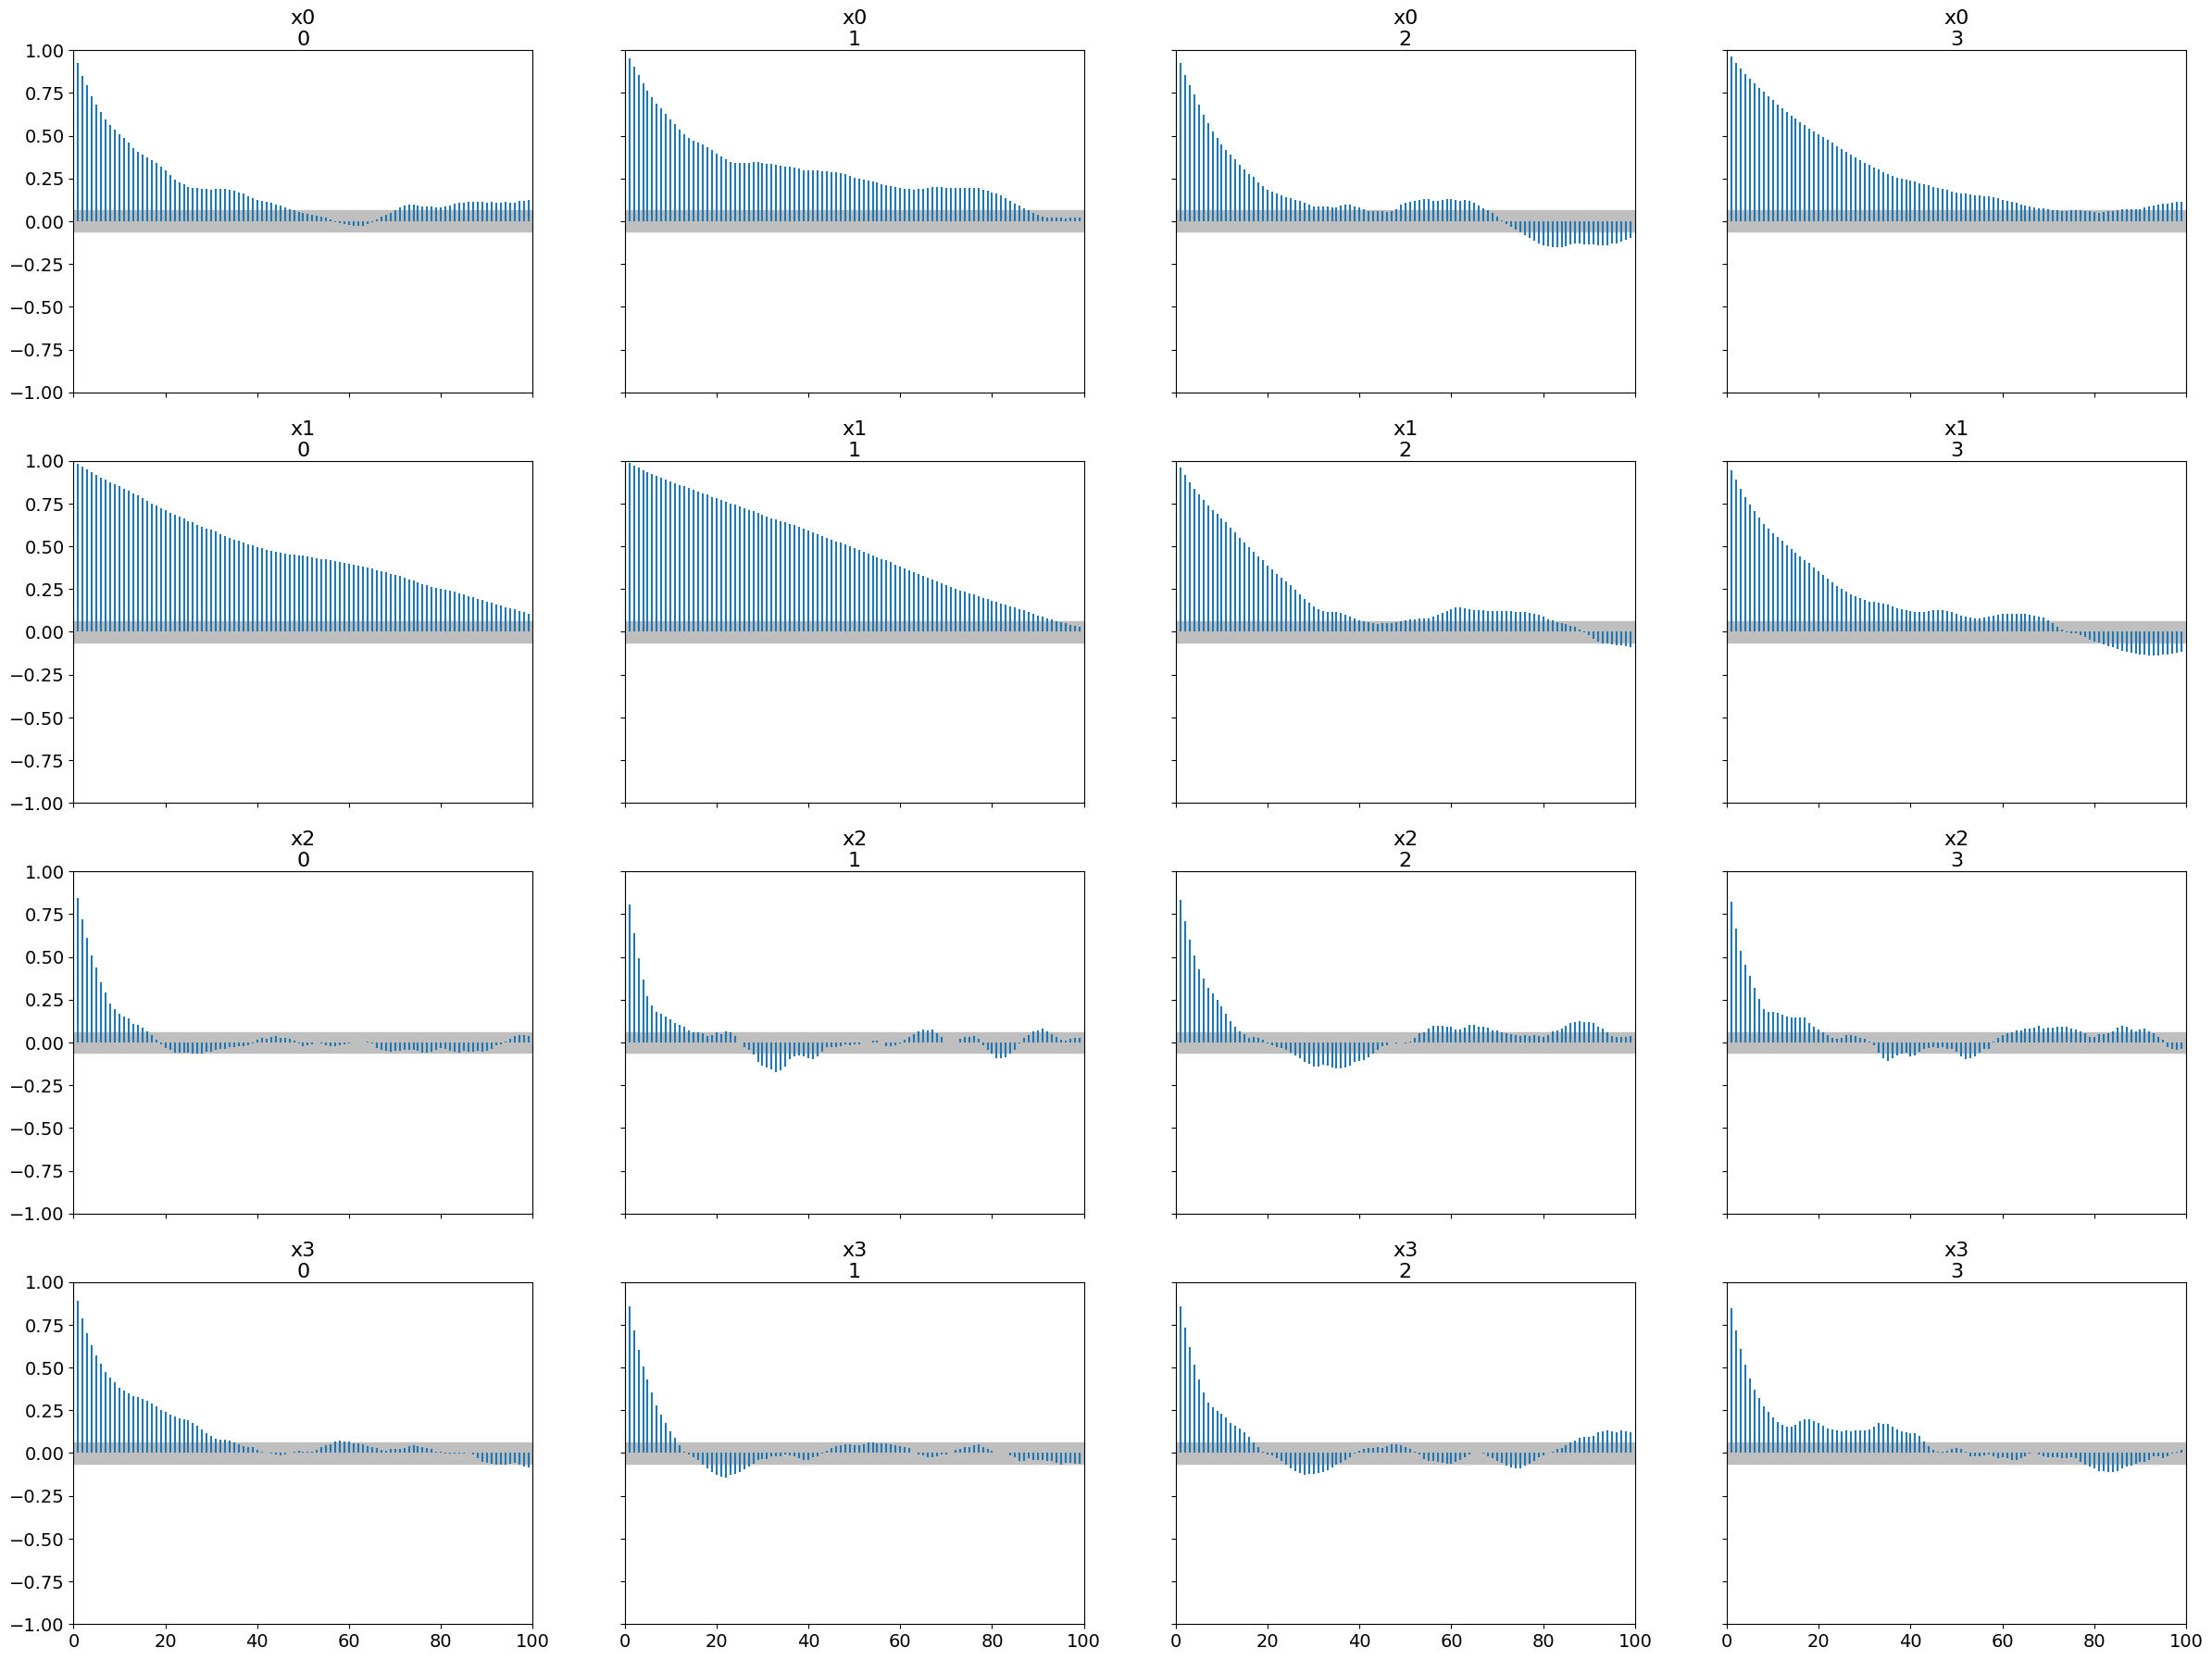

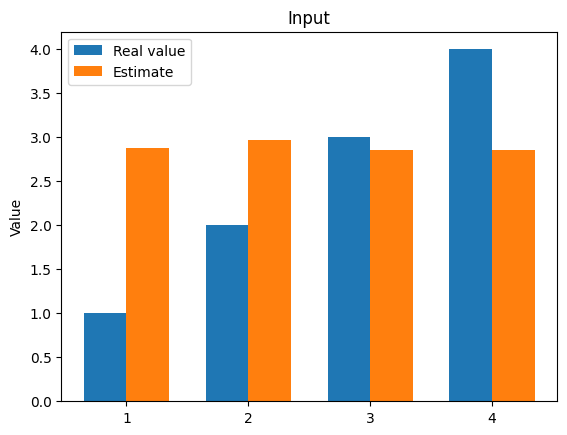

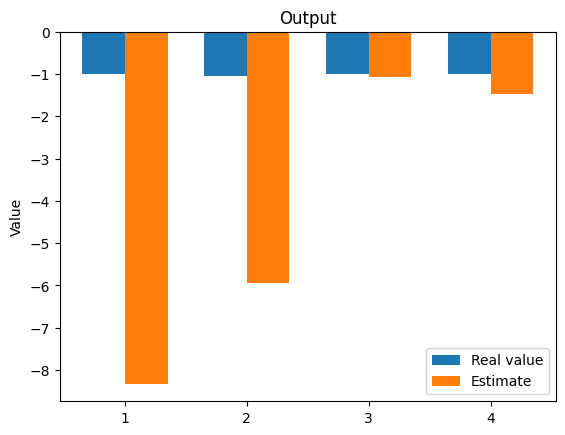

The function inverse took 375.6751160621643 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.27: 100%|██████████| 2000/2000 [01:27<00:00, 22.85it/s]


Sampling chain 2/4


Running chain, α = 0.26: 100%|██████████| 2000/2000 [01:27<00:00, 22.95it/s]


Sampling chain 3/4


Running chain, α = 0.38: 100%|██████████| 2000/2000 [01:26<00:00, 23.00it/s]


Sampling chain 4/4


Running chain, α = 0.42: 100%|██████████| 2000/2000 [01:27<00:00, 22.92it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.614 1.637 2.919 2.363]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.614  0.386   0.827    2.212      0.151    0.112       8.0      13.0   
x1  1.637  0.473   0.716    2.239      0.184    0.136       8.0      14.0   
x2  2.919  0.293   2.508    3.433      0.047    0.034      55.0     171.0   
x3  2.363  0.039   2.289    2.431      0.002    0.001     615.0     792.0   

    r_hat  
x0   1.48  
x1   1.41  
x2   1.11  
x3   1.00  
Autocorrelation...
the difference between estimated values [0.614 0.363 0.081 1.637]
 the difference between outputs of two models are [0.2724034  0.46617365 0.00465584 1.2159557 ]


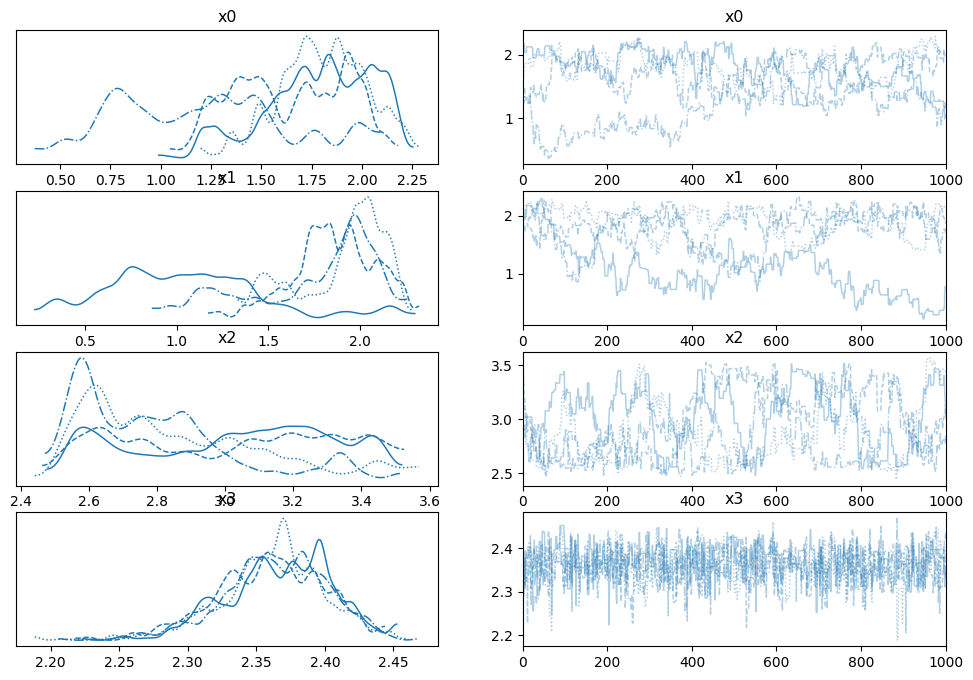

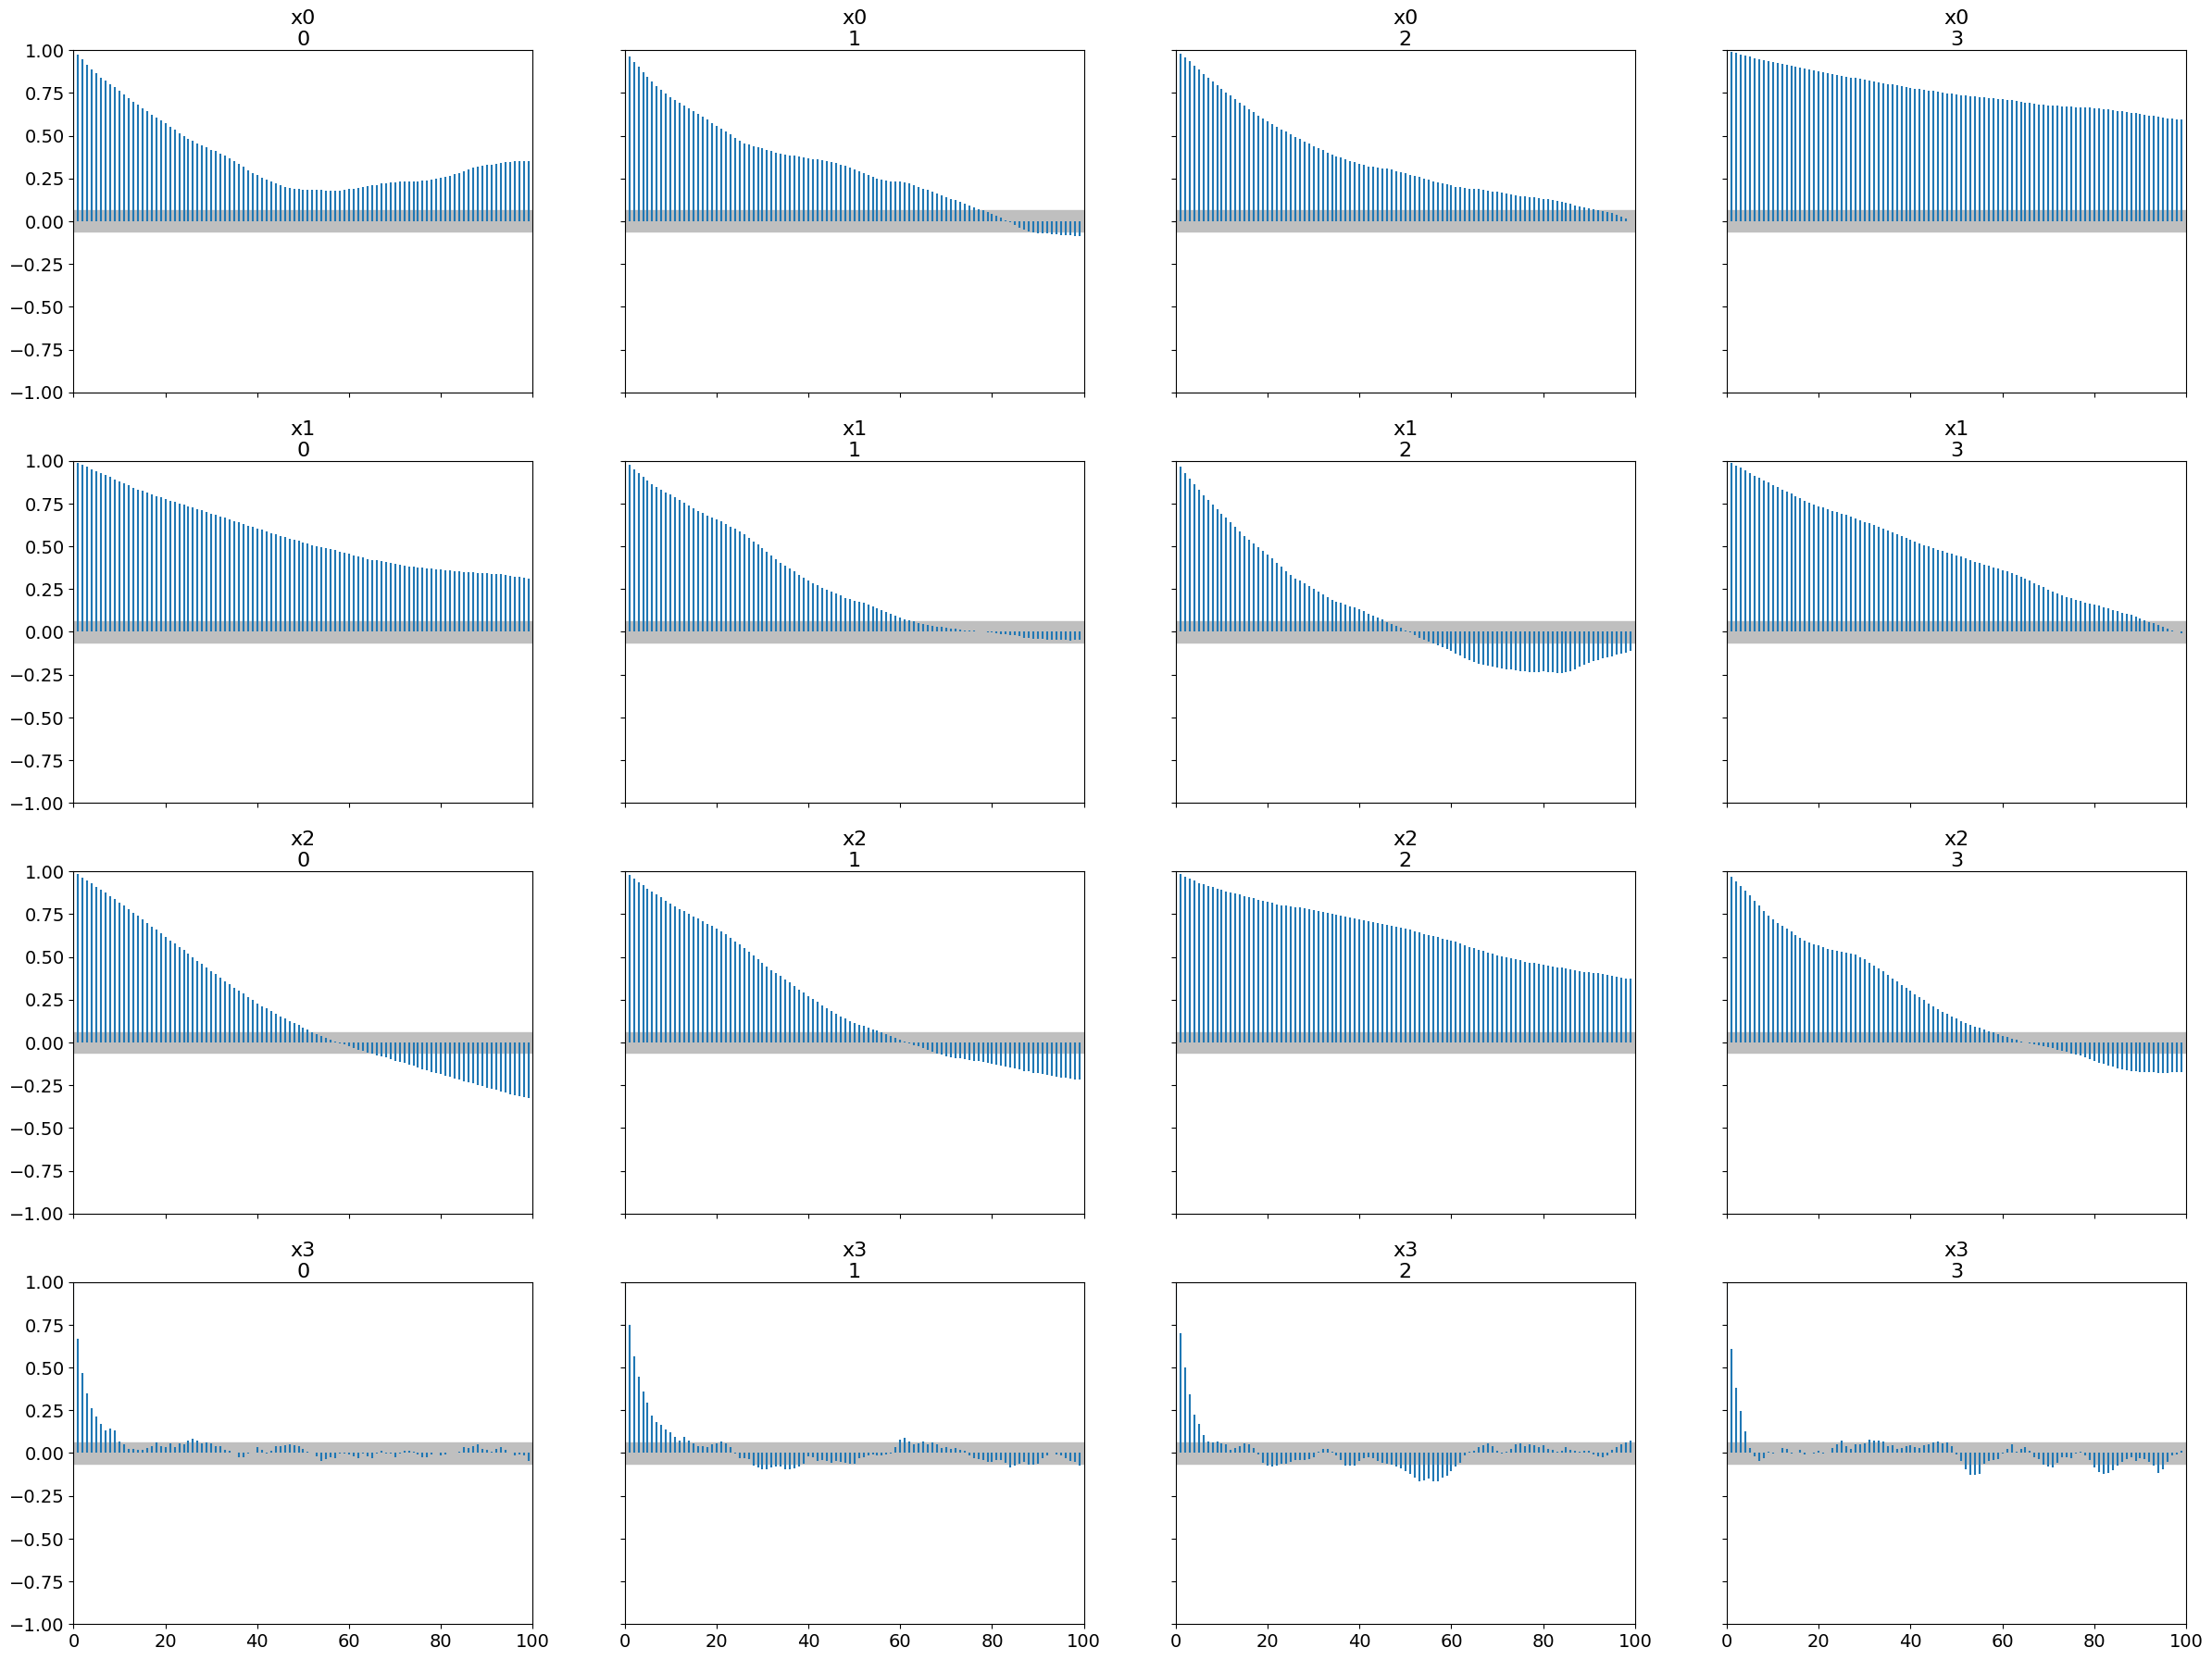

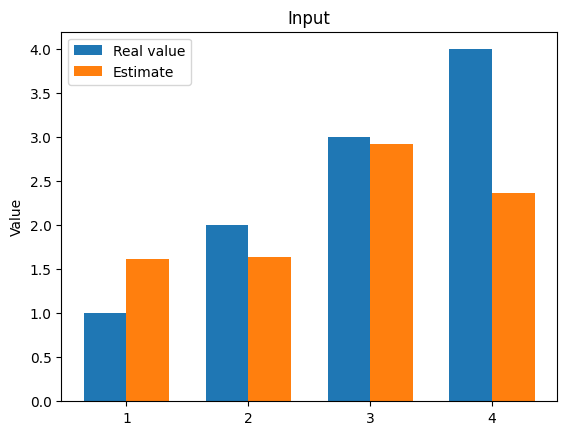

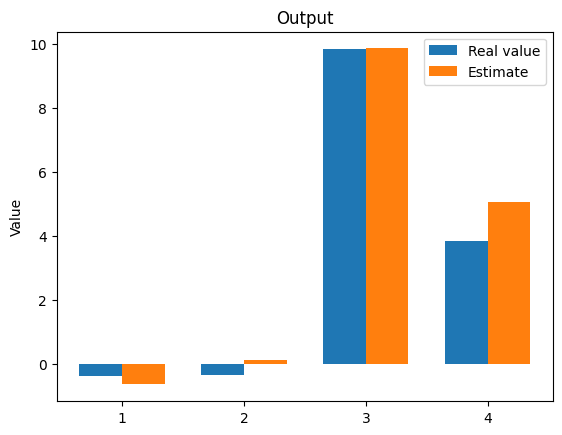

The function inverse took 358.823059797287 seconds.


In [ ]:
estimate_MF2=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="MH")
estimate_LF2=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="MH")
estimate_HF2=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="MH")

real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.25: 100%|██████████| 4000/4000 [05:31<00:00, 12.08it/s]


Sampling chain 2/8


Running chain, α = 0.37: 100%|██████████| 4000/4000 [05:31<00:00, 12.08it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.21: 100%|██████████| 4000/4000 [05:31<00:00, 12.07it/s]


Sampling chain 8/8


Running chain, α = 0.28: 100%|██████████| 4000/4000 [05:31<00:00, 12.08it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.447 1.819 2.799 3.368]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.447  0.409   0.772    2.189      0.015    0.010     774.0    1161.0   
x1  1.819  0.343   1.244    2.411      0.013    0.009     750.0     600.0   
x2  2.799  0.169   2.526    3.030      0.006    0.005     702.0     668.0   
x3  3.368  0.256   3.268    4.058      0.034    0.024      89.0      46.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.07  
Autocorrelation...
the difference between estimated values [0.447 0.181 0.201 0.632]
 the difference between outputs of two models are [0.43621564 0.19550598 0.99418545 0.40142393]


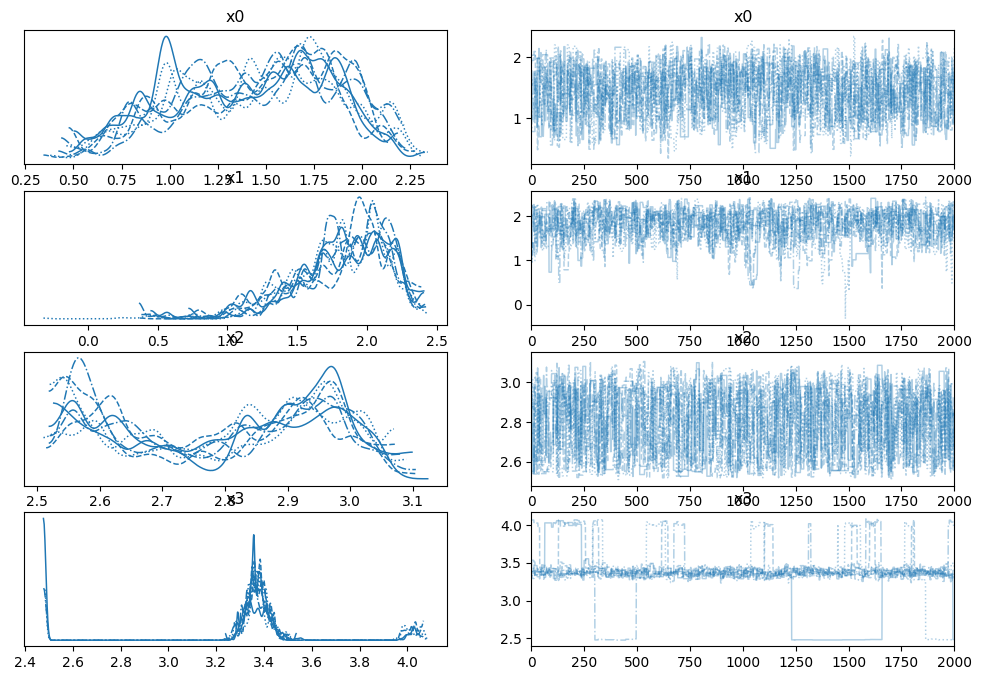

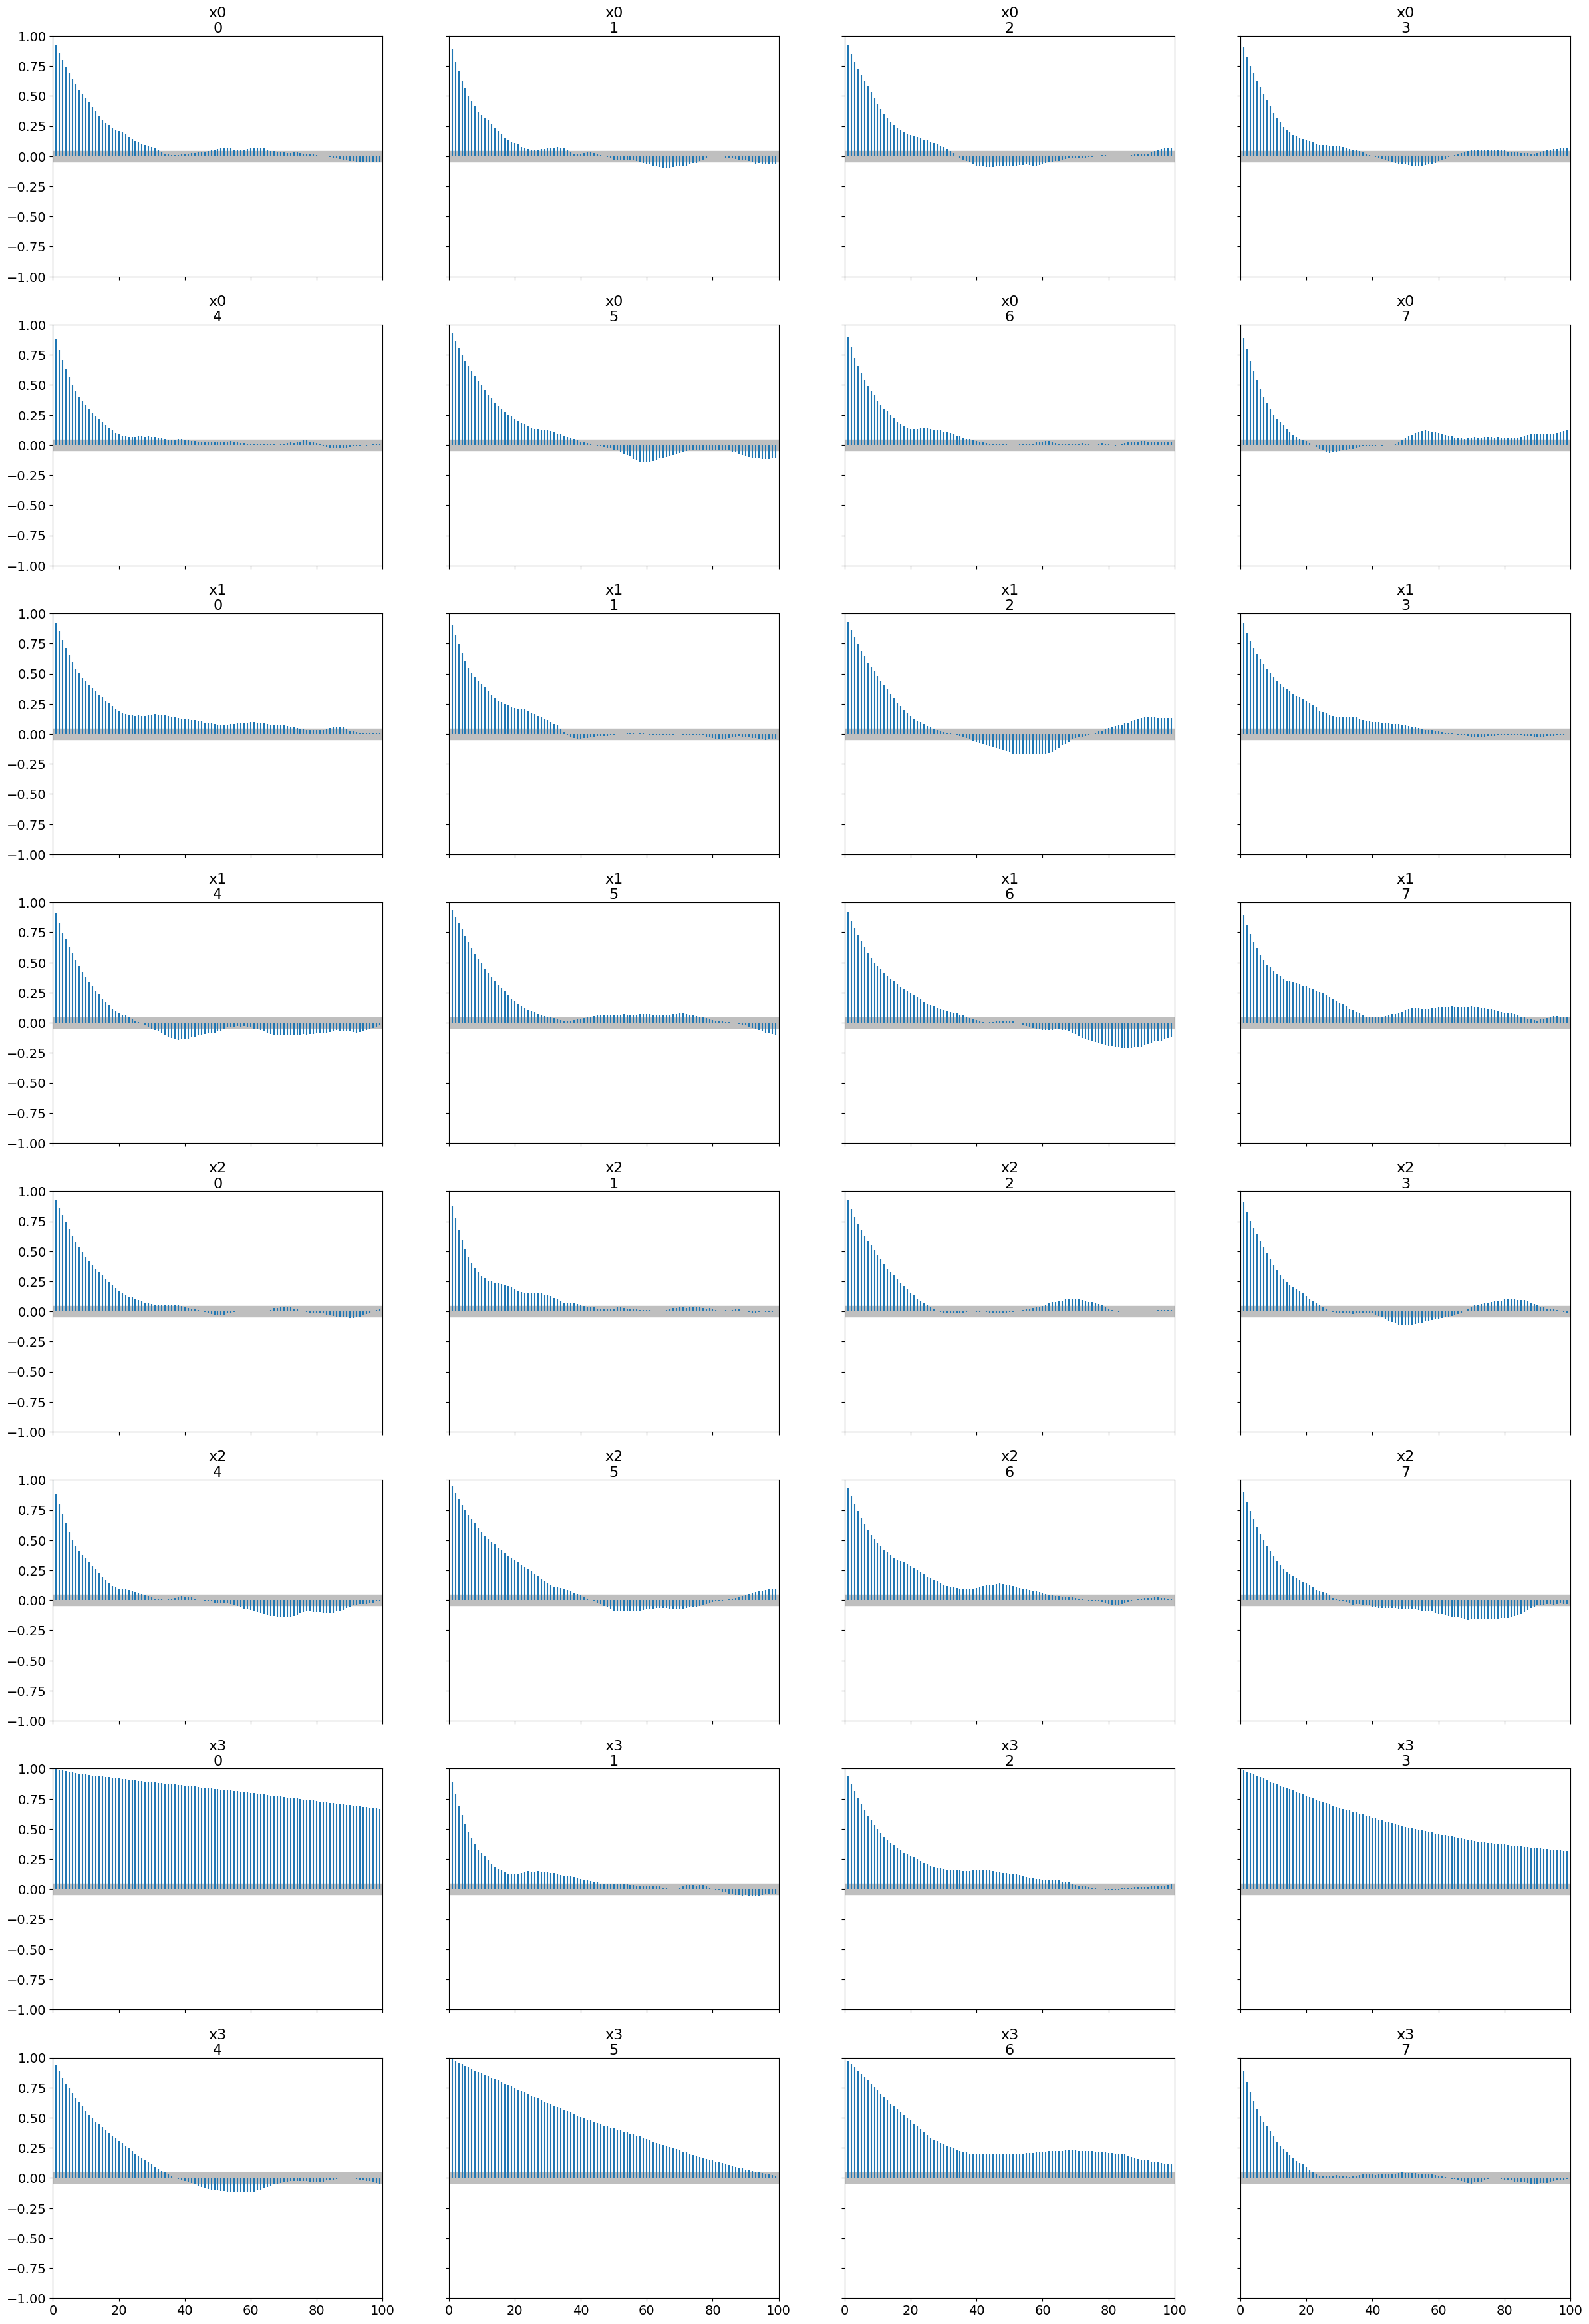

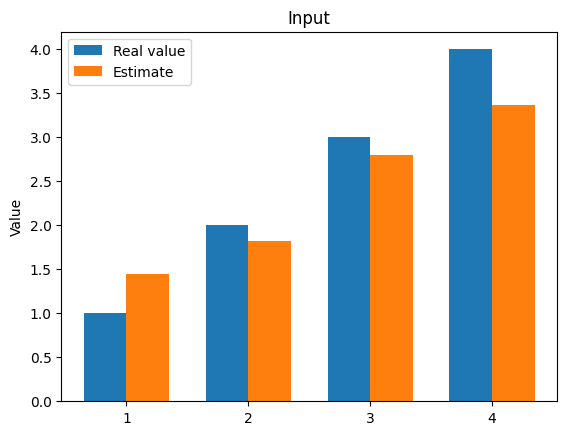

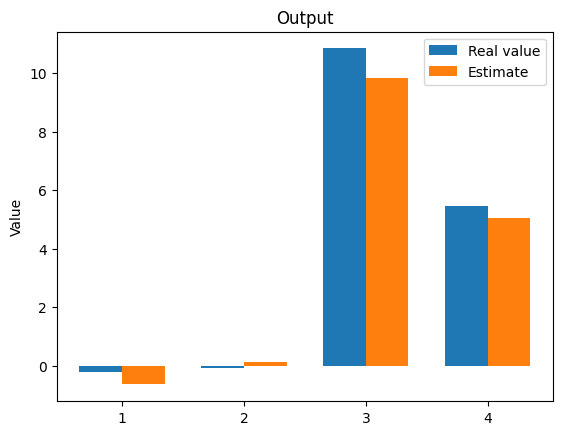

The function inverse took 2680.3795199394226 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.56: 100%|██████████| 4000/4000 [02:50<00:00, 23.47it/s]


Sampling chain 2/8


Running chain, α = 0.56: 100%|██████████| 4000/4000 [02:50<00:00, 23.50it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.68: 100%|██████████| 4000/4000 [02:49<00:00, 23.55it/s]


Sampling chain 8/8


Running chain, α = 0.58: 100%|██████████| 4000/4000 [02:49<00:00, 23.54it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.88  2.851 2.863 2.861]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.880  0.196   2.541    3.213      0.024    0.017      70.0     276.0   
x1  2.851  0.161   2.559    3.120      0.011    0.008     221.0     377.0   
x2  2.863  0.056   2.759    2.968      0.002    0.001    1292.0    1860.0   
x3  2.861  0.073   2.725    3.003      0.002    0.002     917.0    1725.0   

    r_hat  
x0   1.08  
x1   1.03  
x2   1.01  
x3   1.01  
Autocorrelation...
the difference between estimated values [1.88  0.851 0.137 1.139]
 the difference between outputs of two models are [7.3241043  4.9486856  0.08290827 0.4751997 ]


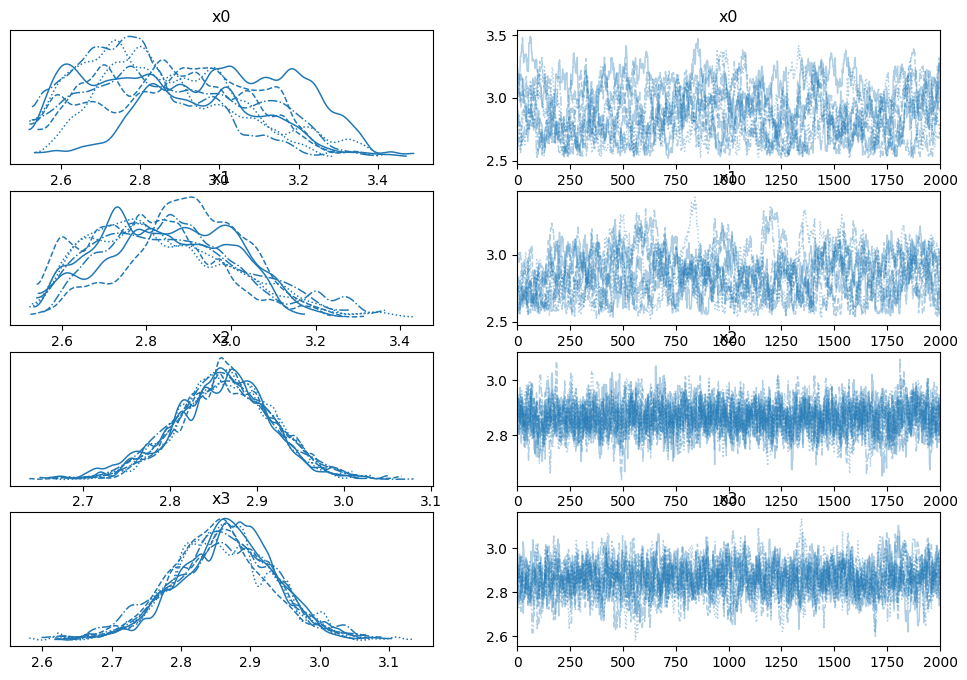

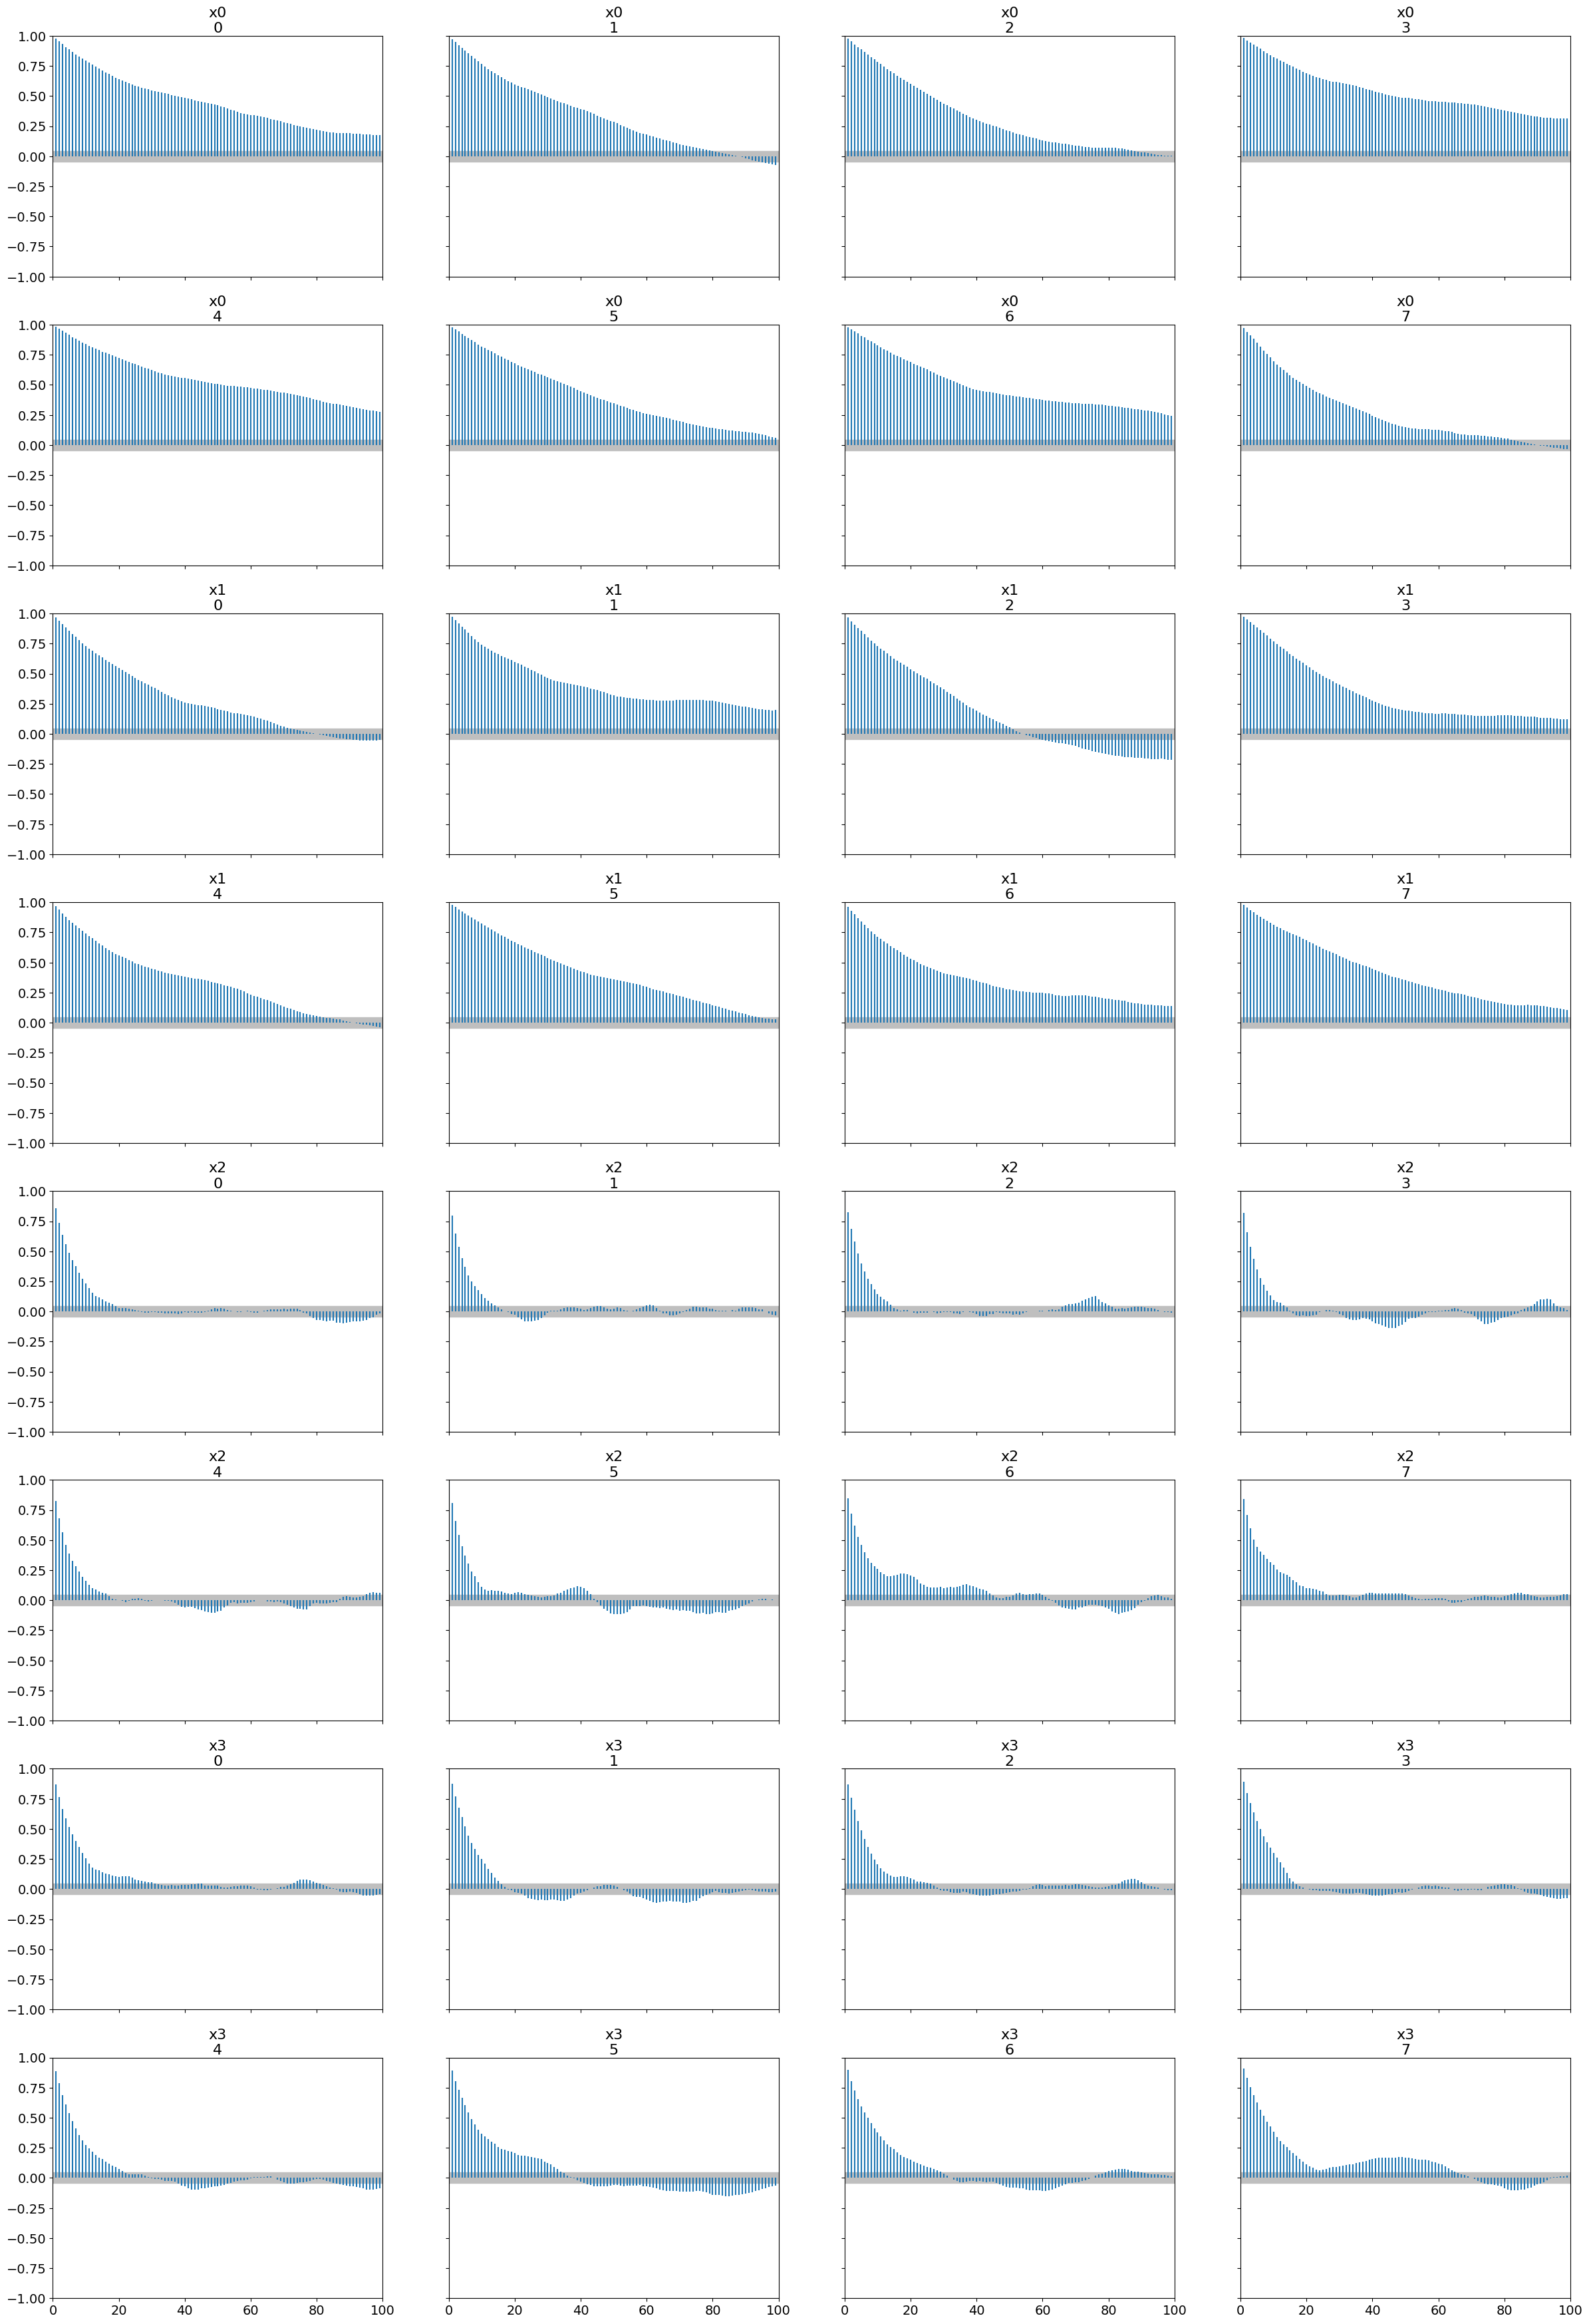

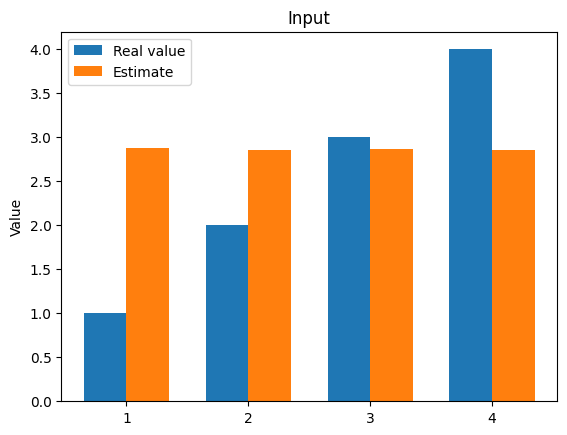

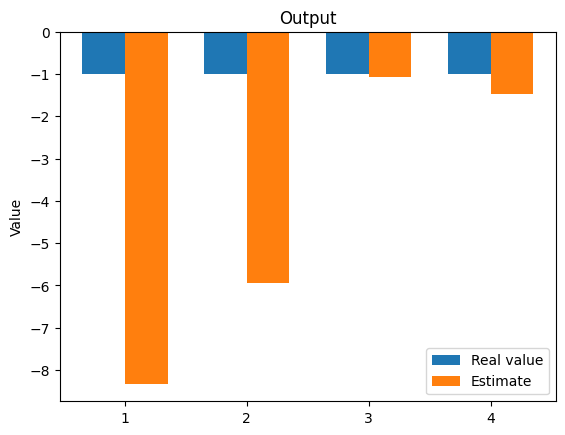

The function inverse took 1364.3051435947418 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.79: 100%|██████████| 4000/4000 [02:49<00:00, 23.54it/s]


Sampling chain 2/8


Running chain, α = 0.49: 100%|██████████| 4000/4000 [02:49<00:00, 23.55it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.66: 100%|██████████| 4000/4000 [02:49<00:00, 23.54it/s]


Sampling chain 8/8


Running chain, α = 0.63: 100%|██████████| 4000/4000 [02:50<00:00, 23.53it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [3.921 3.605 2.564 3.826]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.921  0.128   3.714    4.160      0.006    0.005     423.0     869.0   
x1  3.605  0.821   1.443    4.227      0.283    0.207      20.0      22.0   
x2  2.564  1.034  -0.079    3.460      0.353    0.258      17.0      24.0   
x3  3.826  0.210   3.551    4.243      0.018    0.012     164.0     360.0   

    r_hat  
x0   1.01  
x1   1.32  
x2   1.42  
x3   1.05  
Autocorrelation...
the difference between estimated values [2.921 1.605 0.436 0.174]
 the difference between outputs of two models are [5.6897993e+00 5.6572490e+00 8.9697838e-01 4.4274330e-03]


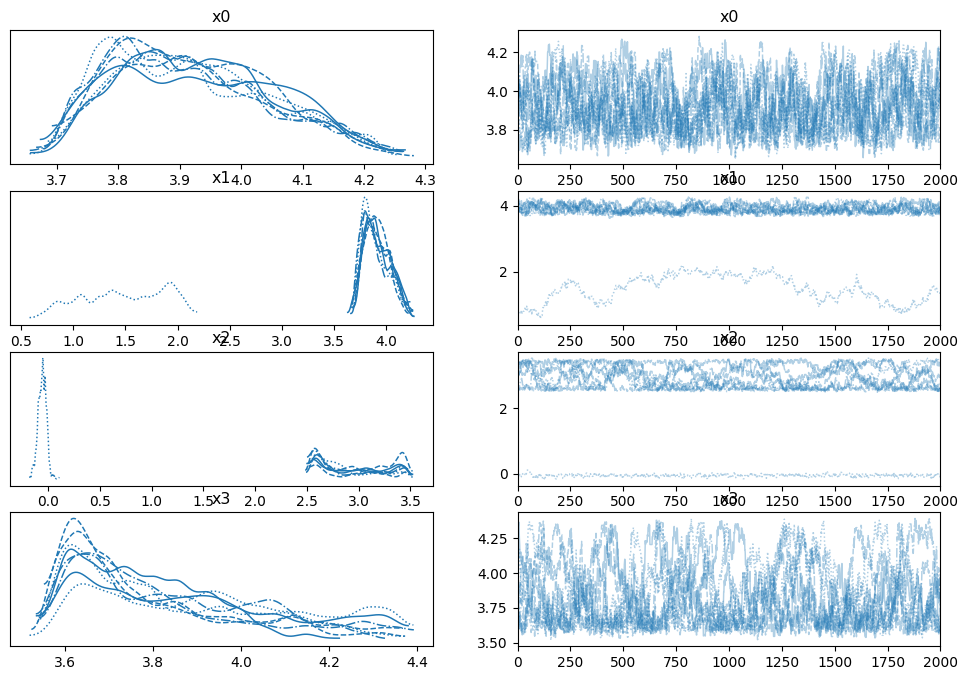

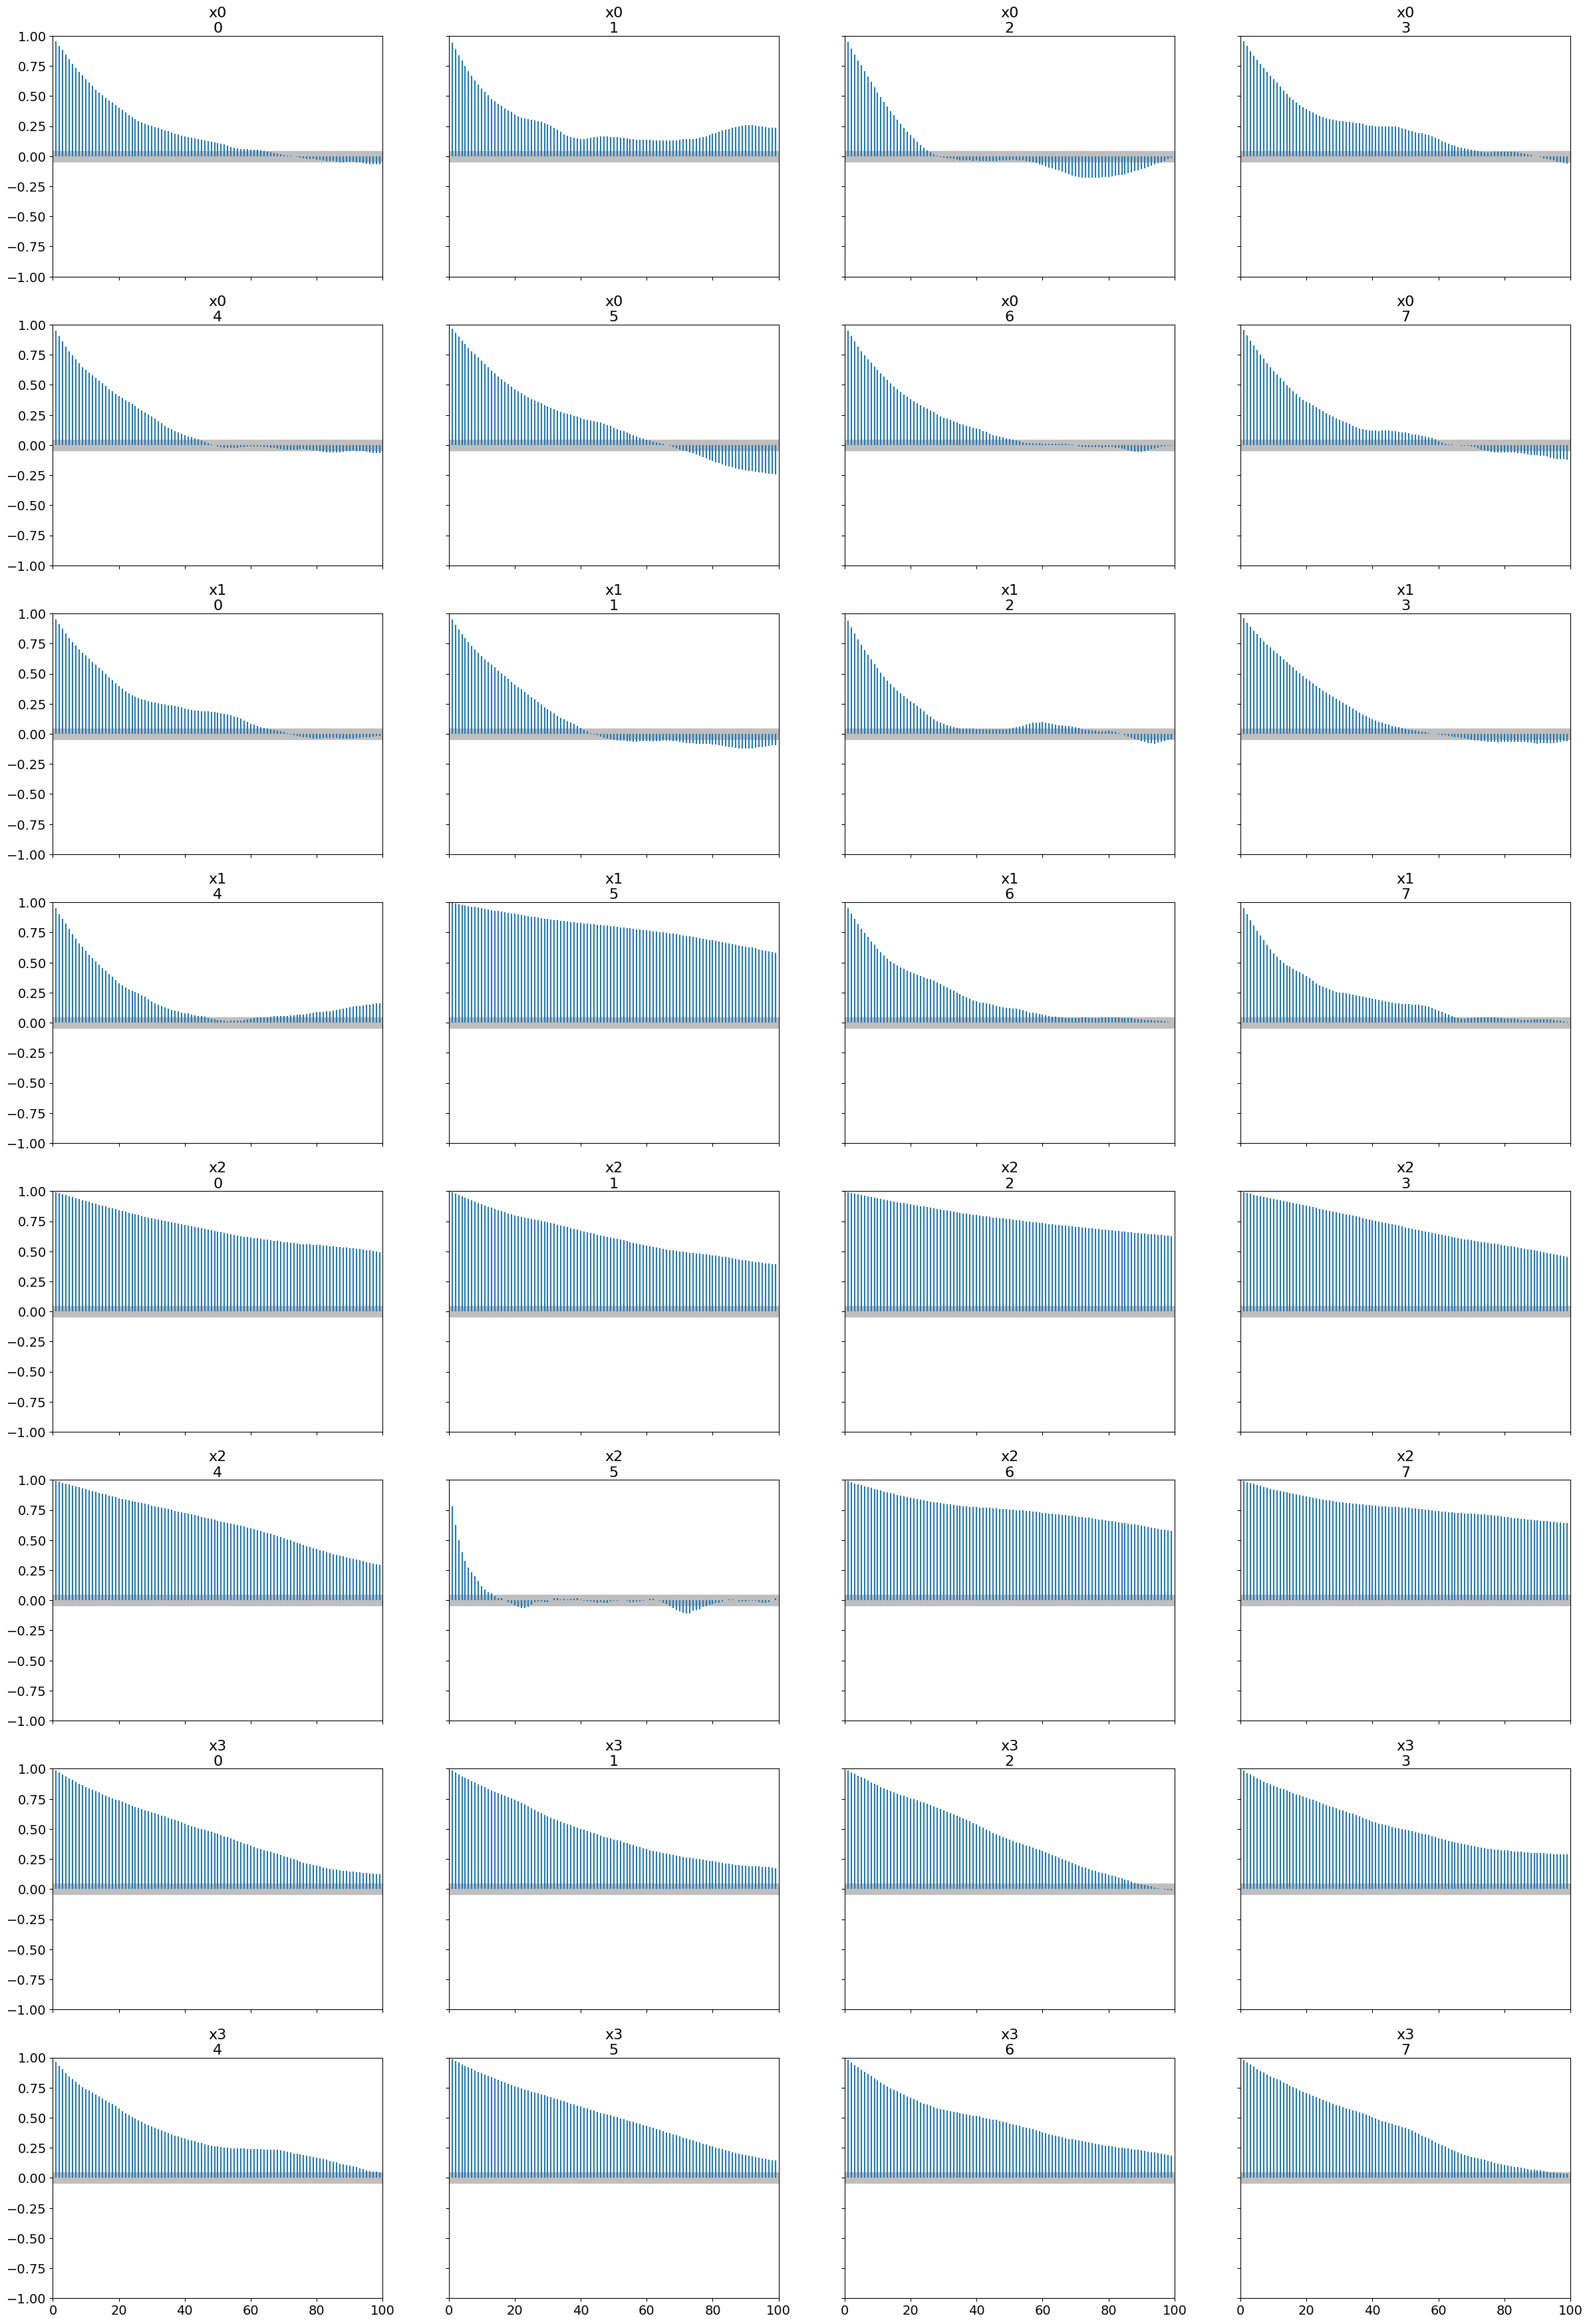

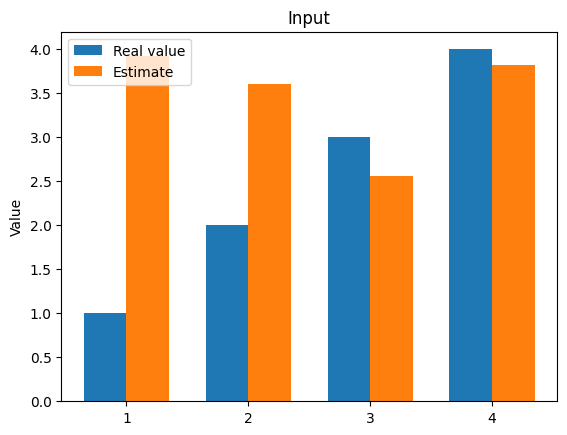

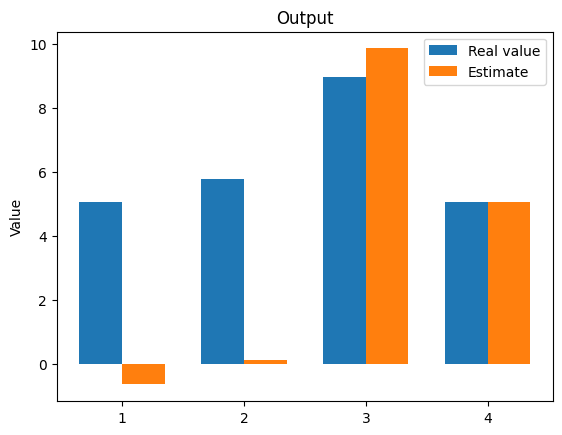

The function inverse took 1374.7530977725983 seconds.


In [ ]:
estimate_MF3=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="DREAMZ")
estimate_LF3=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo ="DREAMZ")
estimate_HF3=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="DREAMZ")

In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.45,0.6])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.2
sigma=0.3
rwmh_cov = np.eye(len(real_x)) *3# !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=2

# Multifidelity

real values are [1.   1.5  2.25 3.  ]
Sampling chain 1/2


Running chain, α = 0.16: 100%|██████████| 2000/2000 [05:08<00:00,  6.49it/s]


Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [05:24<00:00,  6.17it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.5   1.674 1.849 2.997]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.500  0.486   0.617    2.347      0.114    0.082      20.0      58.0   
x1  1.674  0.478   0.681    2.432      0.194    0.144       8.0      11.0   
x2  1.849  0.390   1.270    2.416      0.091    0.065      25.0      19.0   
x3  2.997  0.153   2.553    3.141      0.031    0.022      47.0      35.0   

    r_hat  
x0   1.12  
x1   1.21  
x2   1.05  
x3   1.05  
Autocorrelation...
the difference between estimated values [0.5   0.174 0.401 0.003]
 the difference between outputs of two models are [0.47835082 0.04328346 0.7148205  0.02449036]


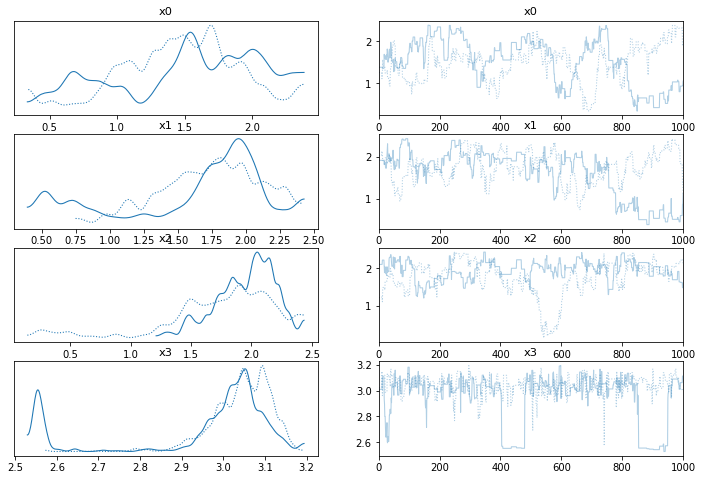

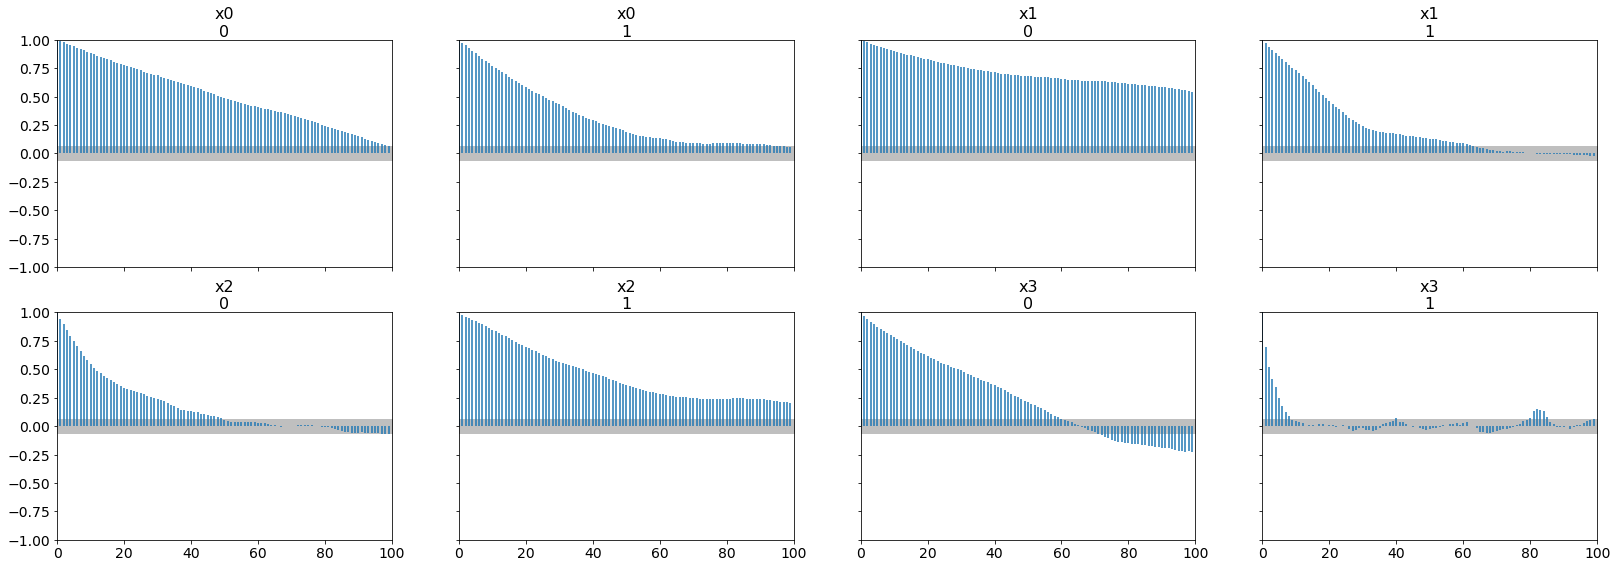

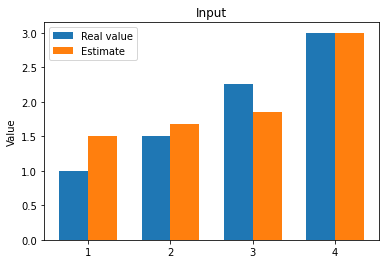

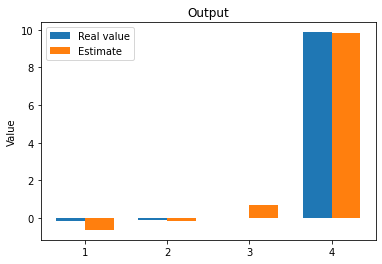

The function inverse took 637.775377035141 seconds.


In [ ]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [1.   1.5  2.25 3.  ]


Exception ignored in: <function UniquePtr.__del__ at 0x000001F12A8E2830>
Traceback (most recent call last):
  File "c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\python\framework\c_api_util.py", line 71, in __del__
    obj = self._obj
AttributeError: 'ScopedTFGraph' object has no attribute '_obj'


Sampling chain 1/2


Running chain, α = 0.29: 100%|██████████| 2000/2000 [05:33<00:00,  6.01it/s]


Sampling chain 2/2


Running chain, α = 0.30: 100%|██████████| 2000/2000 [05:16<00:00,  6.31it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.235 1.331 2.128 2.878]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.235  0.472   0.403    1.944      0.121    0.087      17.0      62.0   
x1  1.331  0.507   0.419    2.086      0.113    0.084      20.0      56.0   
x2  2.128  0.318   1.415    2.439      0.086    0.063      16.0      71.0   
x3  2.878  0.177   2.545    3.060      0.025    0.018      67.0     105.0   

    r_hat  
x0   1.16  
x1   1.07  
x2   1.10  
x3   1.03  
Autocorrelation...
the difference between estimated values [0.235 0.169 0.122 0.122]
 the difference between outputs of two models are [0.29841137 0.1036917  0.29651862 0.79768944]


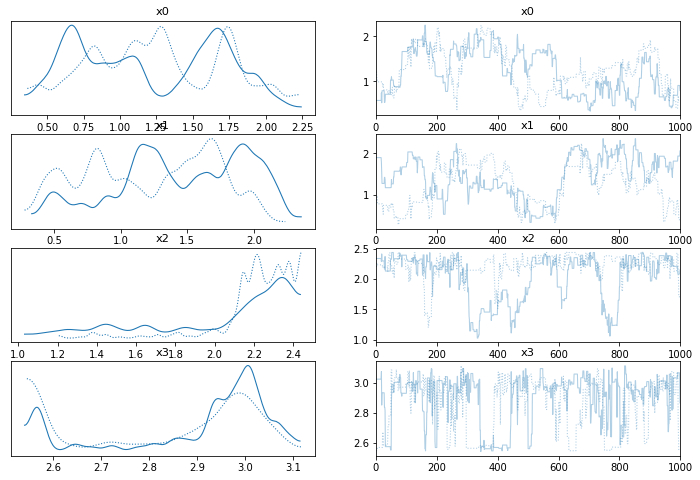

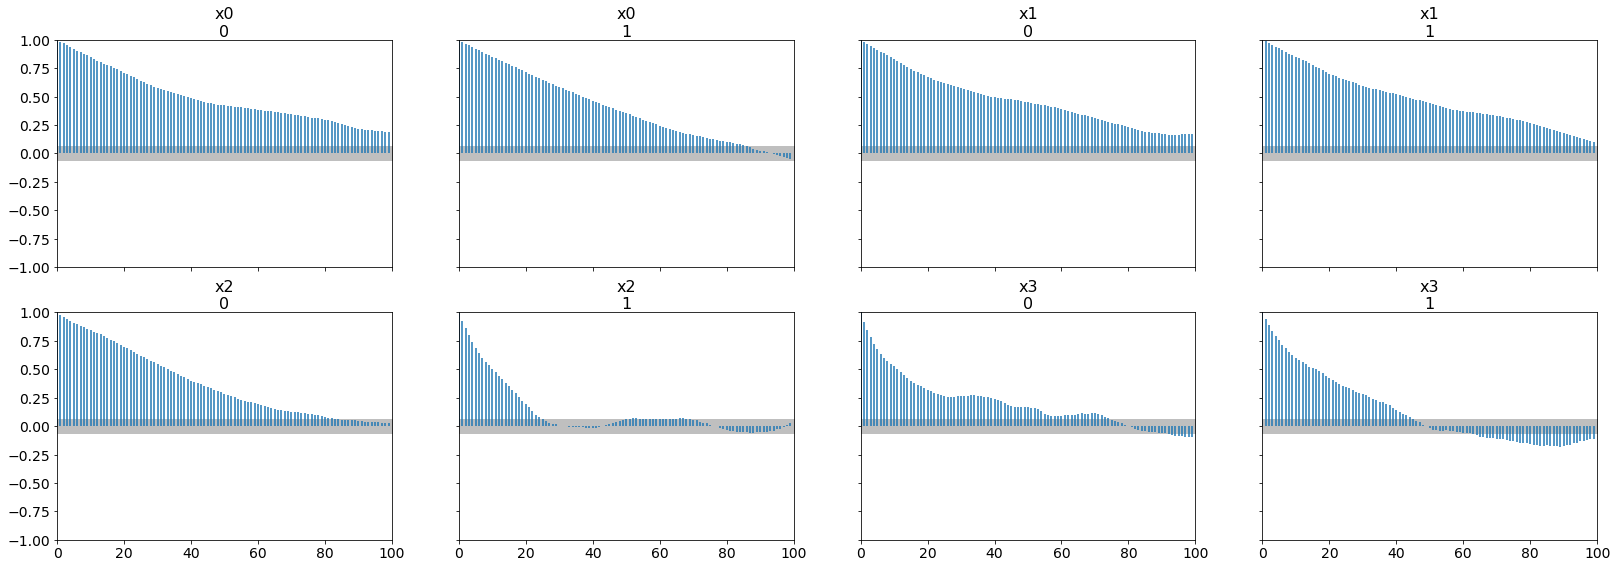

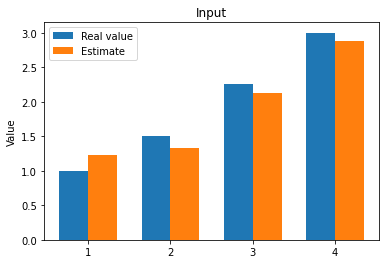

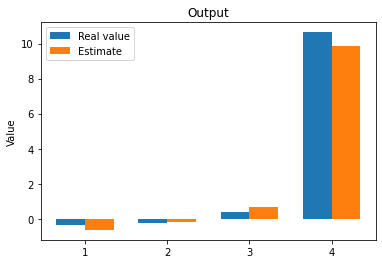

The function inverse took 754.988499879837 seconds.


In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.45,0.6])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.5
sigma=0.5
rwmh_cov = np.eye(len(real_x)) *3# !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=2
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Low Fidelity

real values are [1.   1.5  2.25 3.  ]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 2000/2000 [03:08<00:00, 10.59it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 2000/2000 [04:28<00:00,  7.45it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [3.526 3.449 2.877 2.857]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.526  0.659   2.652    4.306      0.457    0.386       3.0      63.0   
x1  3.449  0.626   2.641    4.246      0.413    0.342       3.0      88.0   
x2  2.877  0.147   2.598    3.092      0.018    0.013      69.0      77.0   
x3  2.857  0.076   2.711    2.993      0.006    0.005     138.0     156.0   

    r_hat  
x0   1.87  
x1   1.68  
x2   1.05  
x3   1.02  
Autocorrelation...
the difference between estimated values [2.526 1.949 0.627 0.143]
 the difference between outputs of two models are [5.9638467  4.8423195  4.256404   0.06907105]


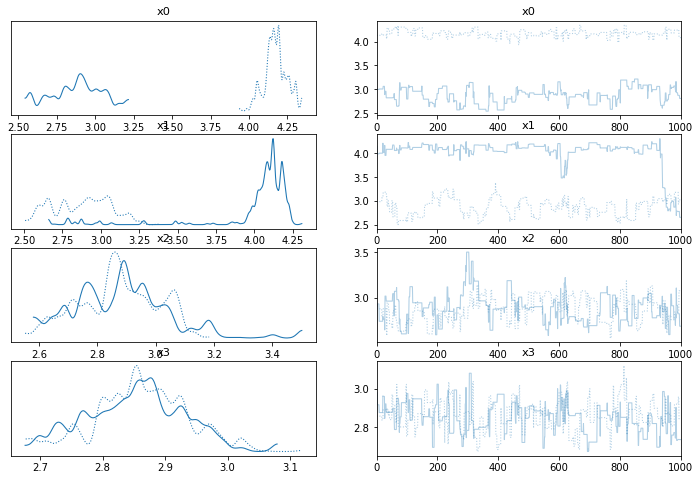

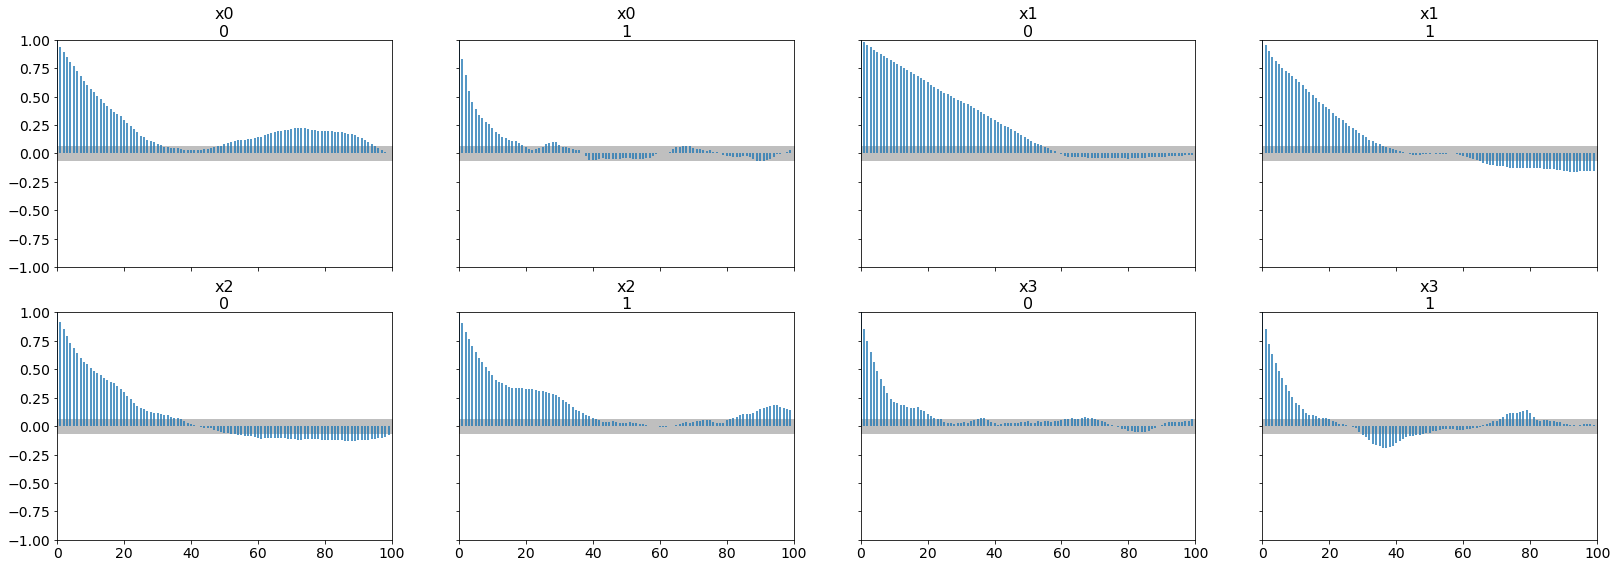

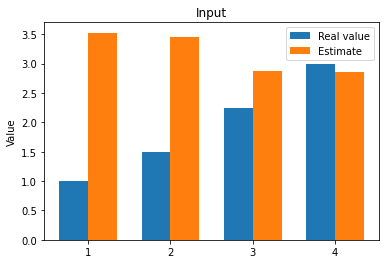

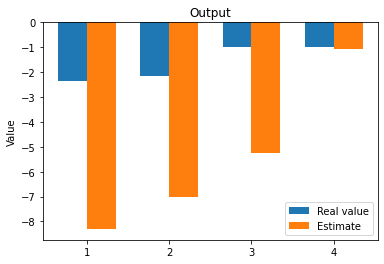

The function inverse took 474.98948073387146 seconds.


In [ ]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


In [ ]:
## High Fidelity

In [ ]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


real values are [1.   1.5  2.25 3.  ]
